In [12]:
!pip install -q ultralytics

import os
import yaml
import shutil
from pathlib import Path
from ultralytics import YOLO
import ultralytics

ultralytics.checks()

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6841.9/8062.4 GB disk)


In [13]:
# === UPDATE THESE PATHS IF YOUR NEW DATASET LOCATION IS DIFFERENT ===
TRAIN_IMAGES = "/kaggle/input/datasets/paras2829/yolo-major/merged_yolo/train/images"
VAL_IMAGES   = "/kaggle/input/datasets/paras2829/yolo-major/merged_yolo/val/images"

print("Train exists:", os.path.exists(TRAIN_IMAGES))
print("Val exists:", os.path.exists(VAL_IMAGES))
print("Train count:", len(os.listdir(TRAIN_IMAGES)) if os.path.exists(TRAIN_IMAGES) else 0)
print("Val count:", len(os.listdir(VAL_IMAGES)) if os.path.exists(VAL_IMAGES) else 0)

Train exists: True
Val exists: True
Train count: 33034
Val count: 5879


In [14]:
class_names = [
    "give_way", "no_entry", "one_way_traffic", "no_overtaking",
    "no_left_turn", "no_right_turn", "no_parking", "no_stopping",
    "horn_prohibited", "speed_limit_20", "speed_limit_30", "speed_limit_50",
    "speed_limit_60", "speed_limit_70", "speed_limit_80", "speed_limit_90",
    "speed_limit_100", "speed_limit_110", "speed_limit_120", "stop",
    "turn_left_ahead", "turn_right_ahead", "straight_ahead", "keep_right",
    "keep_left", "roundabout", "pedestrian_crossing", "school_zone",
    "traffic_signal", "bumpy_road", "narrow_road", "road_works",
    "slippery_road", "steep_descent", "steep_ascent", "cattle_crossing",
    "level_crossing_guarded", "level_crossing_unguarded",
    "level_crossing_countdown", "parking", "general_caution",
    "crossroads", "t_junction"
]

data_config = {
    "train": TRAIN_IMAGES,
    "val": VAL_IMAGES,
    "nc": len(class_names),
    "names": class_names
}

with open("/kaggle/working/data.yaml", "w") as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("data.yaml created successfully\n")
print(open("/kaggle/working/data.yaml").read())

data.yaml created successfully

names:
- give_way
- no_entry
- one_way_traffic
- no_overtaking
- no_left_turn
- no_right_turn
- no_parking
- no_stopping
- horn_prohibited
- speed_limit_20
- speed_limit_30
- speed_limit_50
- speed_limit_60
- speed_limit_70
- speed_limit_80
- speed_limit_90
- speed_limit_100
- speed_limit_110
- speed_limit_120
- stop
- turn_left_ahead
- turn_right_ahead
- straight_ahead
- keep_right
- keep_left
- roundabout
- pedestrian_crossing
- school_zone
- traffic_signal
- bumpy_road
- narrow_road
- road_works
- slippery_road
- steep_descent
- steep_ascent
- cattle_crossing
- level_crossing_guarded
- level_crossing_unguarded
- level_crossing_countdown
- parking
- general_caution
- crossroads
- t_junction
nc: 43
train: /kaggle/input/datasets/paras2829/yolo-major/merged_yolo/train/images
val: /kaggle/input/datasets/paras2829/yolo-major/merged_yolo/val/images



In [18]:
best_model = YOLO("/kaggle/input/models/paras2829/yolo-best/pytorch/default/1/best.pt")

metrics = best_model.val(data="/kaggle/working/data.yaml")

print(f"mAP50      : {metrics.box.map50:.4f}")
print(f"mAP50-95   : {metrics.box.map:.4f}")
print(f"Precision  : {metrics.box.mp:.4f}")
print(f"Recall     : {metrics.box.mr:.4f}")

Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,014,033 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.4 ms, read: 9.5±1.4 MB/s, size: 49.5 KB)
val: Scanning /kaggle/input/datasets/paras2829/yolo-major/merged_yolo/val/labels... 5879 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5879/5879 232.7it/s 25.3s<0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/paras2829/yolo-major/merged_yolo/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 368/368 7.8it/s 47.4s<0.1s
                   all       5879       5879      0.985      0.979      0.989      0.973
              give_way        355        355      0.998          1      0.995      0.973
              no_entry        493        493      0.991      0.974      0.994      0.981
       one_way_traffic         62         62      0.995   

In [24]:
from ultralytics import YOLO

model = YOLO("/kaggle/input/models/paras2829/yolo-best/pytorch/default/1/best.pt")
print("Model loaded successfully")

Model loaded successfully


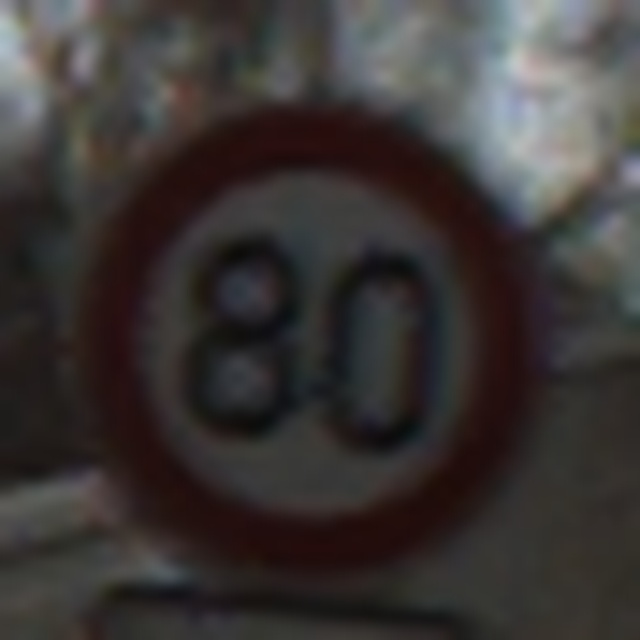

Prediction: speed_limit_80 (0.89)
Correct: True
------------------------------------------------------------


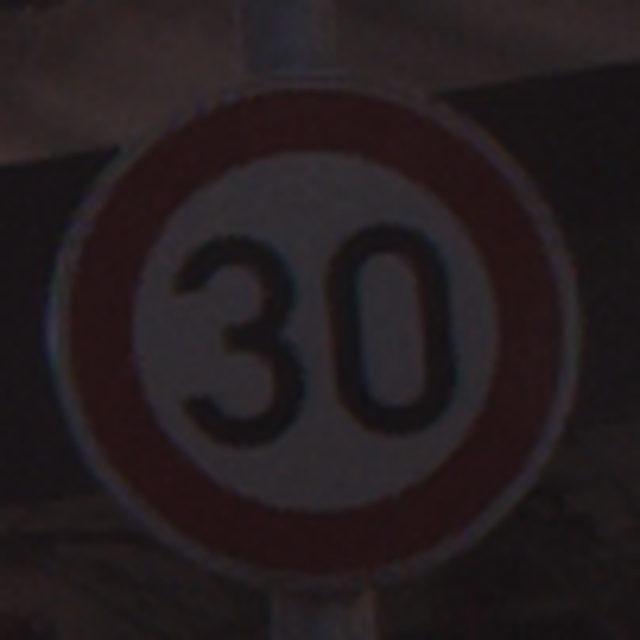

Prediction: speed_limit_30 (0.90)
Correct: True
------------------------------------------------------------


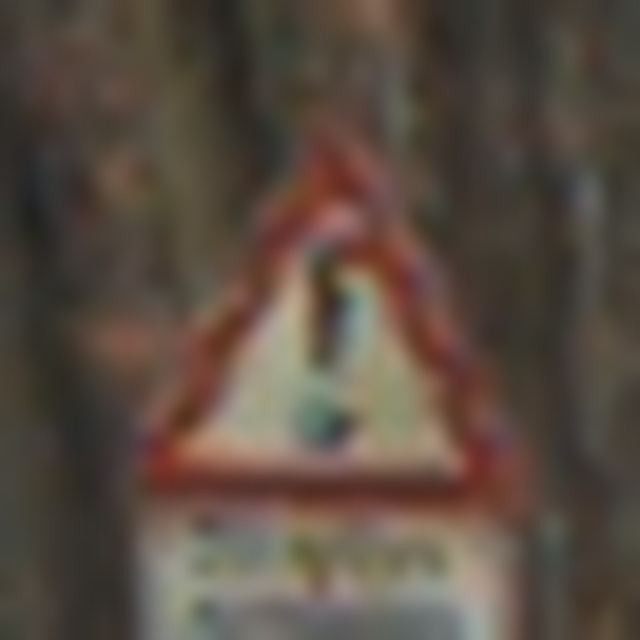

Prediction: general_caution (0.83)
Correct: True
------------------------------------------------------------


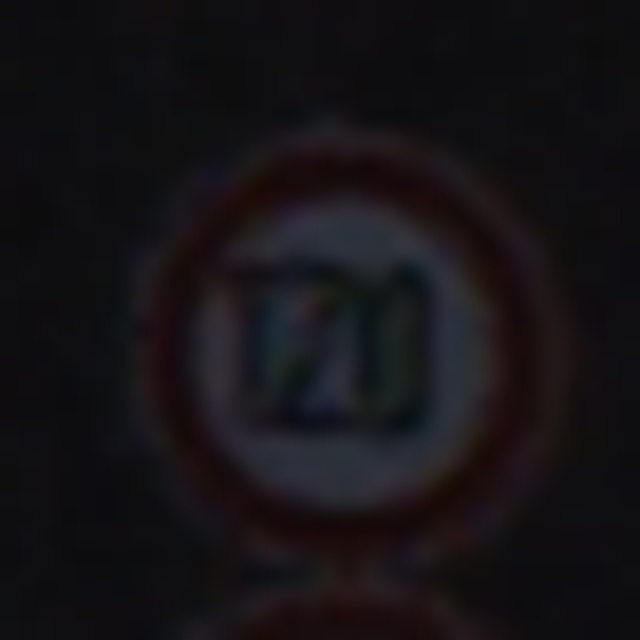

Prediction: speed_limit_120 (0.78)
Correct: True
------------------------------------------------------------


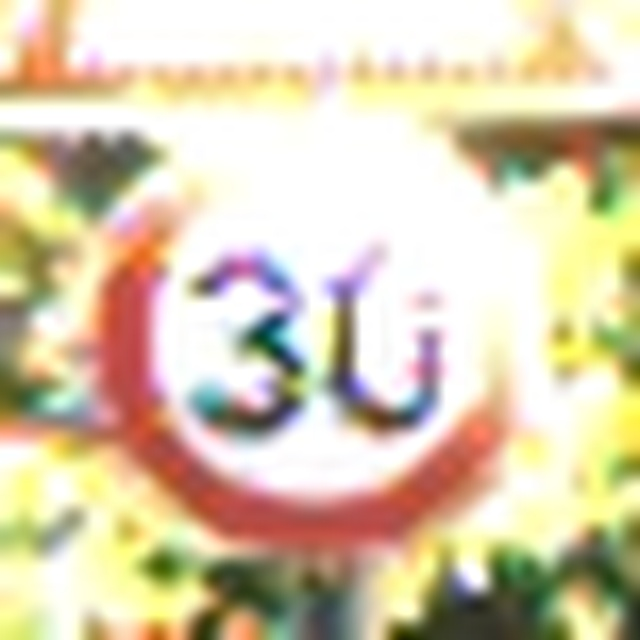

Prediction: speed_limit_30 (0.85)
Correct: True
------------------------------------------------------------


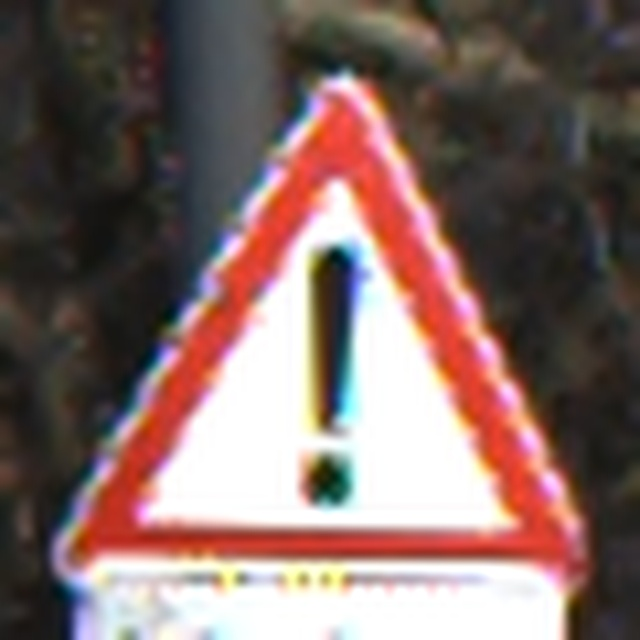

Prediction: general_caution (0.86)
Correct: True
------------------------------------------------------------


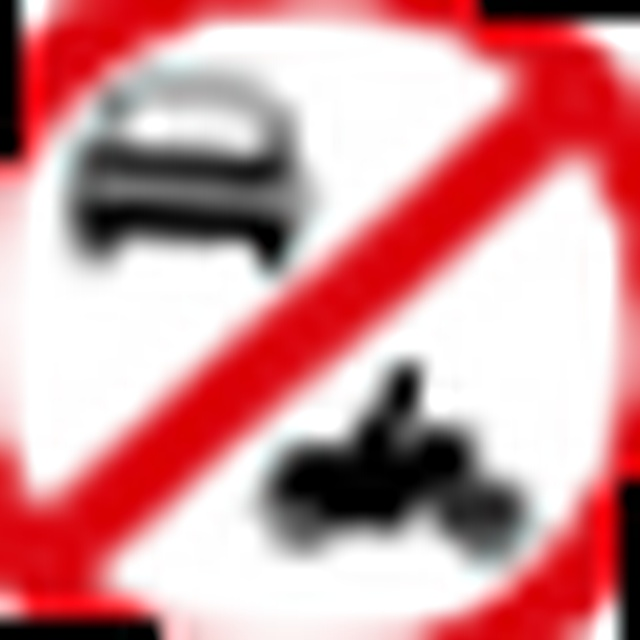

Prediction: no_entry (0.95)
Correct: True
------------------------------------------------------------


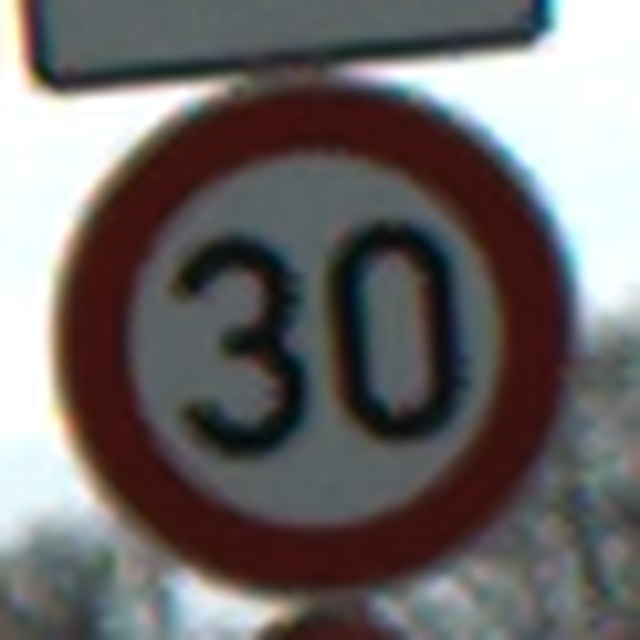

Prediction: speed_limit_30 (0.91)
Correct: True
------------------------------------------------------------


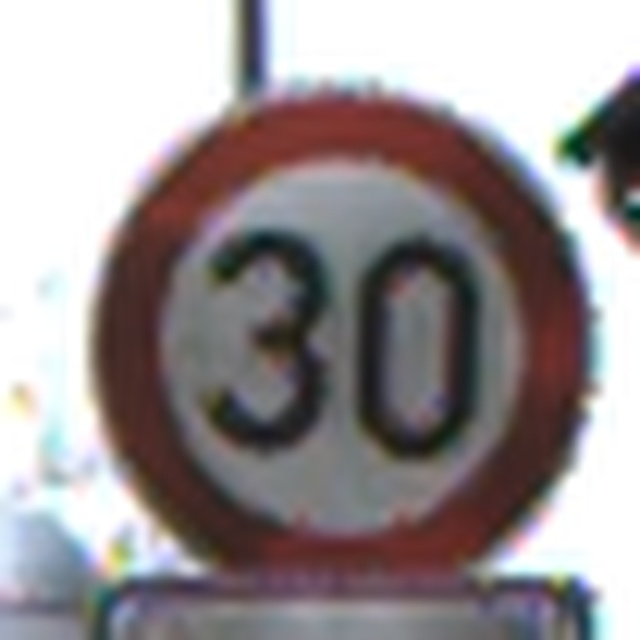

Prediction: speed_limit_30 (0.89)
Correct: True
------------------------------------------------------------


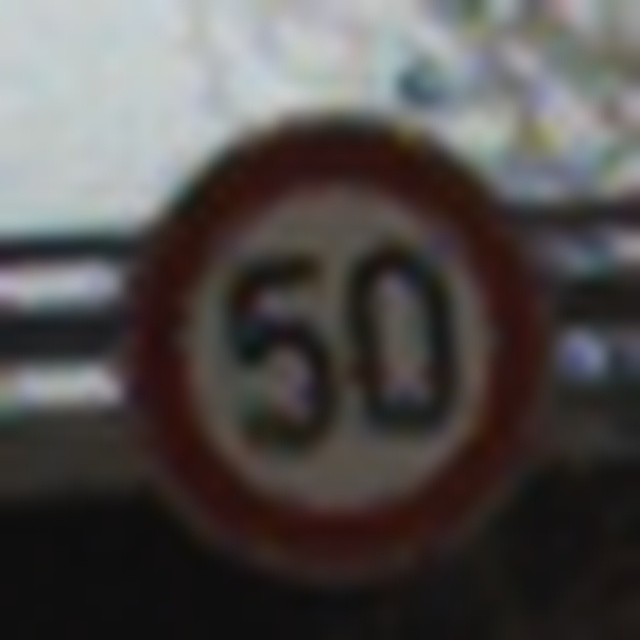

Prediction: speed_limit_50 (0.86)
Correct: True
------------------------------------------------------------


,prediction,correct
0,speed_limit_80 (0.89),True
1,speed_limit_30 (0.90),True
2,general_caution (0.83),True
3,speed_limit_120 (0.78),True
4,speed_limit_30 (0.85),True
5,general_caution (0.86),True
6,no_entry (0.95),True
7,speed_limit_30 (0.91),True
8,speed_limit_30 (0.89),True
9,speed_limit_50 (0.86),True


Saved CSV: /kaggle/working/random_val_10_predictions.csv


In [40]:
from ultralytics import YOLO
from pathlib import Path
import random
import pandas as pd
from IPython.display import Image, display

VAL_IMAGES = Path("/kaggle/input/datasets/paras2829/yolo-major/merged_yolo/val/images")
VAL_LABELS = Path("/kaggle/input/datasets/paras2829/yolo-major/merged_yolo/val/labels")


# pick any random 10 validation images
all_val_images = [p for p in VAL_IMAGES.iterdir() if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".JPG"]]
sample_images = random.sample(all_val_images, min(10, len(all_val_images)))

rows = []

for img_path in sample_images:
    label_path = VAL_LABELS / f"{img_path.stem}.txt"

    gt_cls = None
    if label_path.exists():
        with open(label_path, "r") as f:
            line = f.readline().strip()
            if line:
                gt_cls = int(float(line.split()[0]))

    result = model.predict(source=str(img_path), conf=0.10, verbose=False)[0]

    if result.boxes is None or len(result.boxes) == 0:
        pred_text = "No detection"
        correct = False
    else:
        best_idx = int(result.boxes.conf.argmax().item())
        pred_cls = int(result.boxes.cls[best_idx].item())
        pred_conf = float(result.boxes.conf[best_idx].item())
        pred_text = f"{model.names[pred_cls]} ({pred_conf:.2f})"
        correct = (gt_cls is not None and pred_cls == gt_cls)

    rows.append({

        "prediction": pred_text,
        "correct": correct
    })

    display(Image(filename=str(img_path), width=300))

    print("Prediction:", pred_text)
    print("Correct:", correct)
    print("-" * 60)

df = pd.DataFrame(rows)
display(df)
df.to_csv("/kaggle/working/random_val_10_predictions.csv", index=False)
print("Saved CSV: /kaggle/working/random_val_10_predictions.csv")


  Box F1 Curve


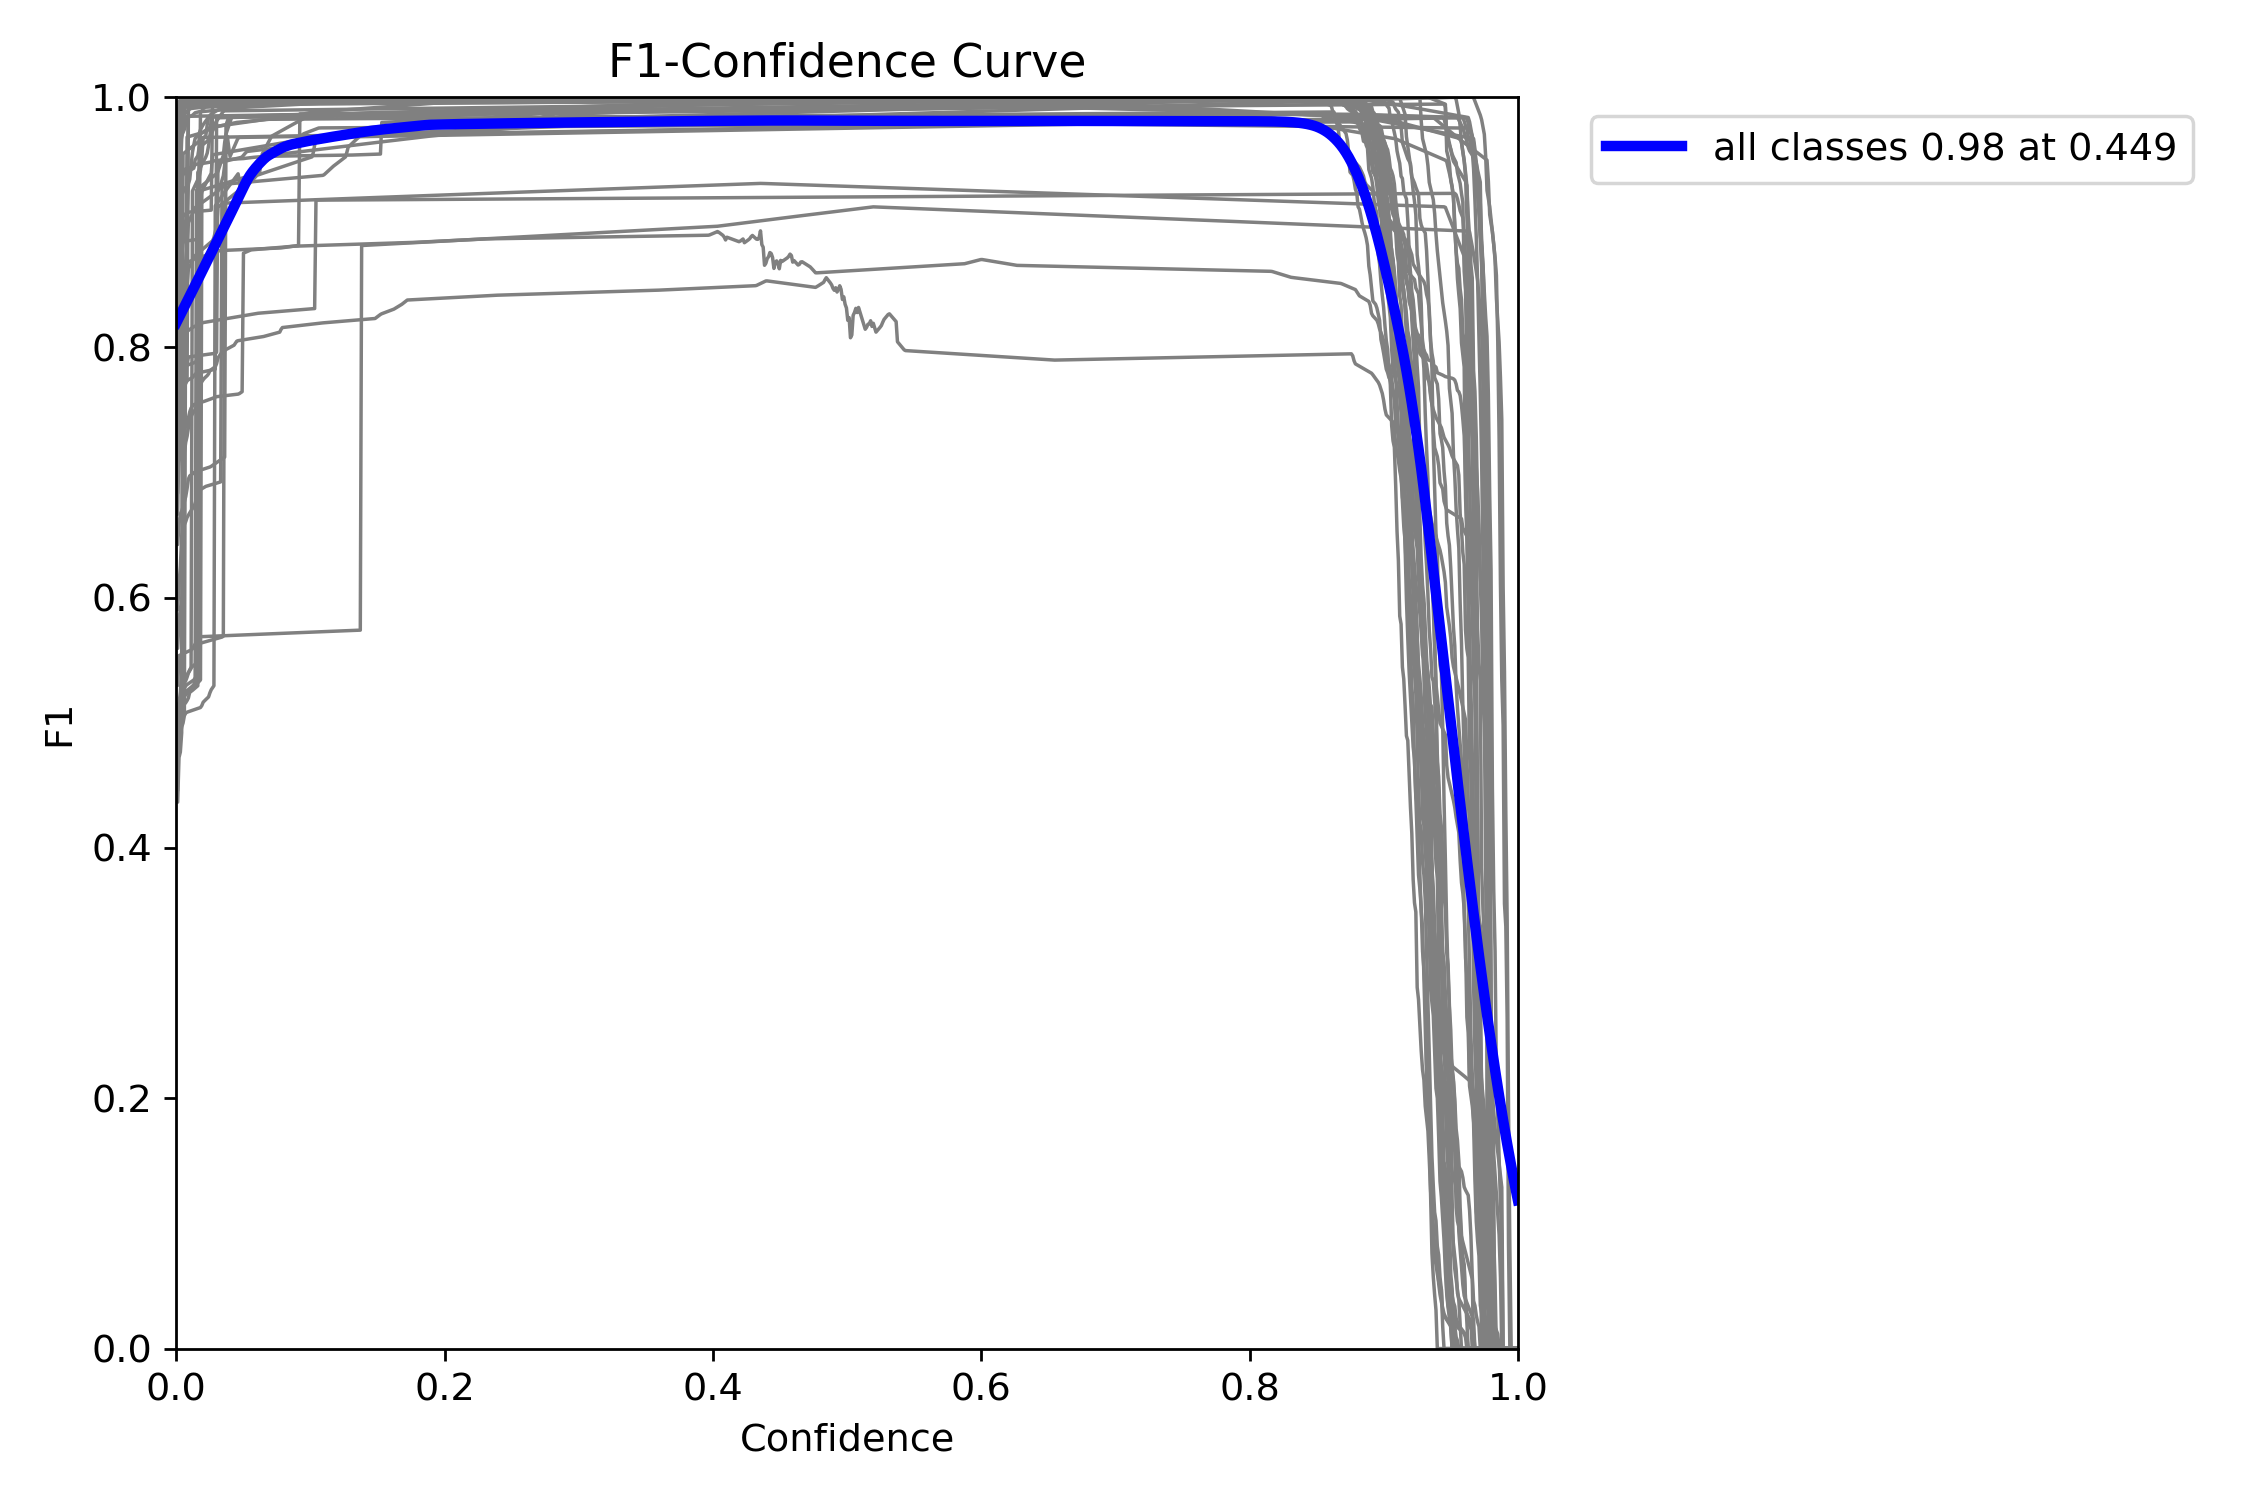


  Box PR Curve


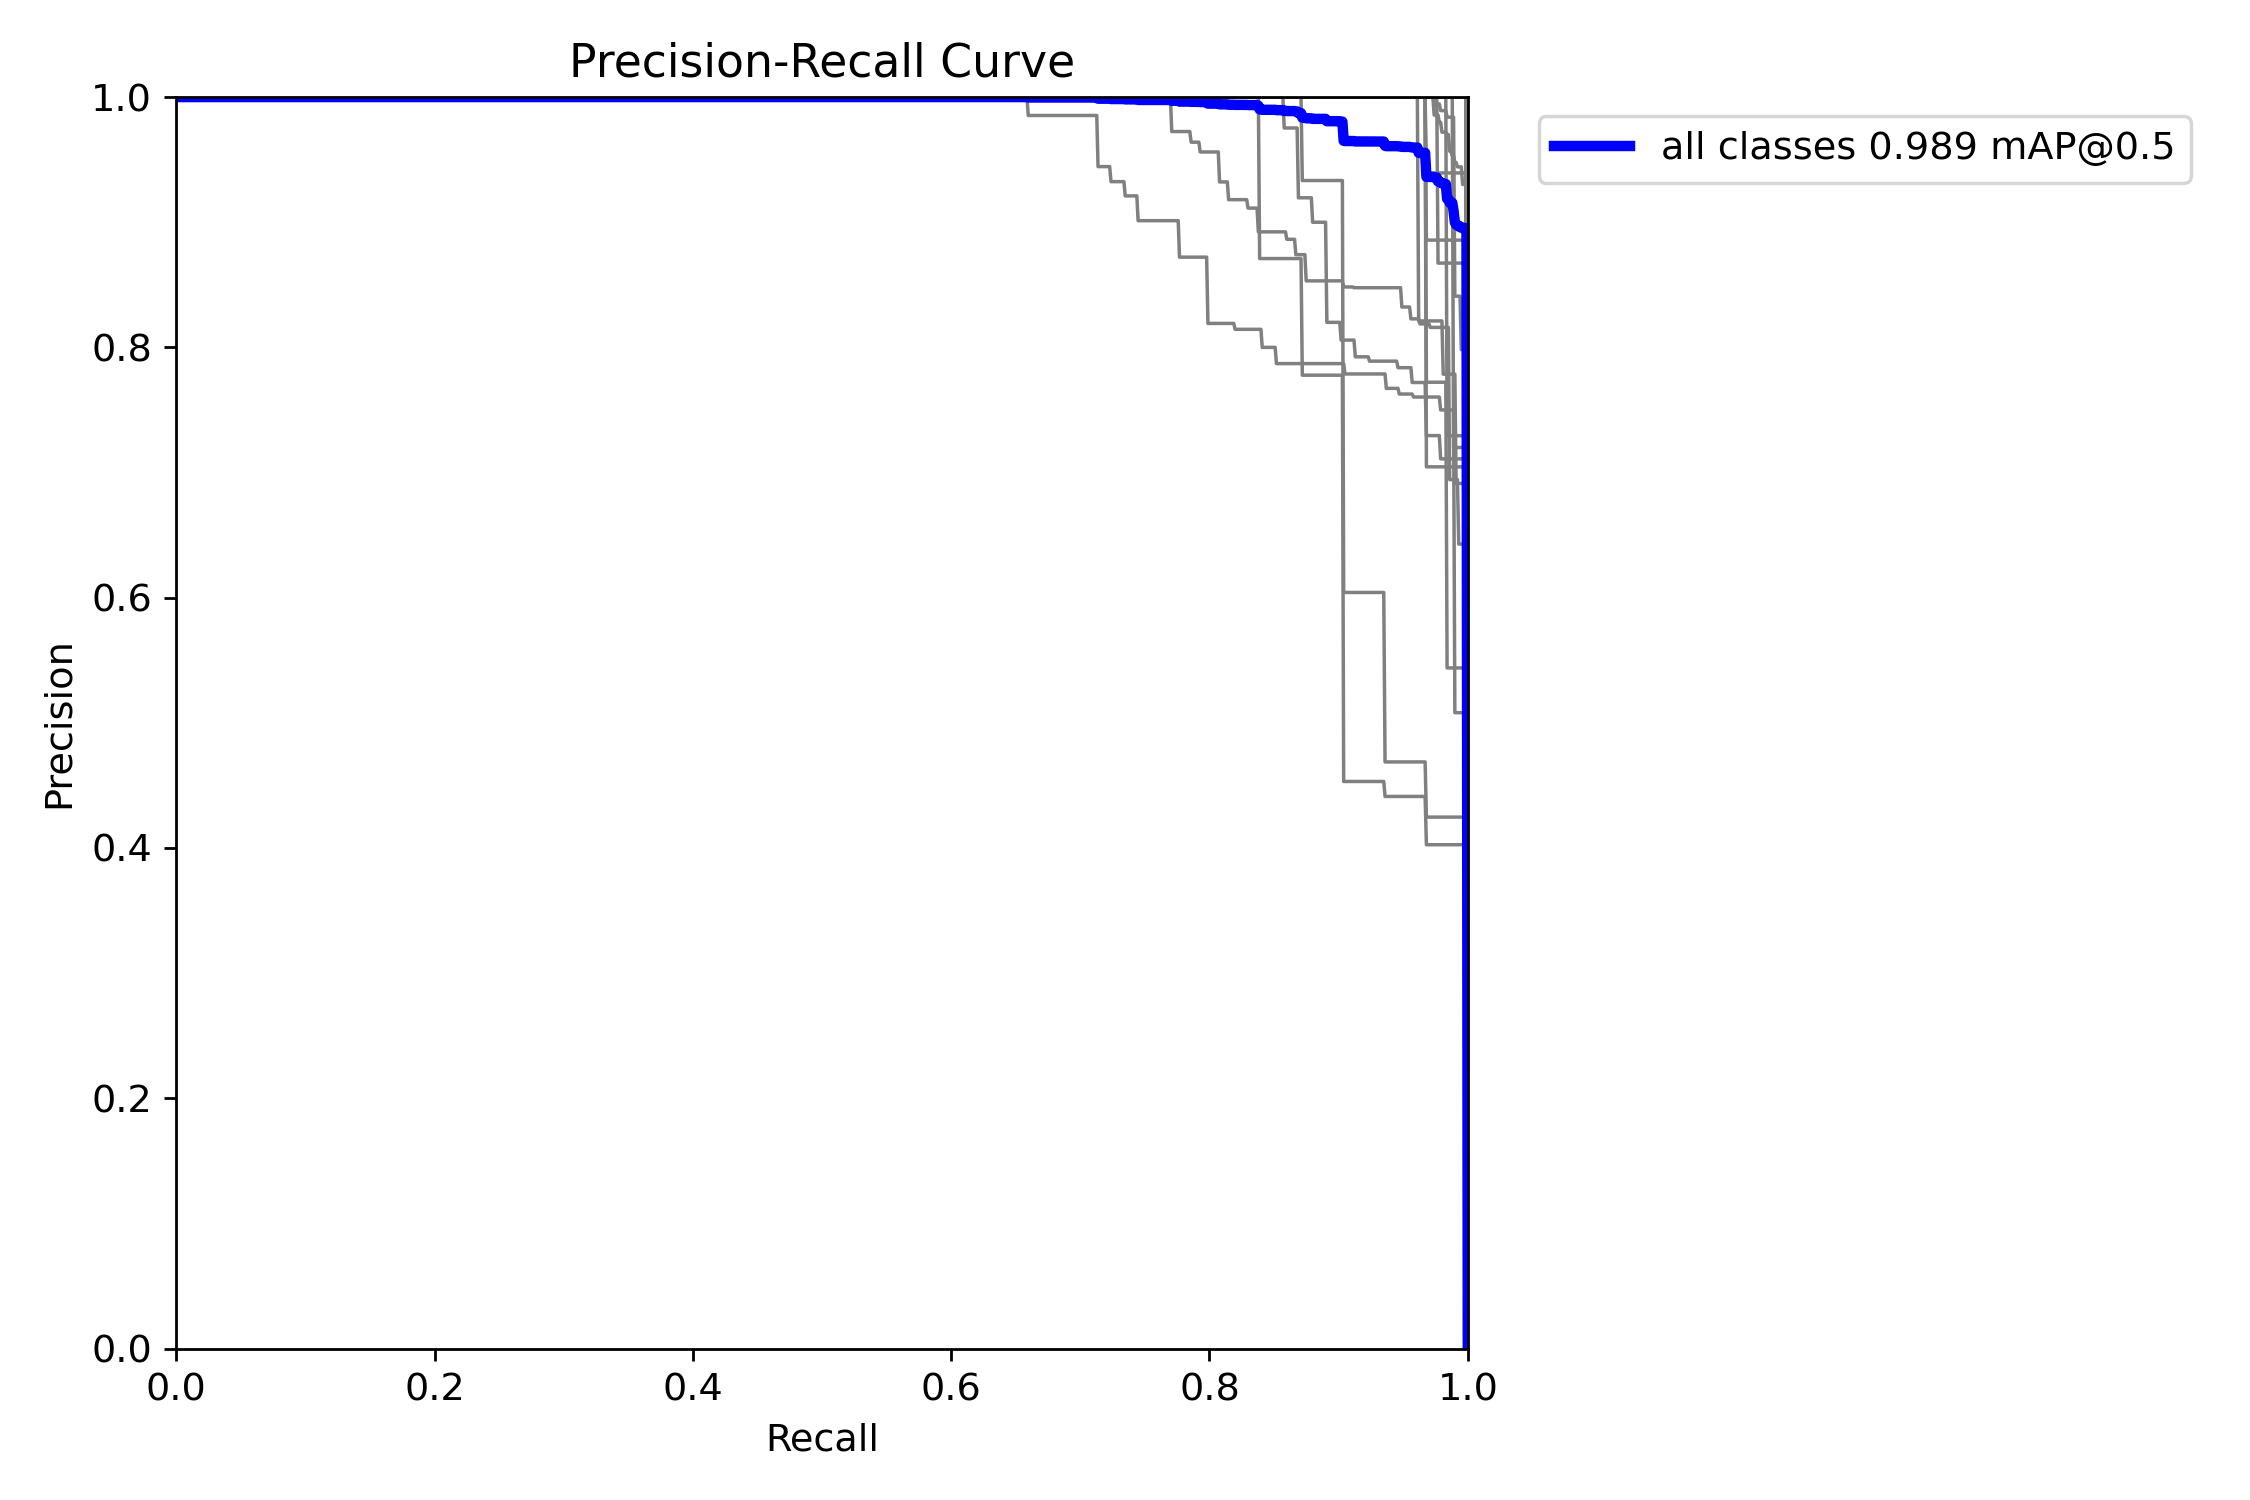


  Box Precision Curve


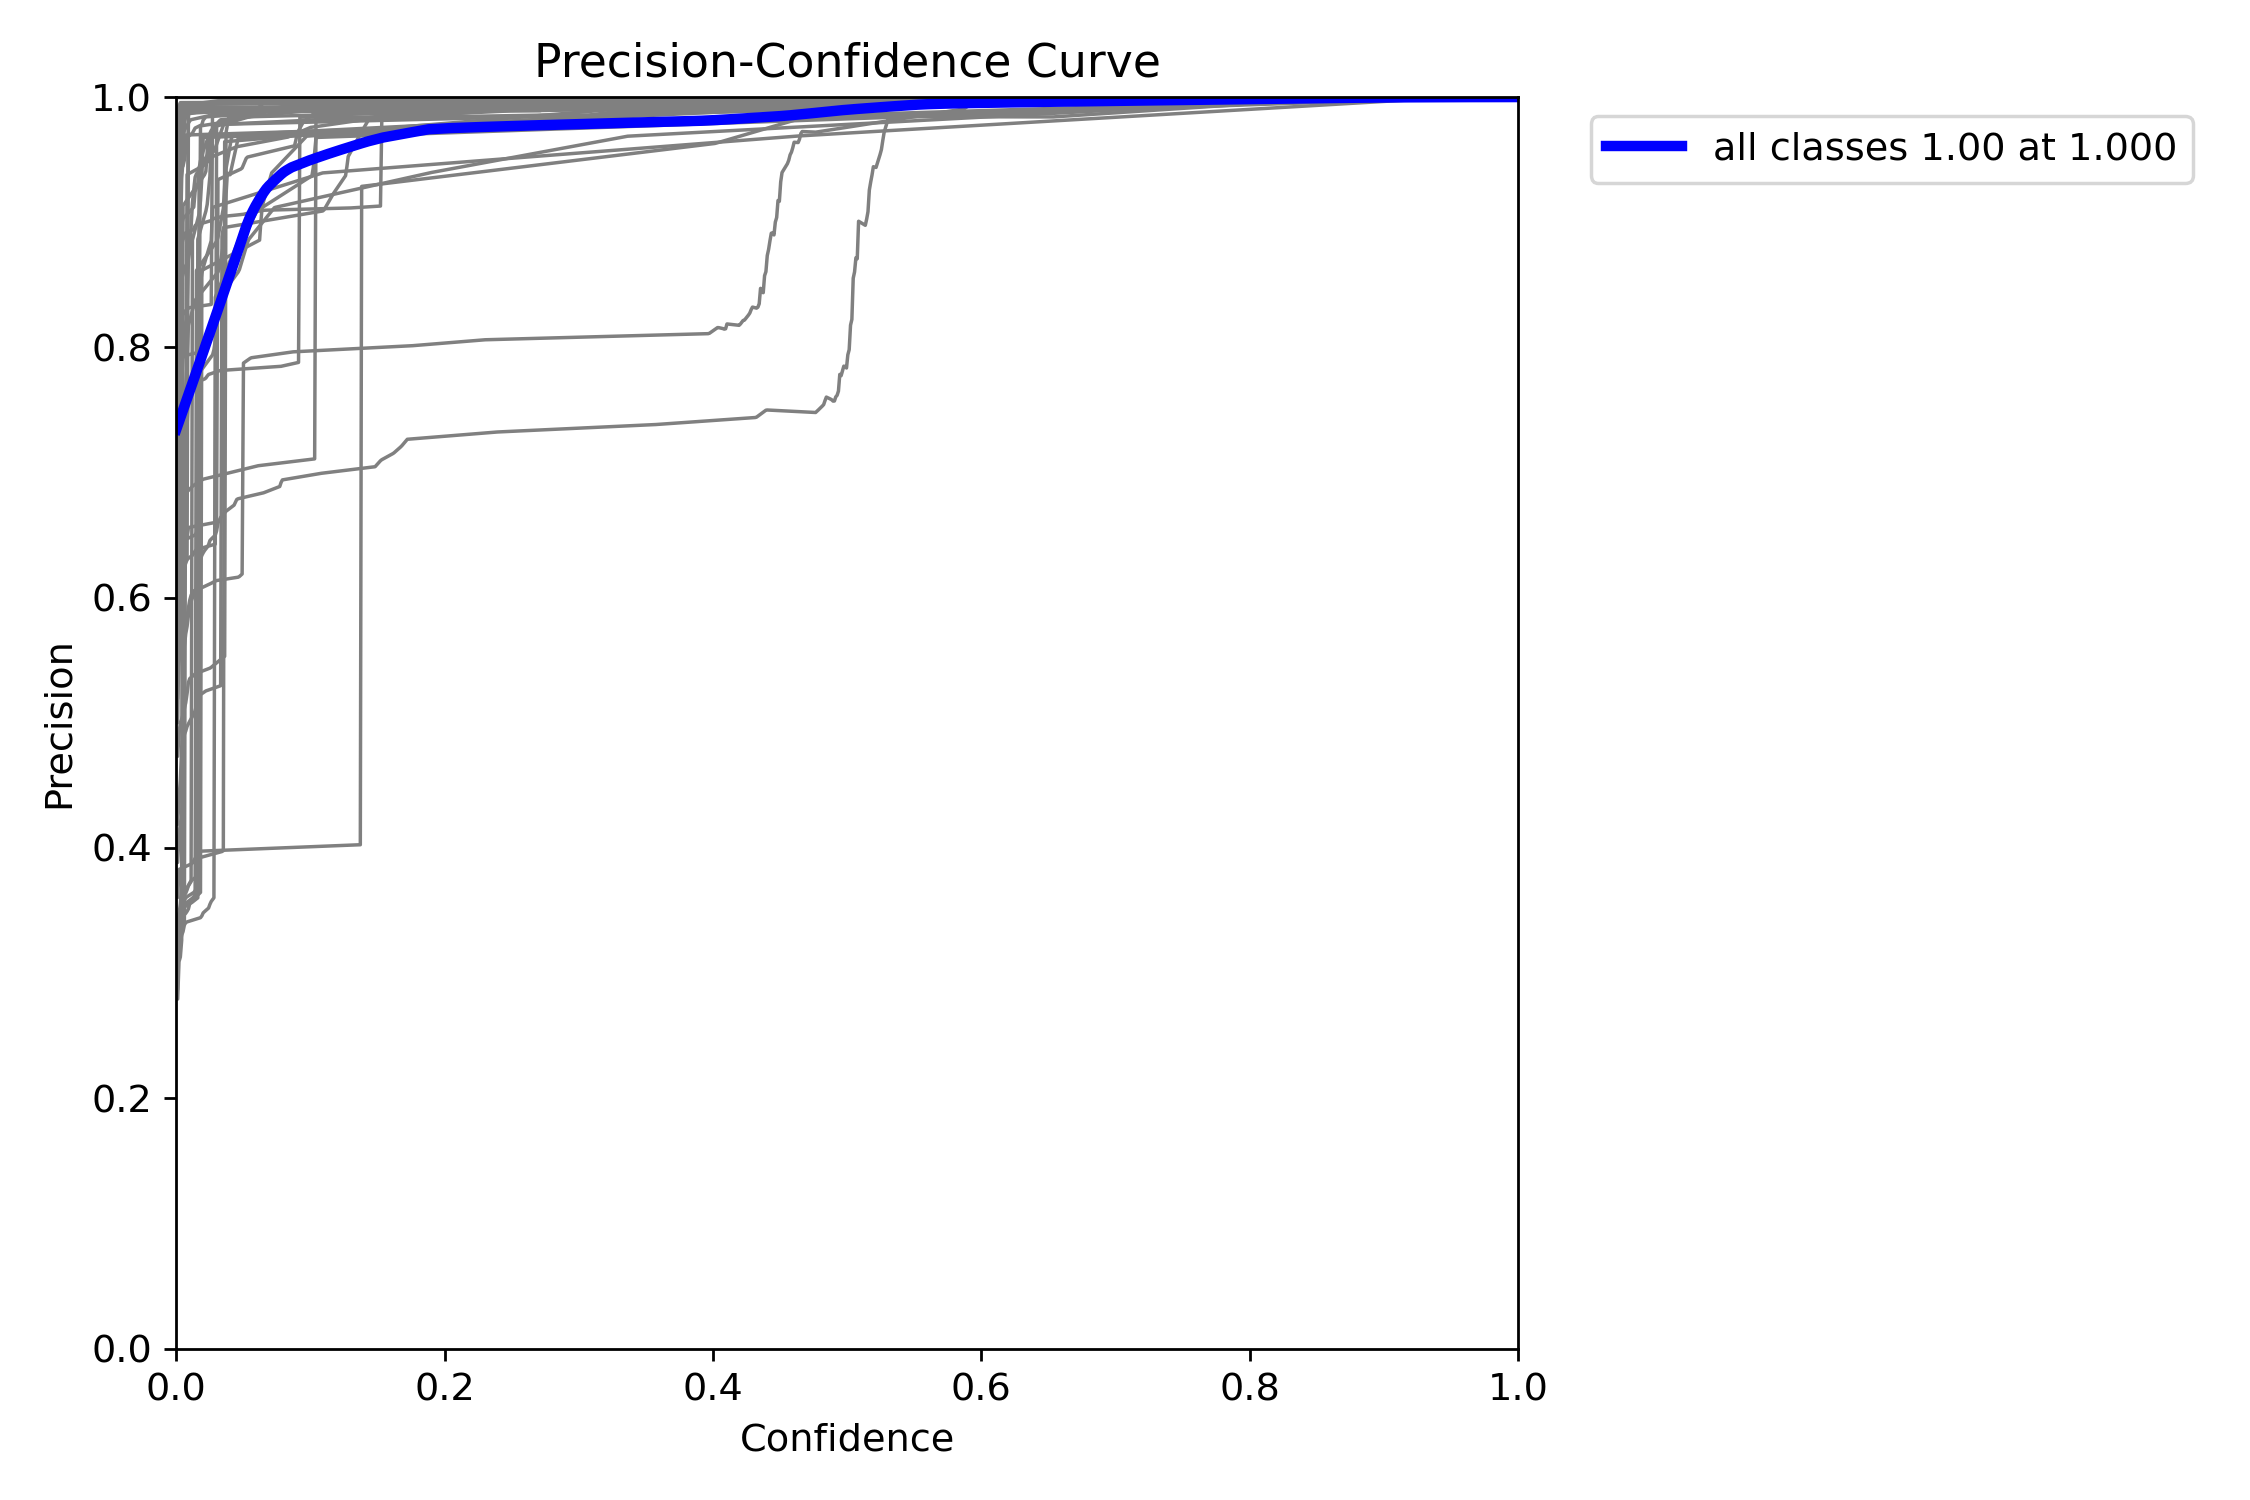


  Box Recall Curve


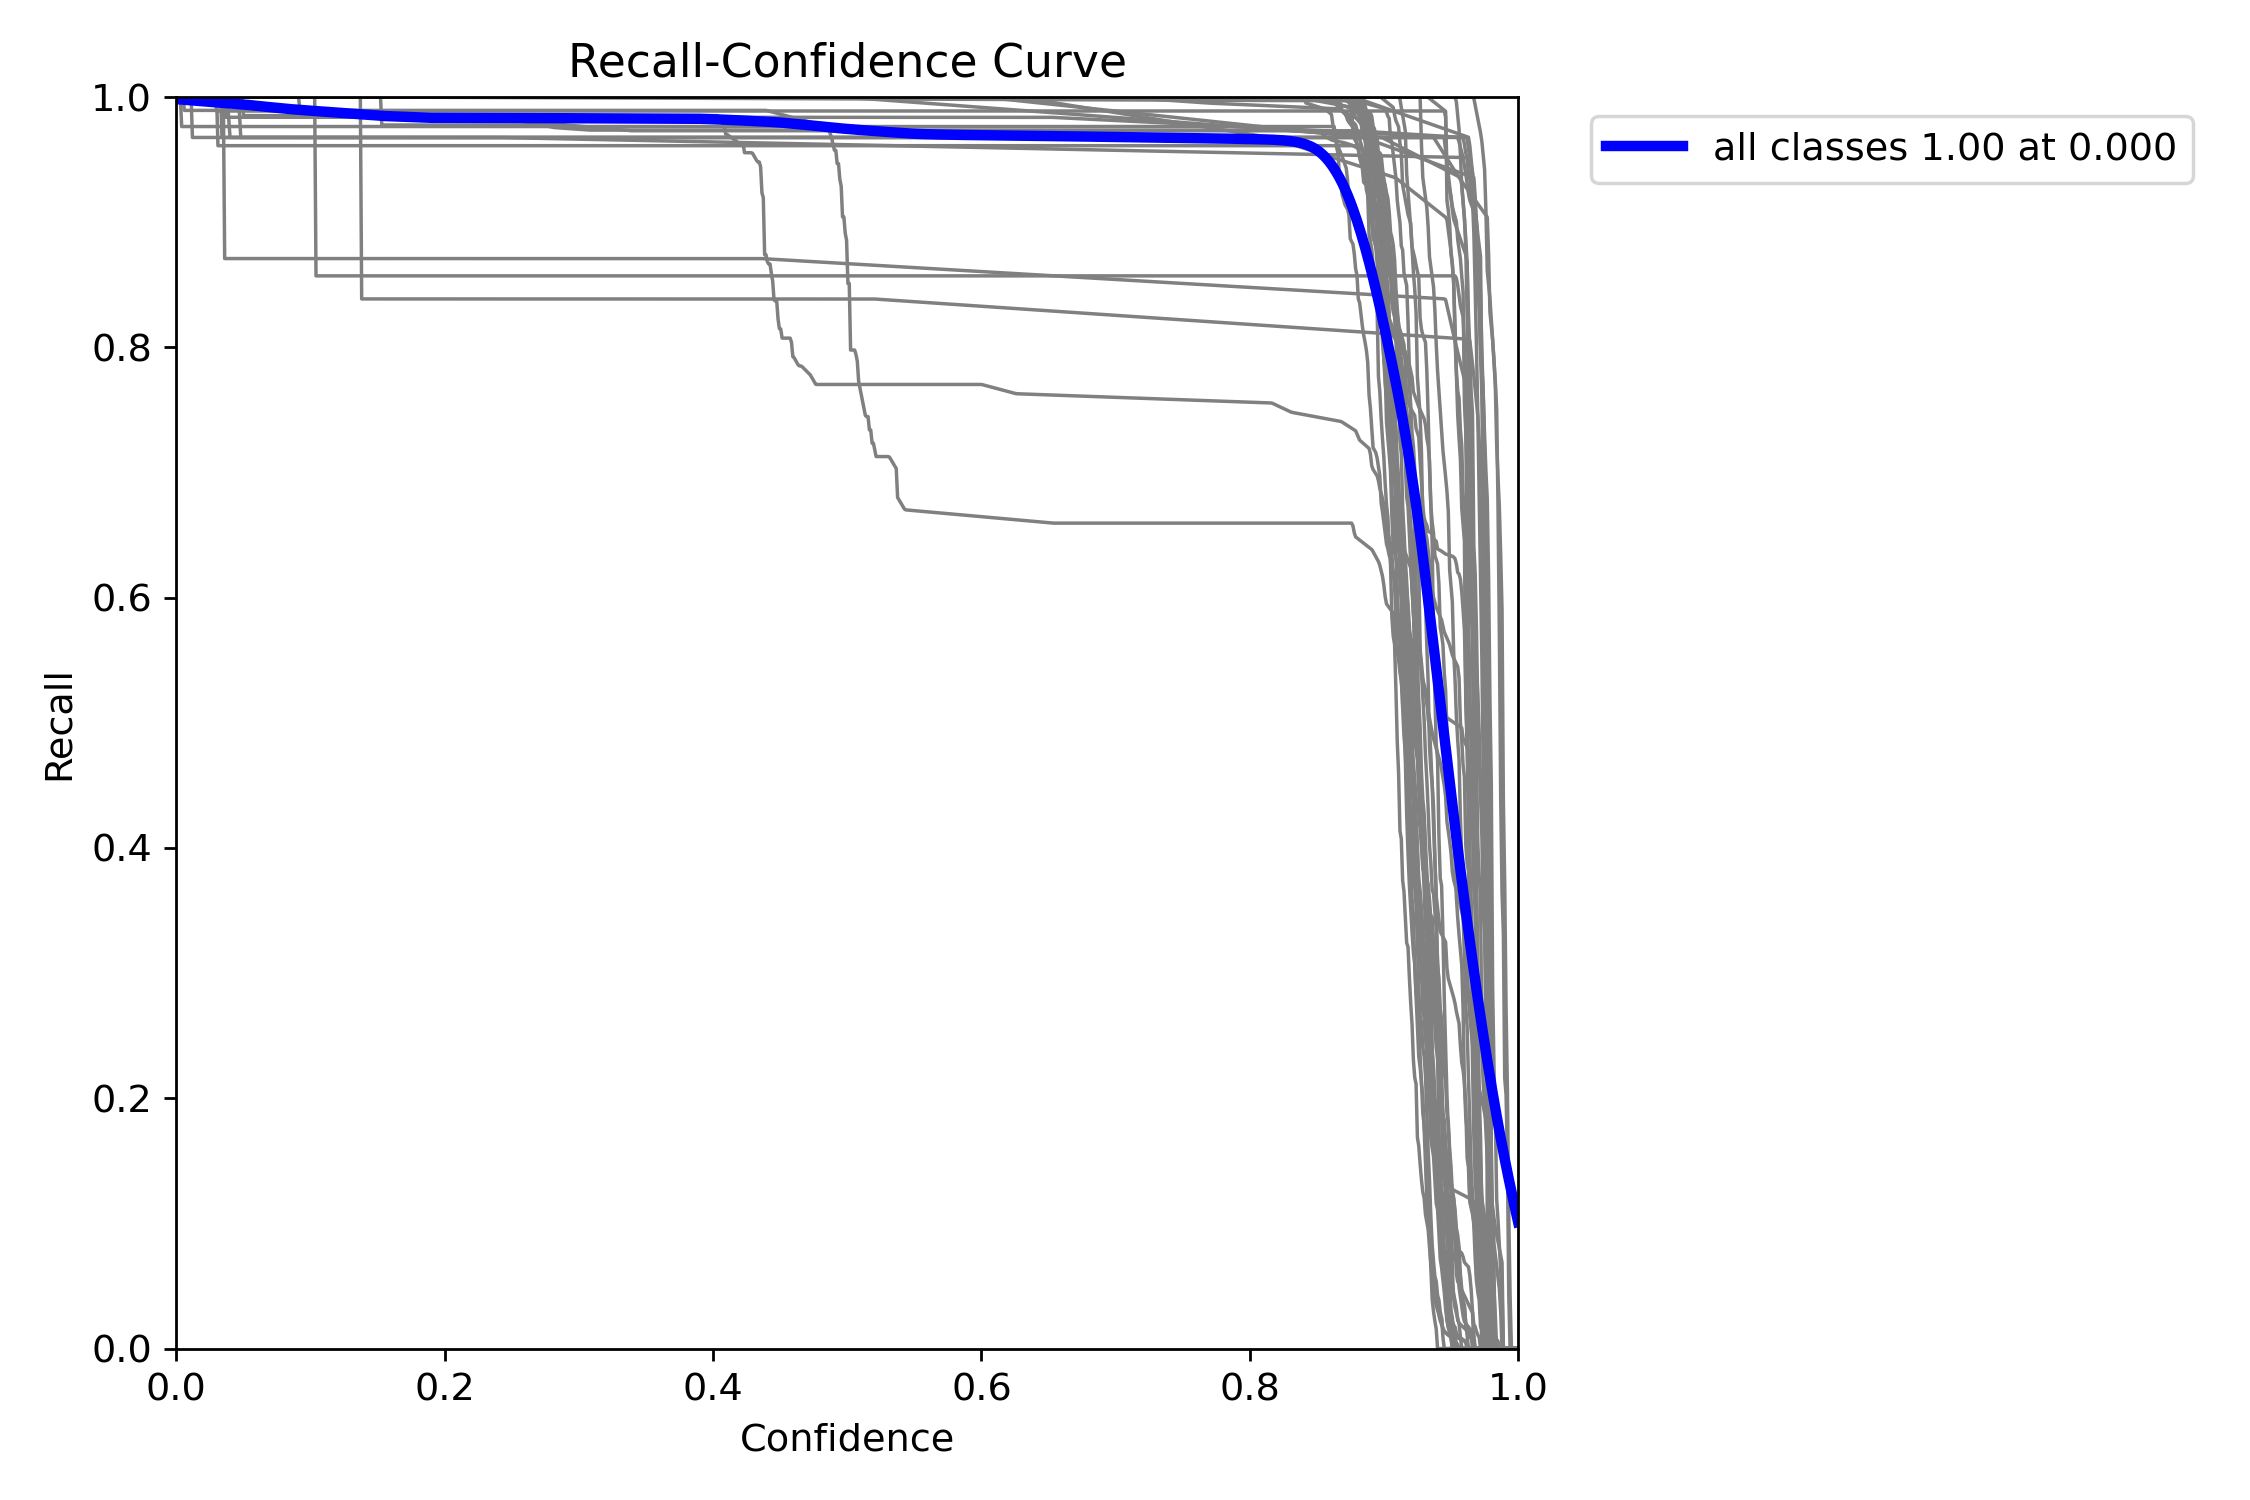


  Confusion Matrix


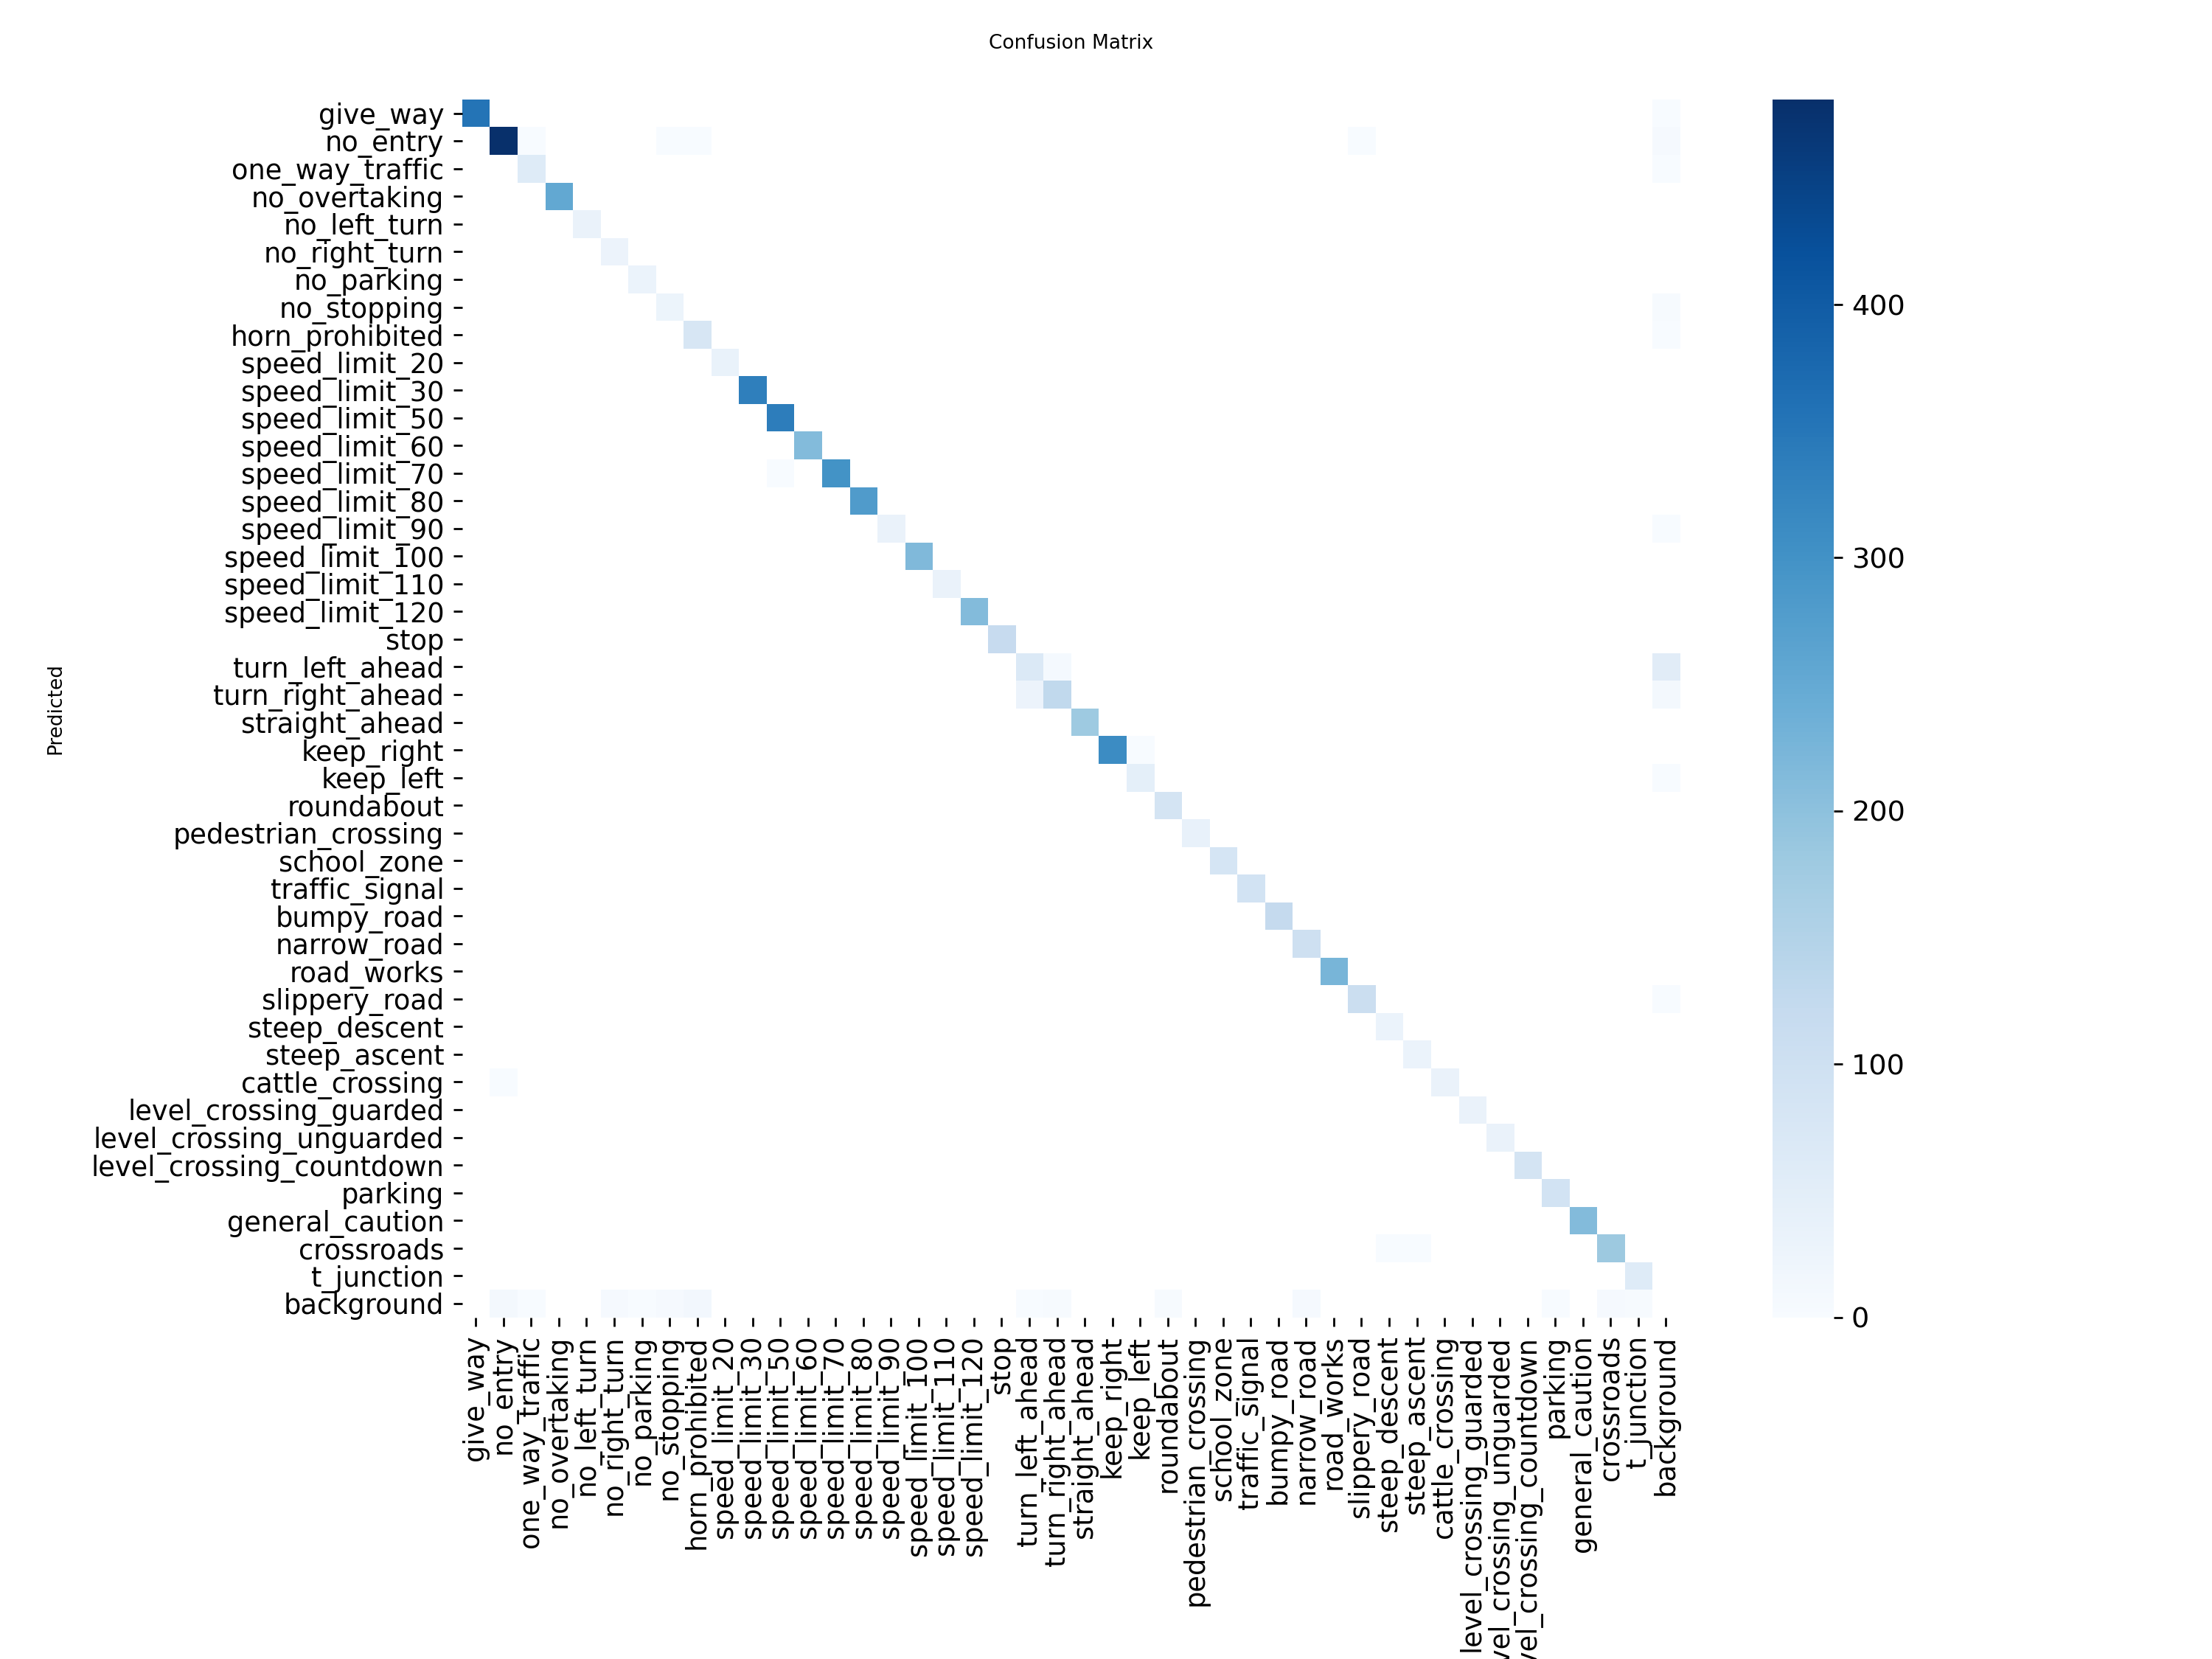


  Confusion Matrix Normalized


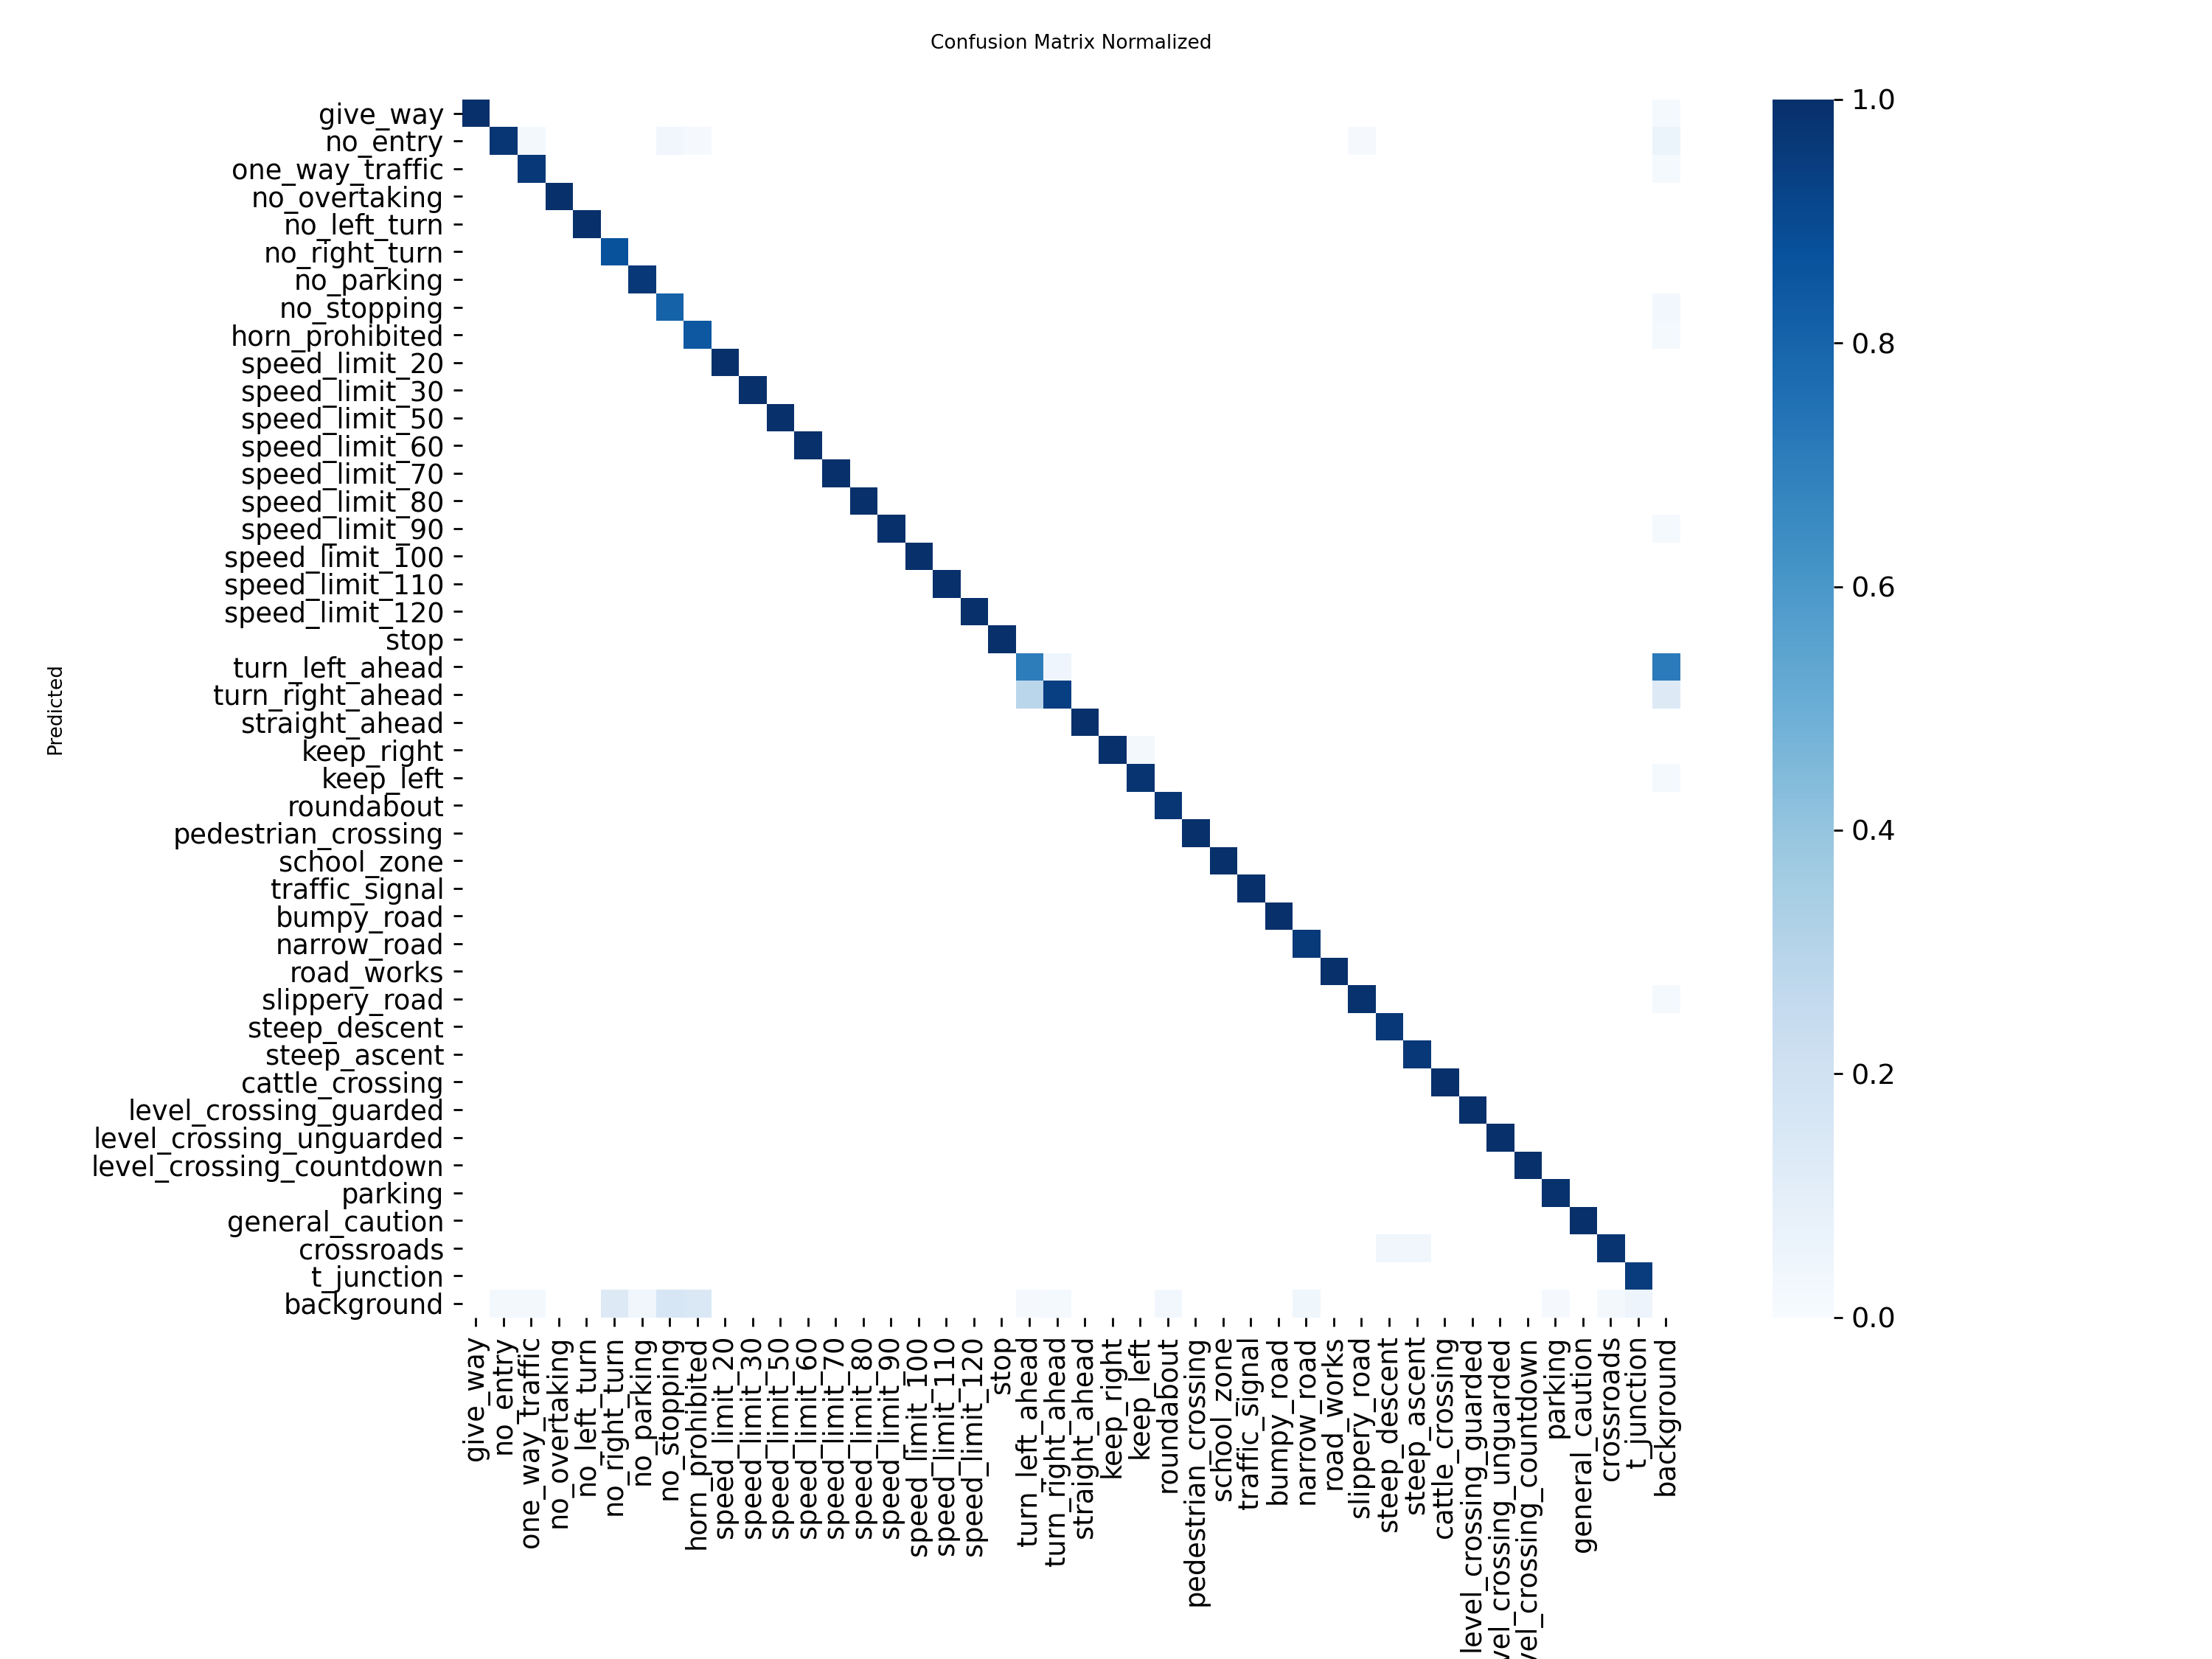


  Label Distribution


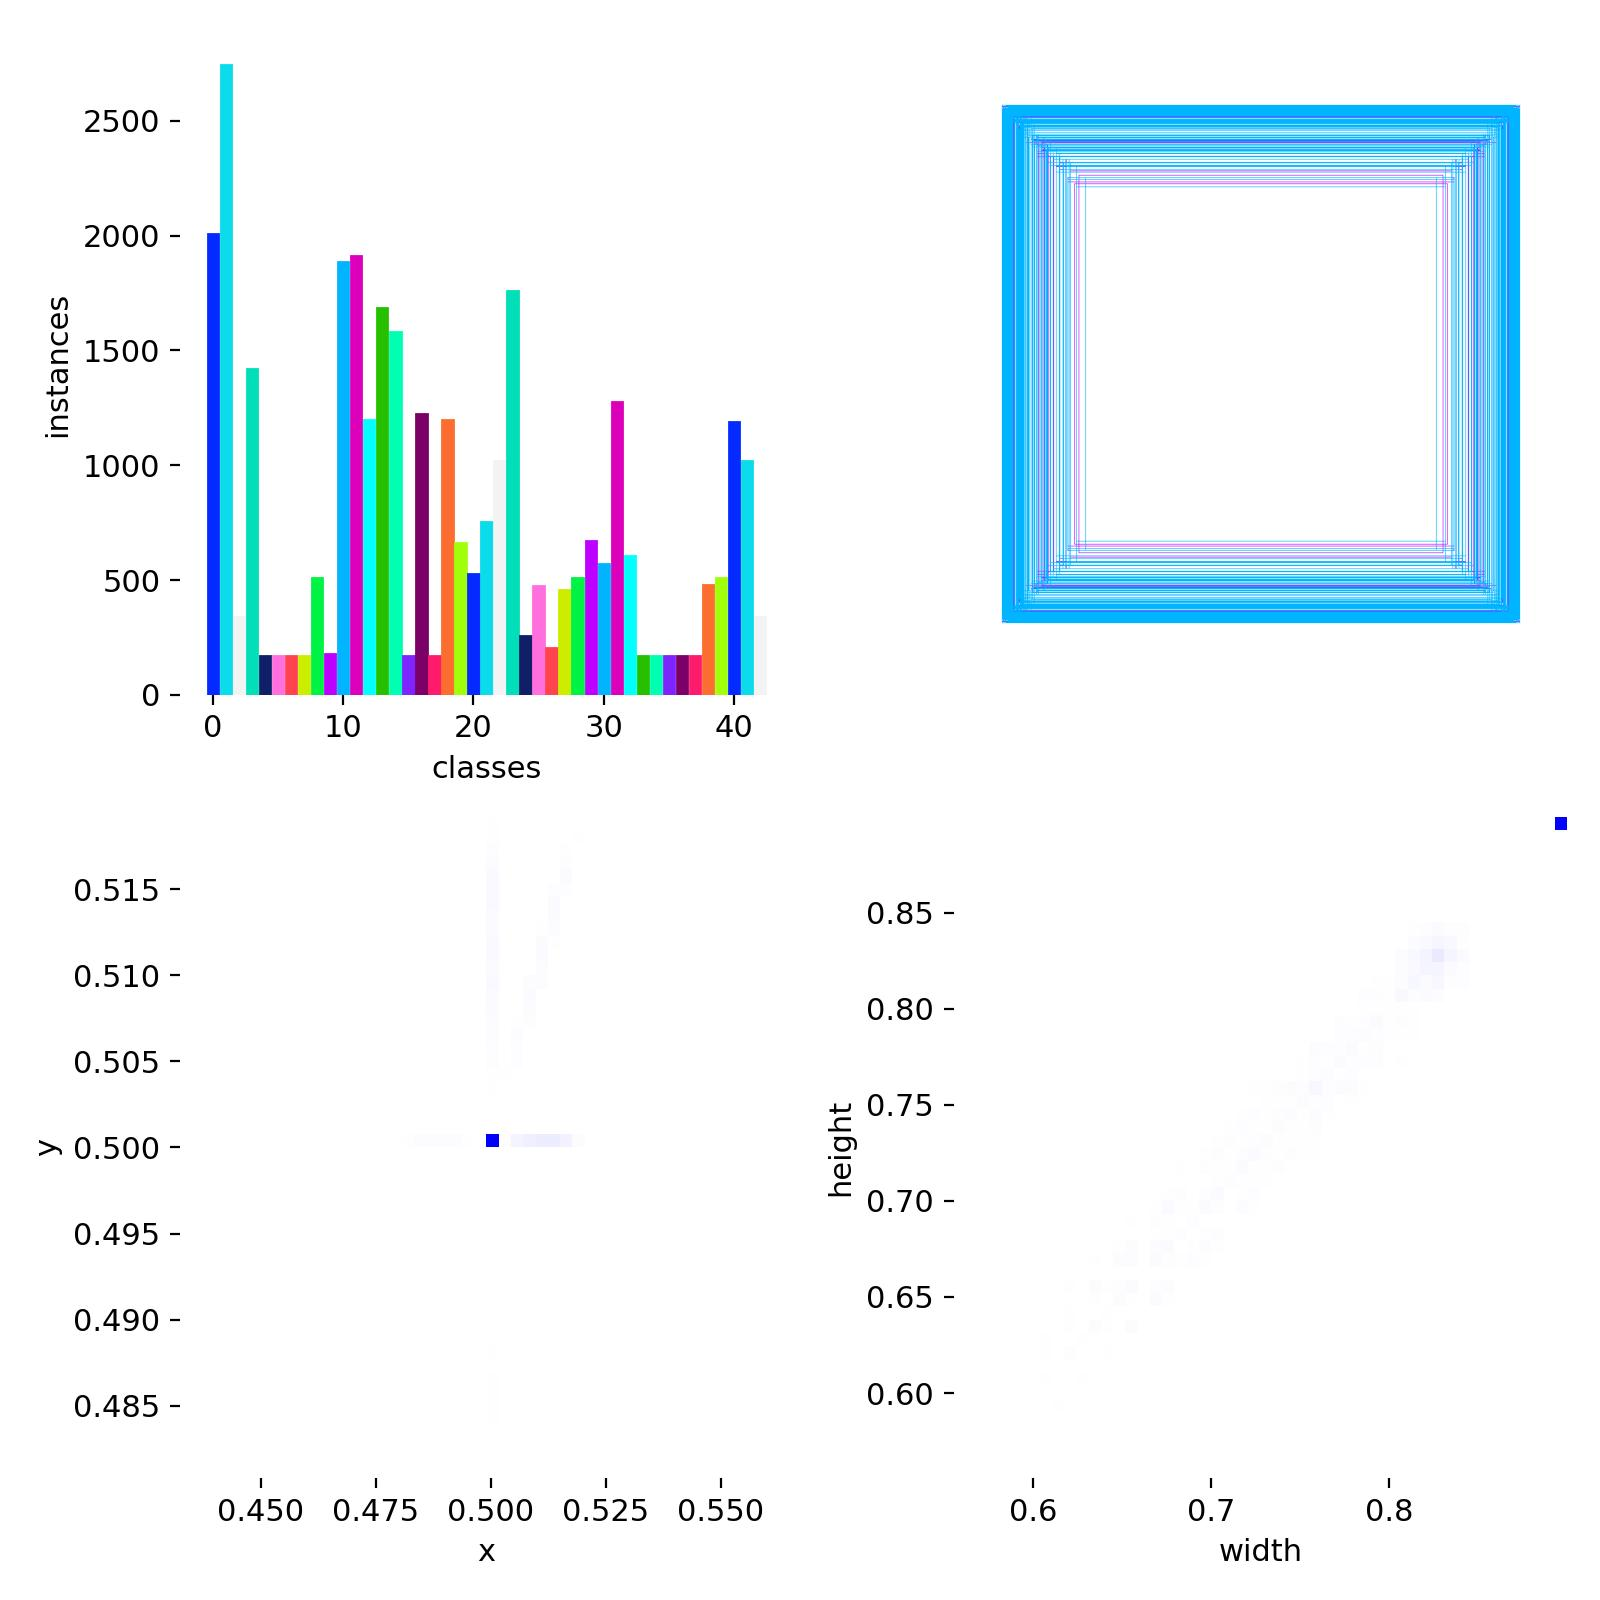


  Training Results


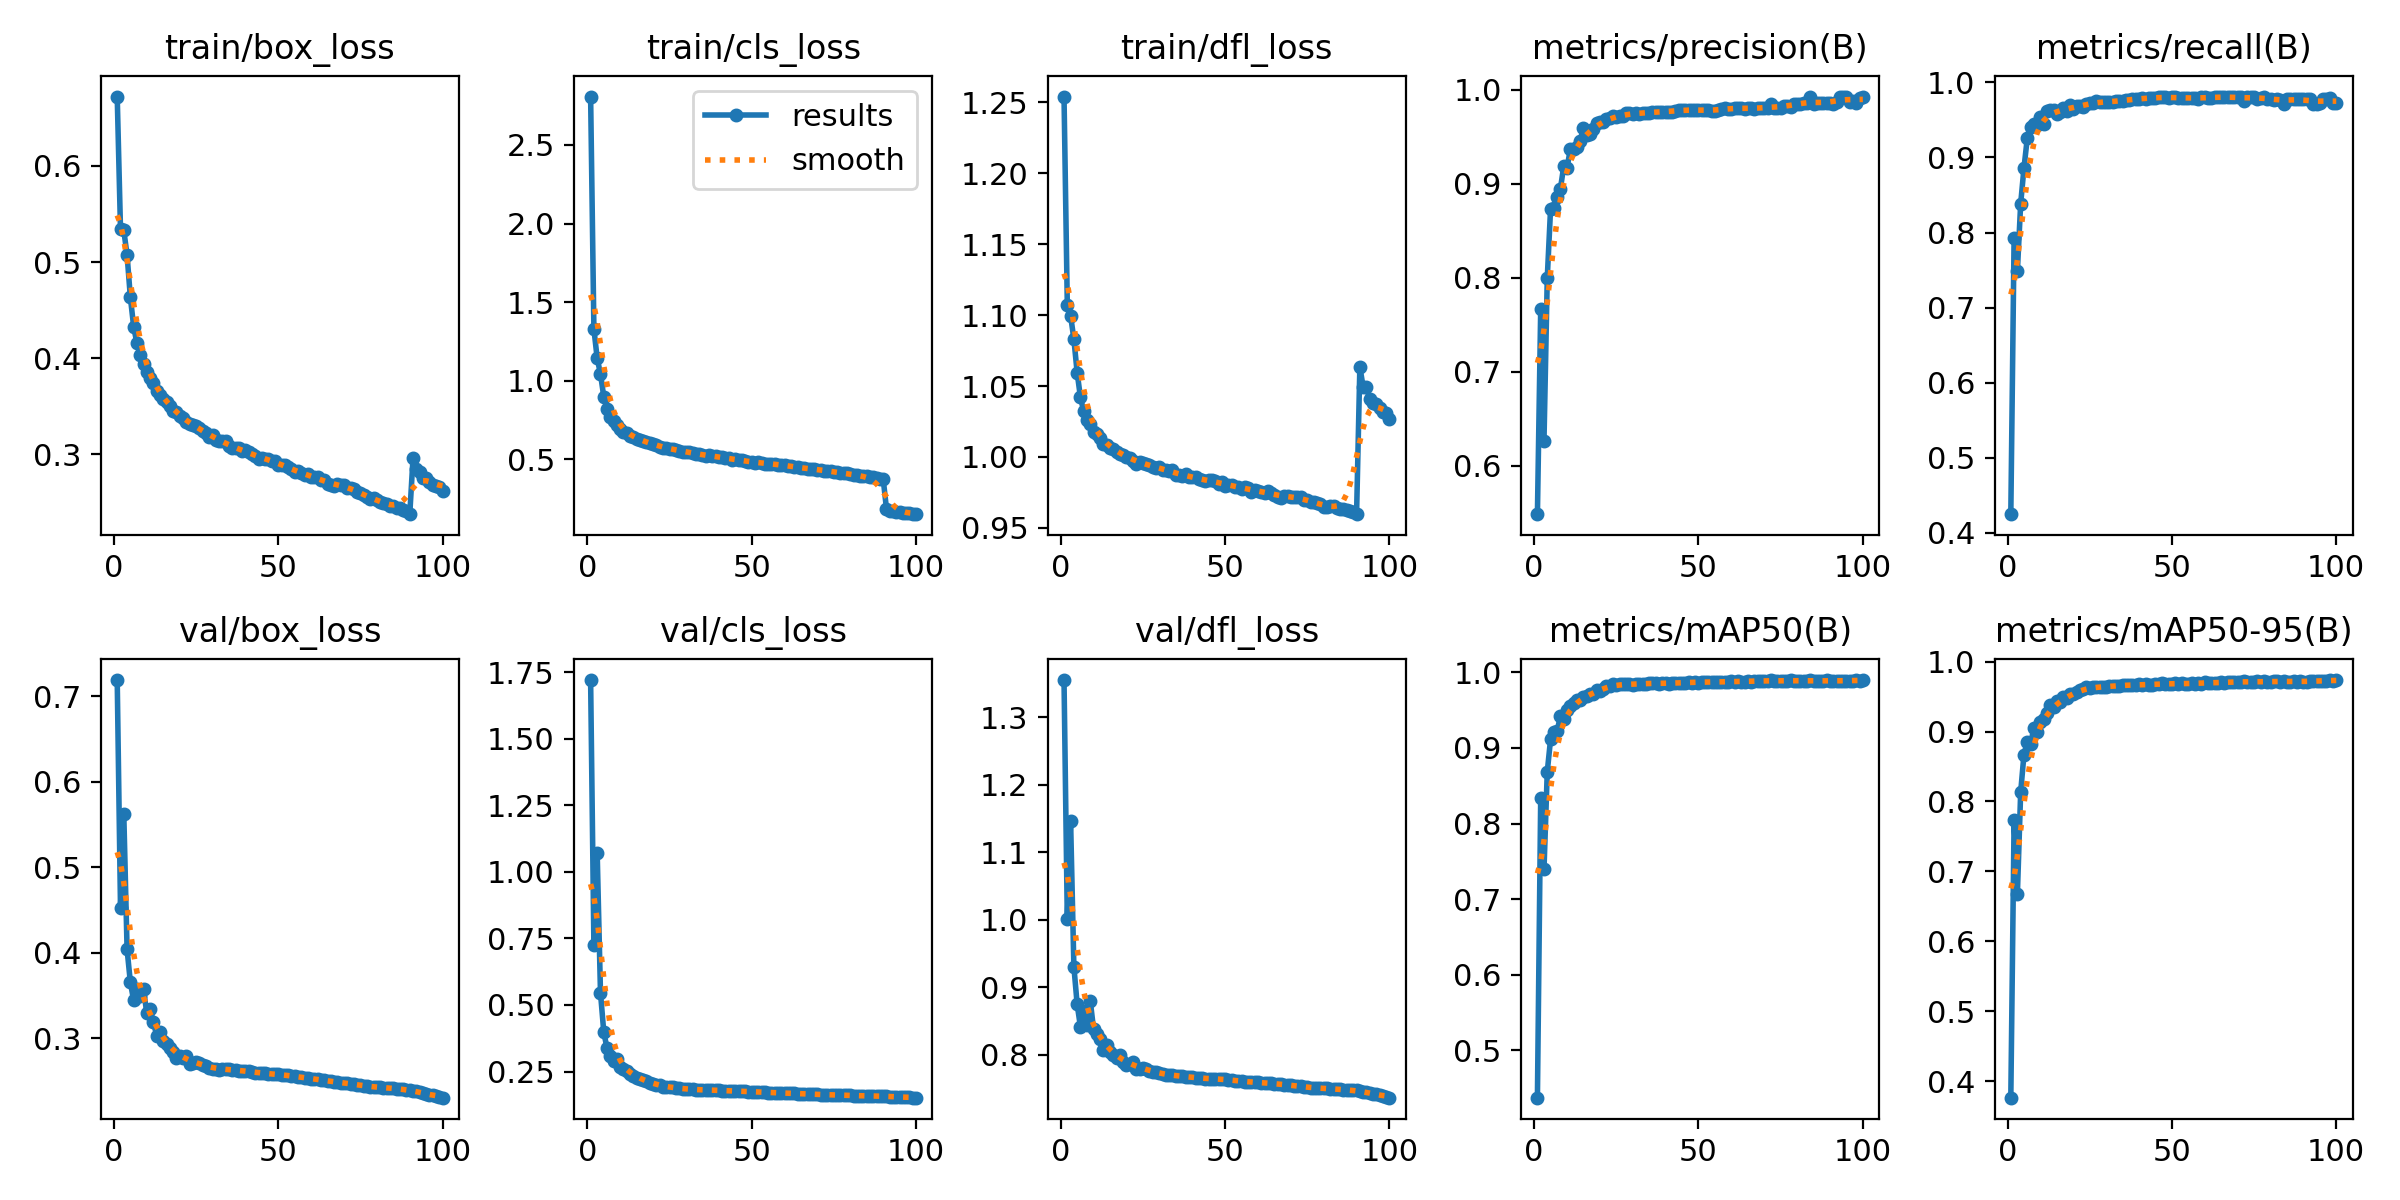

In [4]:
from IPython.display import Image, display
from pathlib import Path

run_dir = Path("/kaggle/input/datasets/paras2829/note-data/runs/detect/traffic_sign_v1")

plots = [
    ("Box F1 Curve",                  "BoxF1_curve.png"),
    ("Box PR Curve",                  "BoxPR_curve.png"),
    ("Box Precision Curve",           "BoxP_curve.png"),
    ("Box Recall Curve",              "BoxR_curve.png"),
    ("Confusion Matrix",              "confusion_matrix.png"),
    ("Confusion Matrix Normalized",   "confusion_matrix_normalized.png"),
    ("Label Distribution",            "labels.jpg"),
    ("Training Results",              "results.png"),
]

for title, filename in plots:
    path = run_dir / filename
    if path.exists():
        print(f"\n{'='*60}")
        print(f"  {title}")
        print(f"{'='*60}")
        display(Image(filename=str(path), width=900))
    else:
        print(f"[NOT FOUND] {filename}")

TRAINING BATCH SAMPLES


>>> train_batch0.jpg


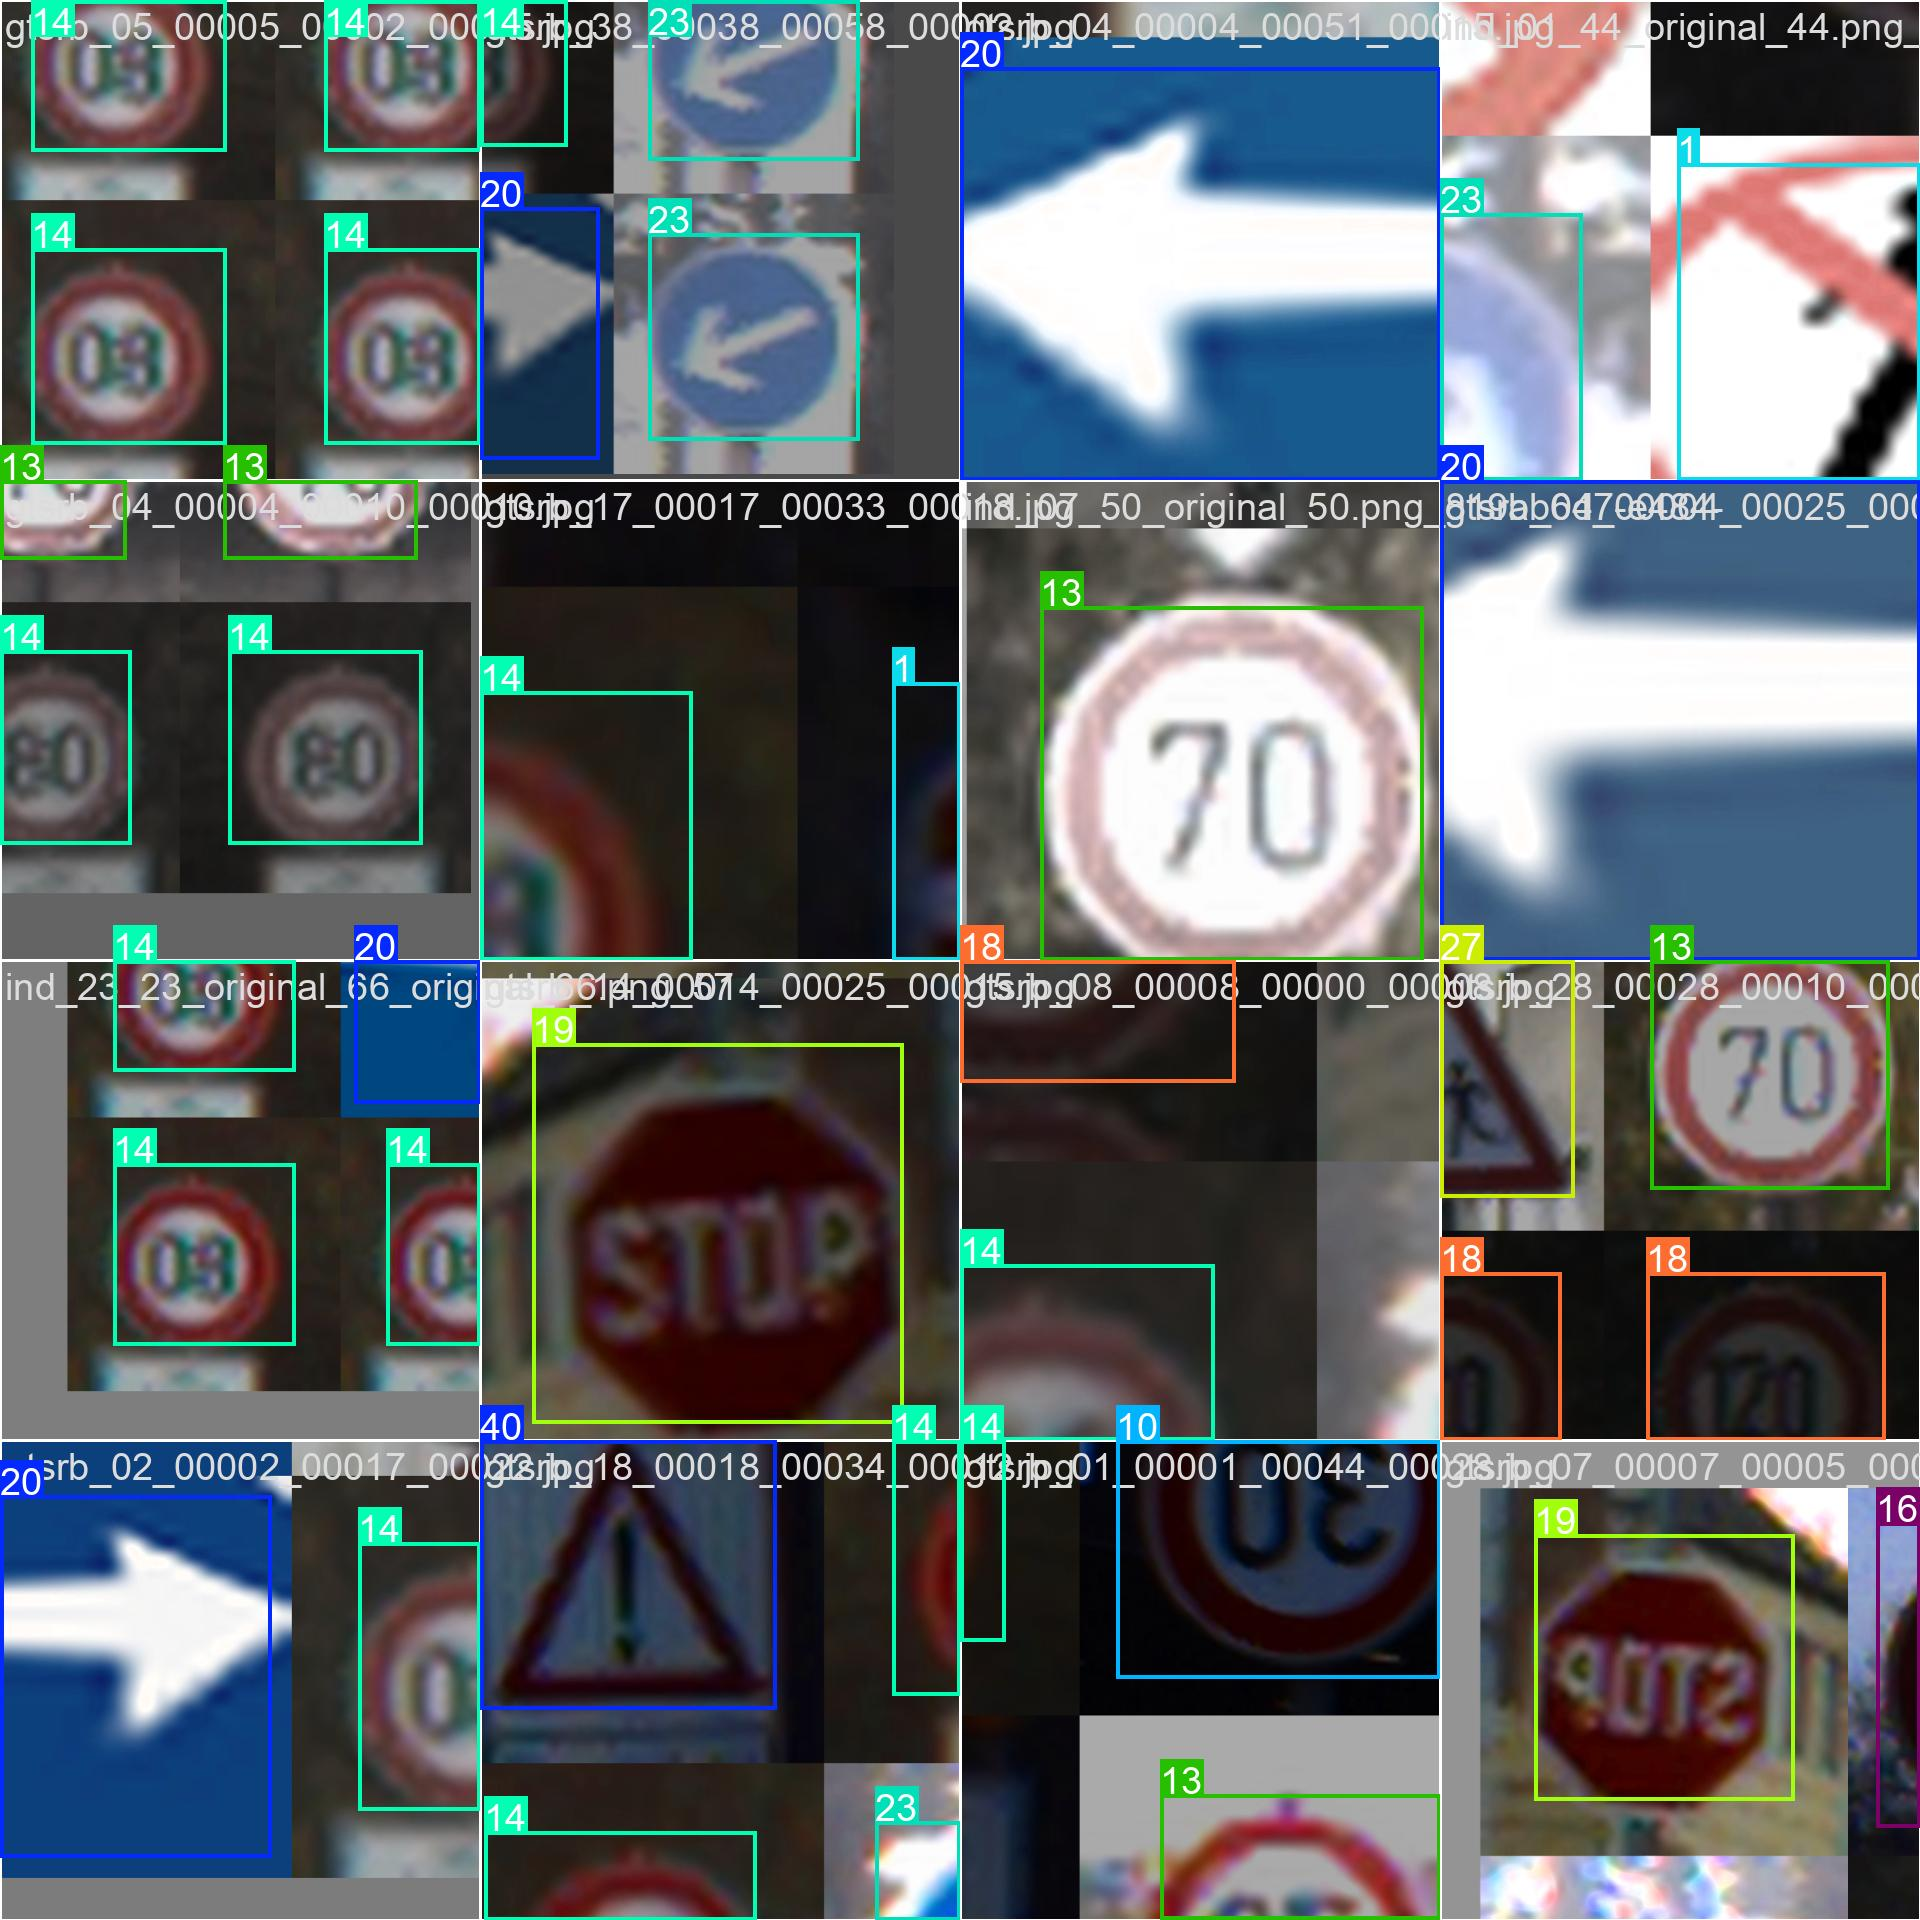


>>> train_batch1.jpg


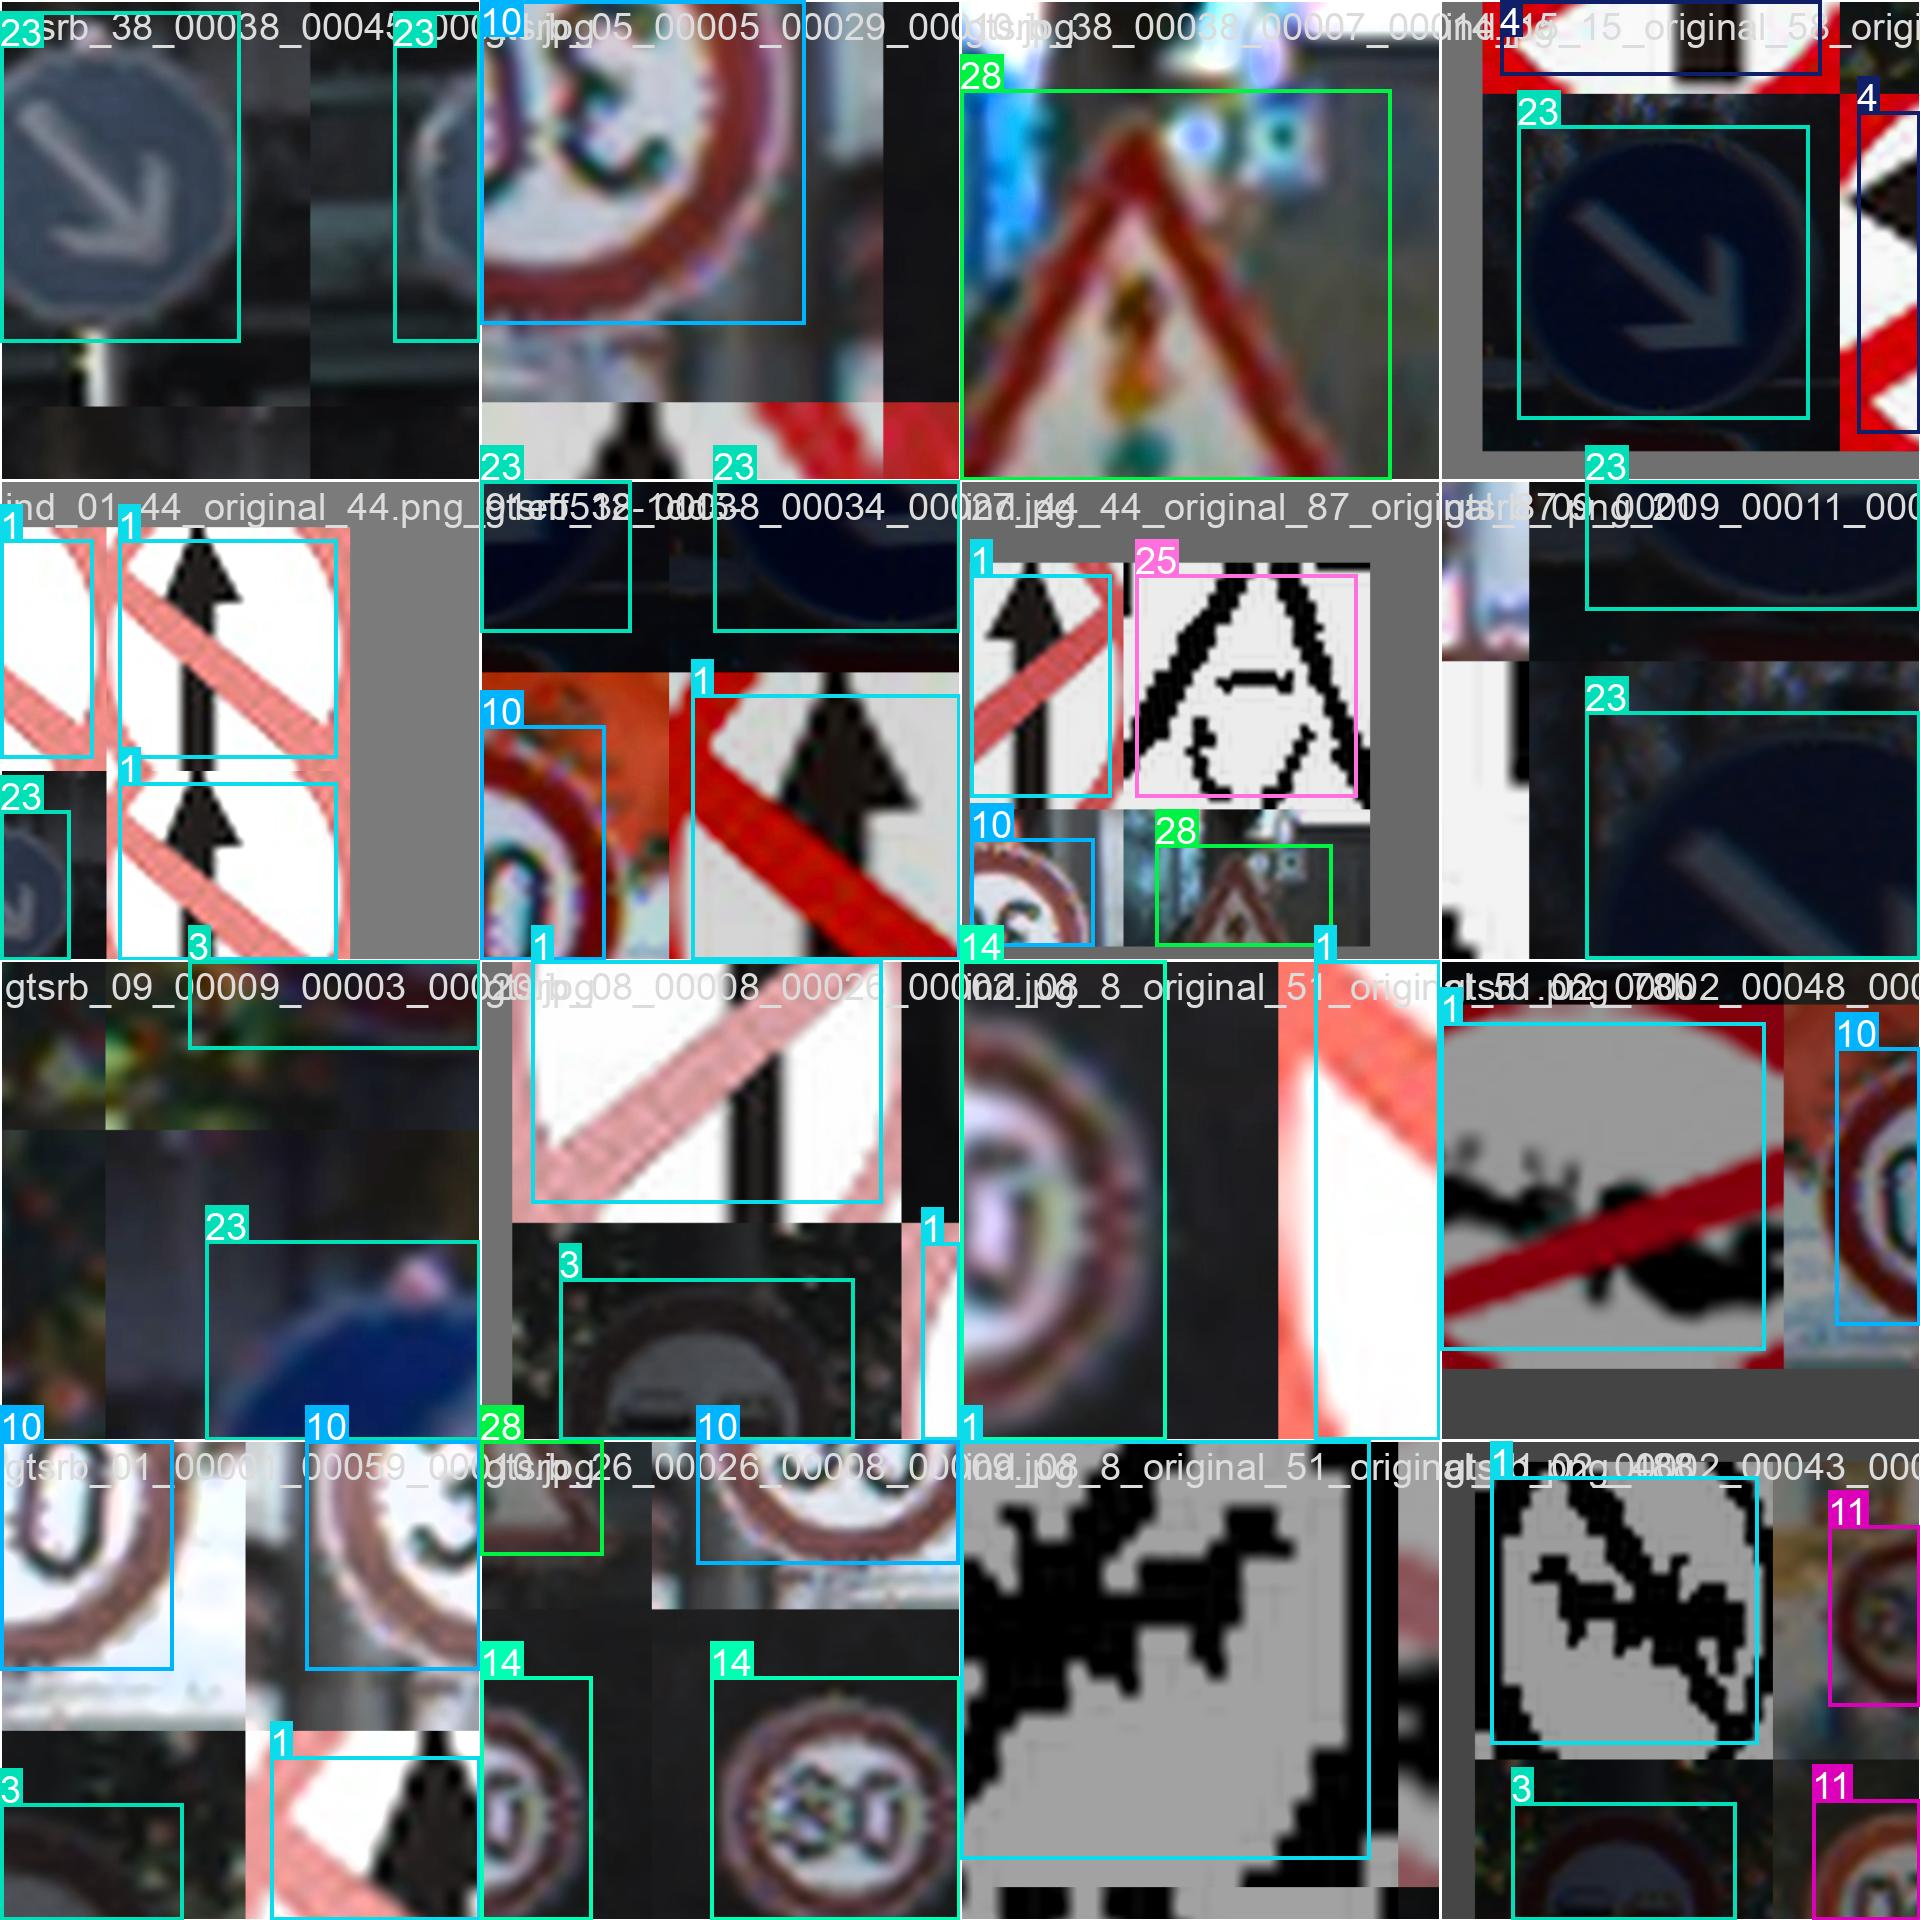


>>> train_batch2.jpg


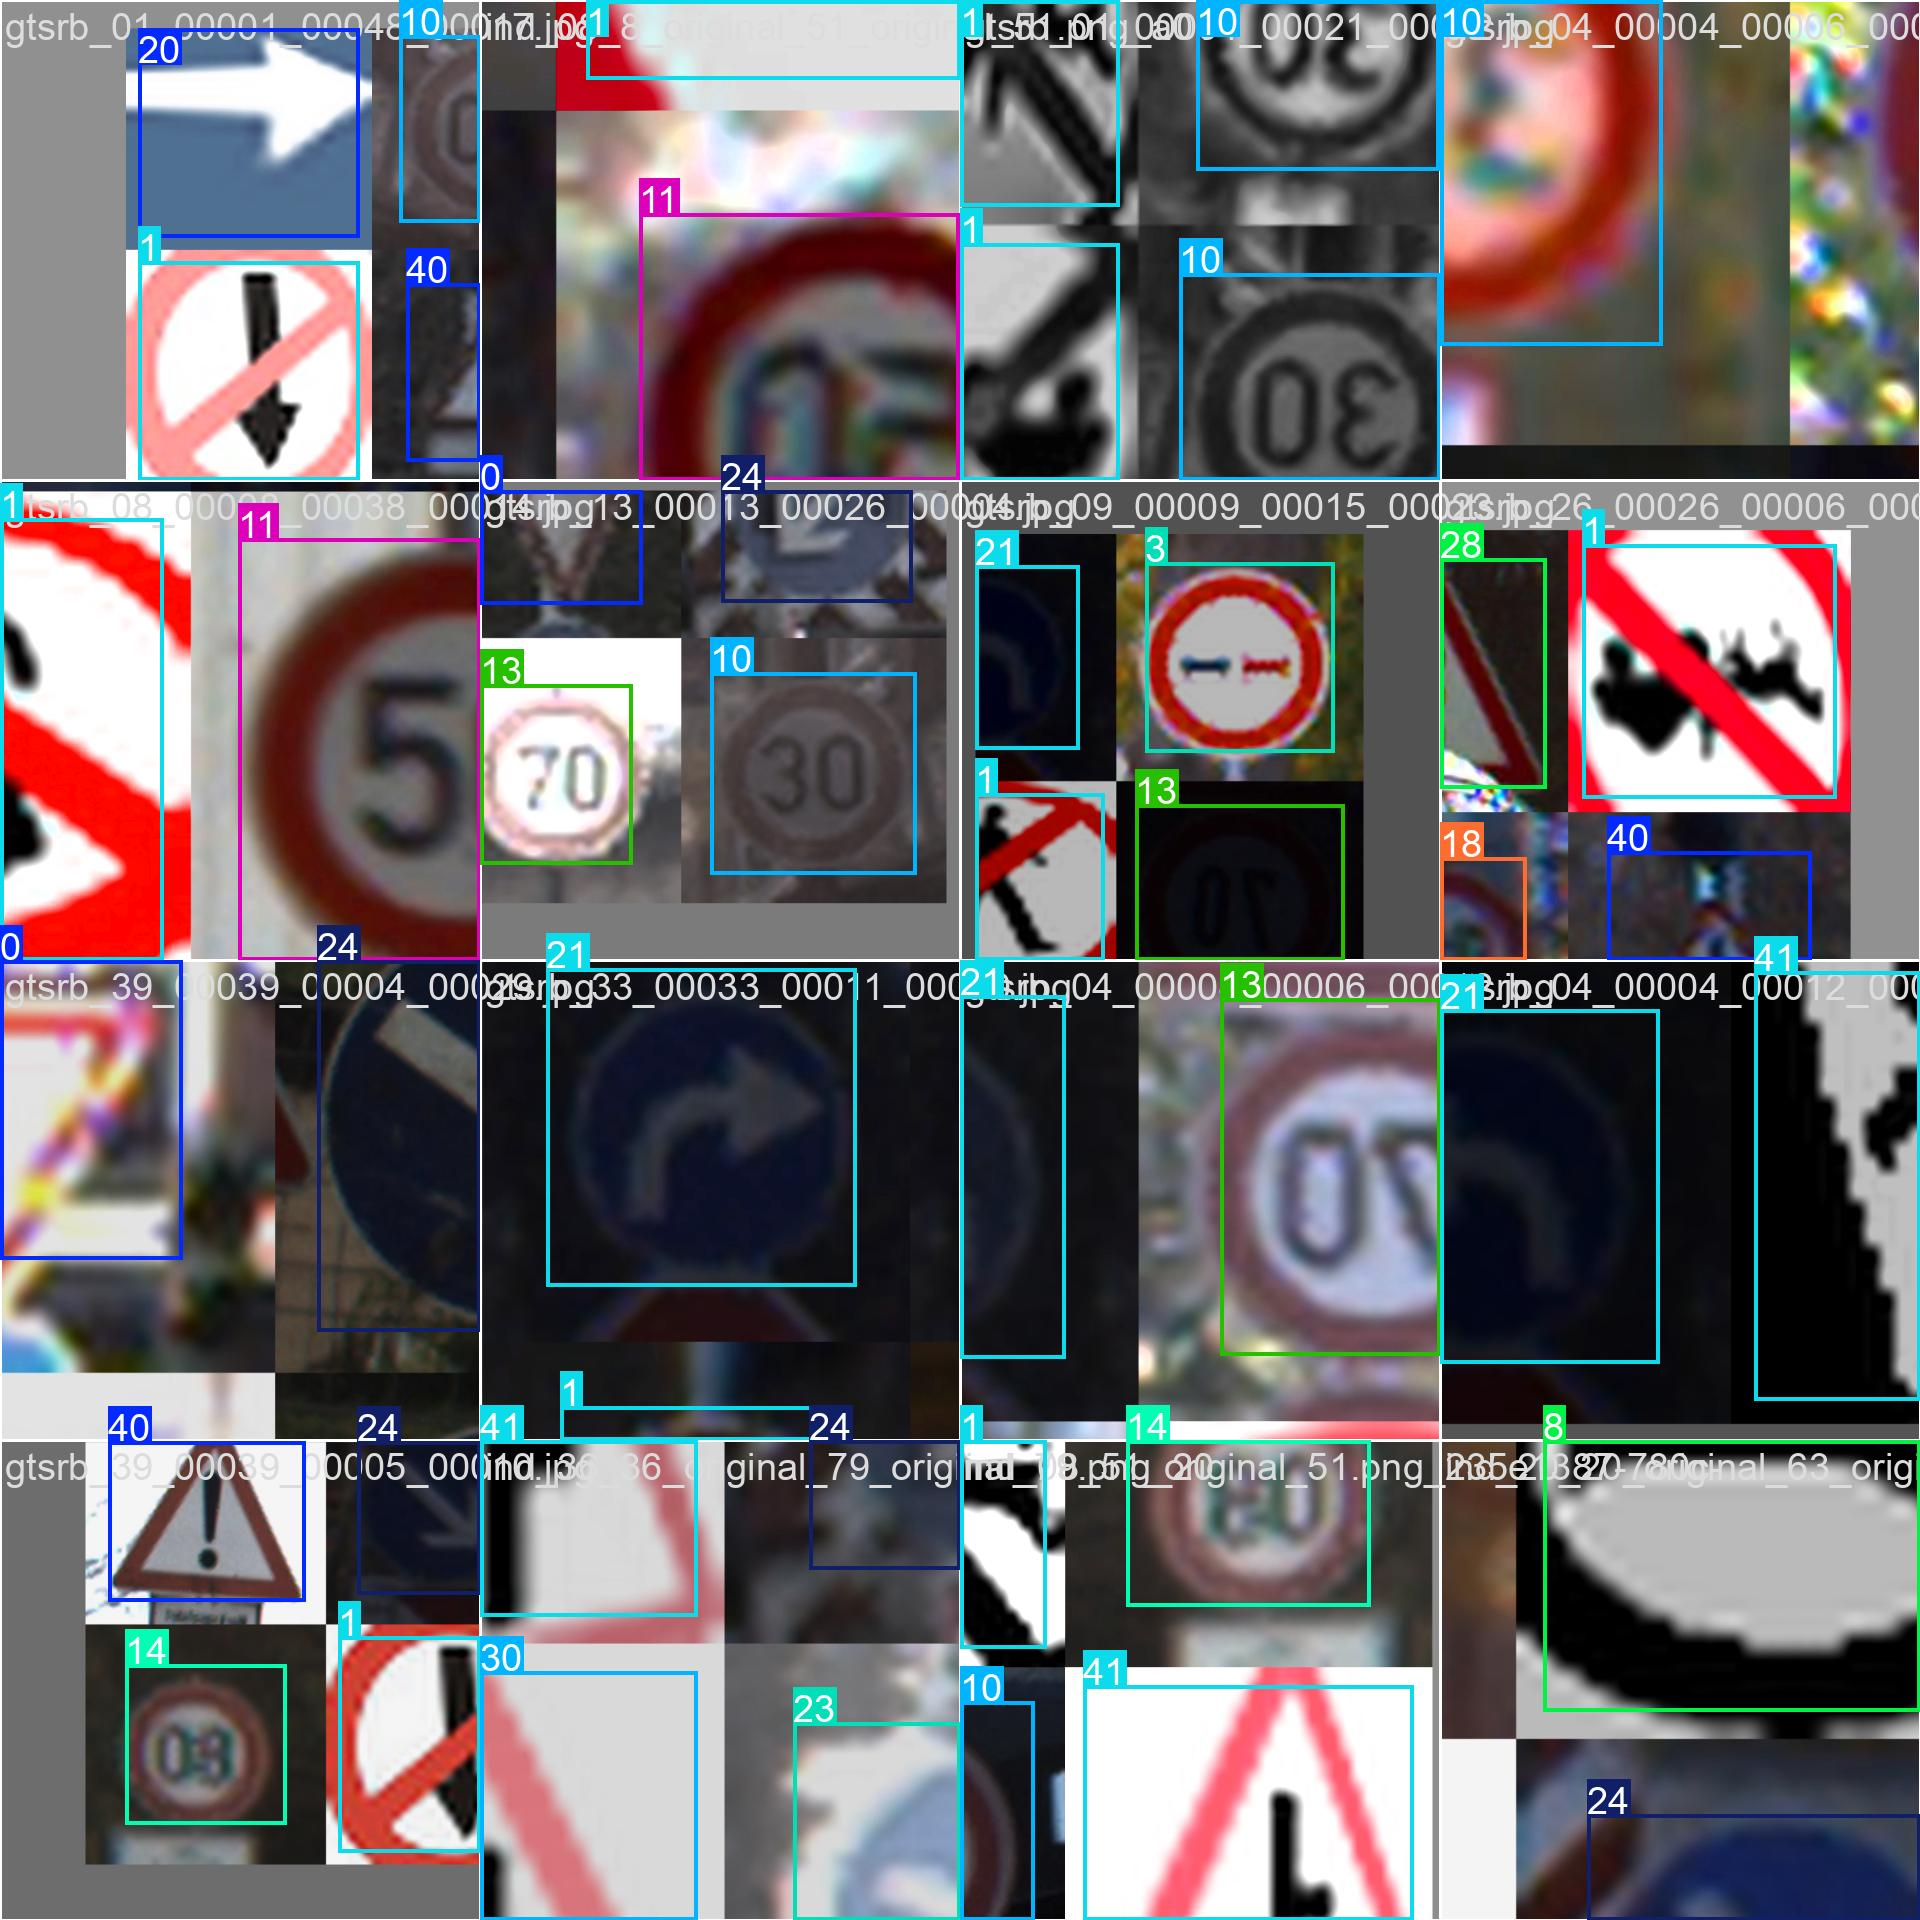


>>> train_batch92970.jpg


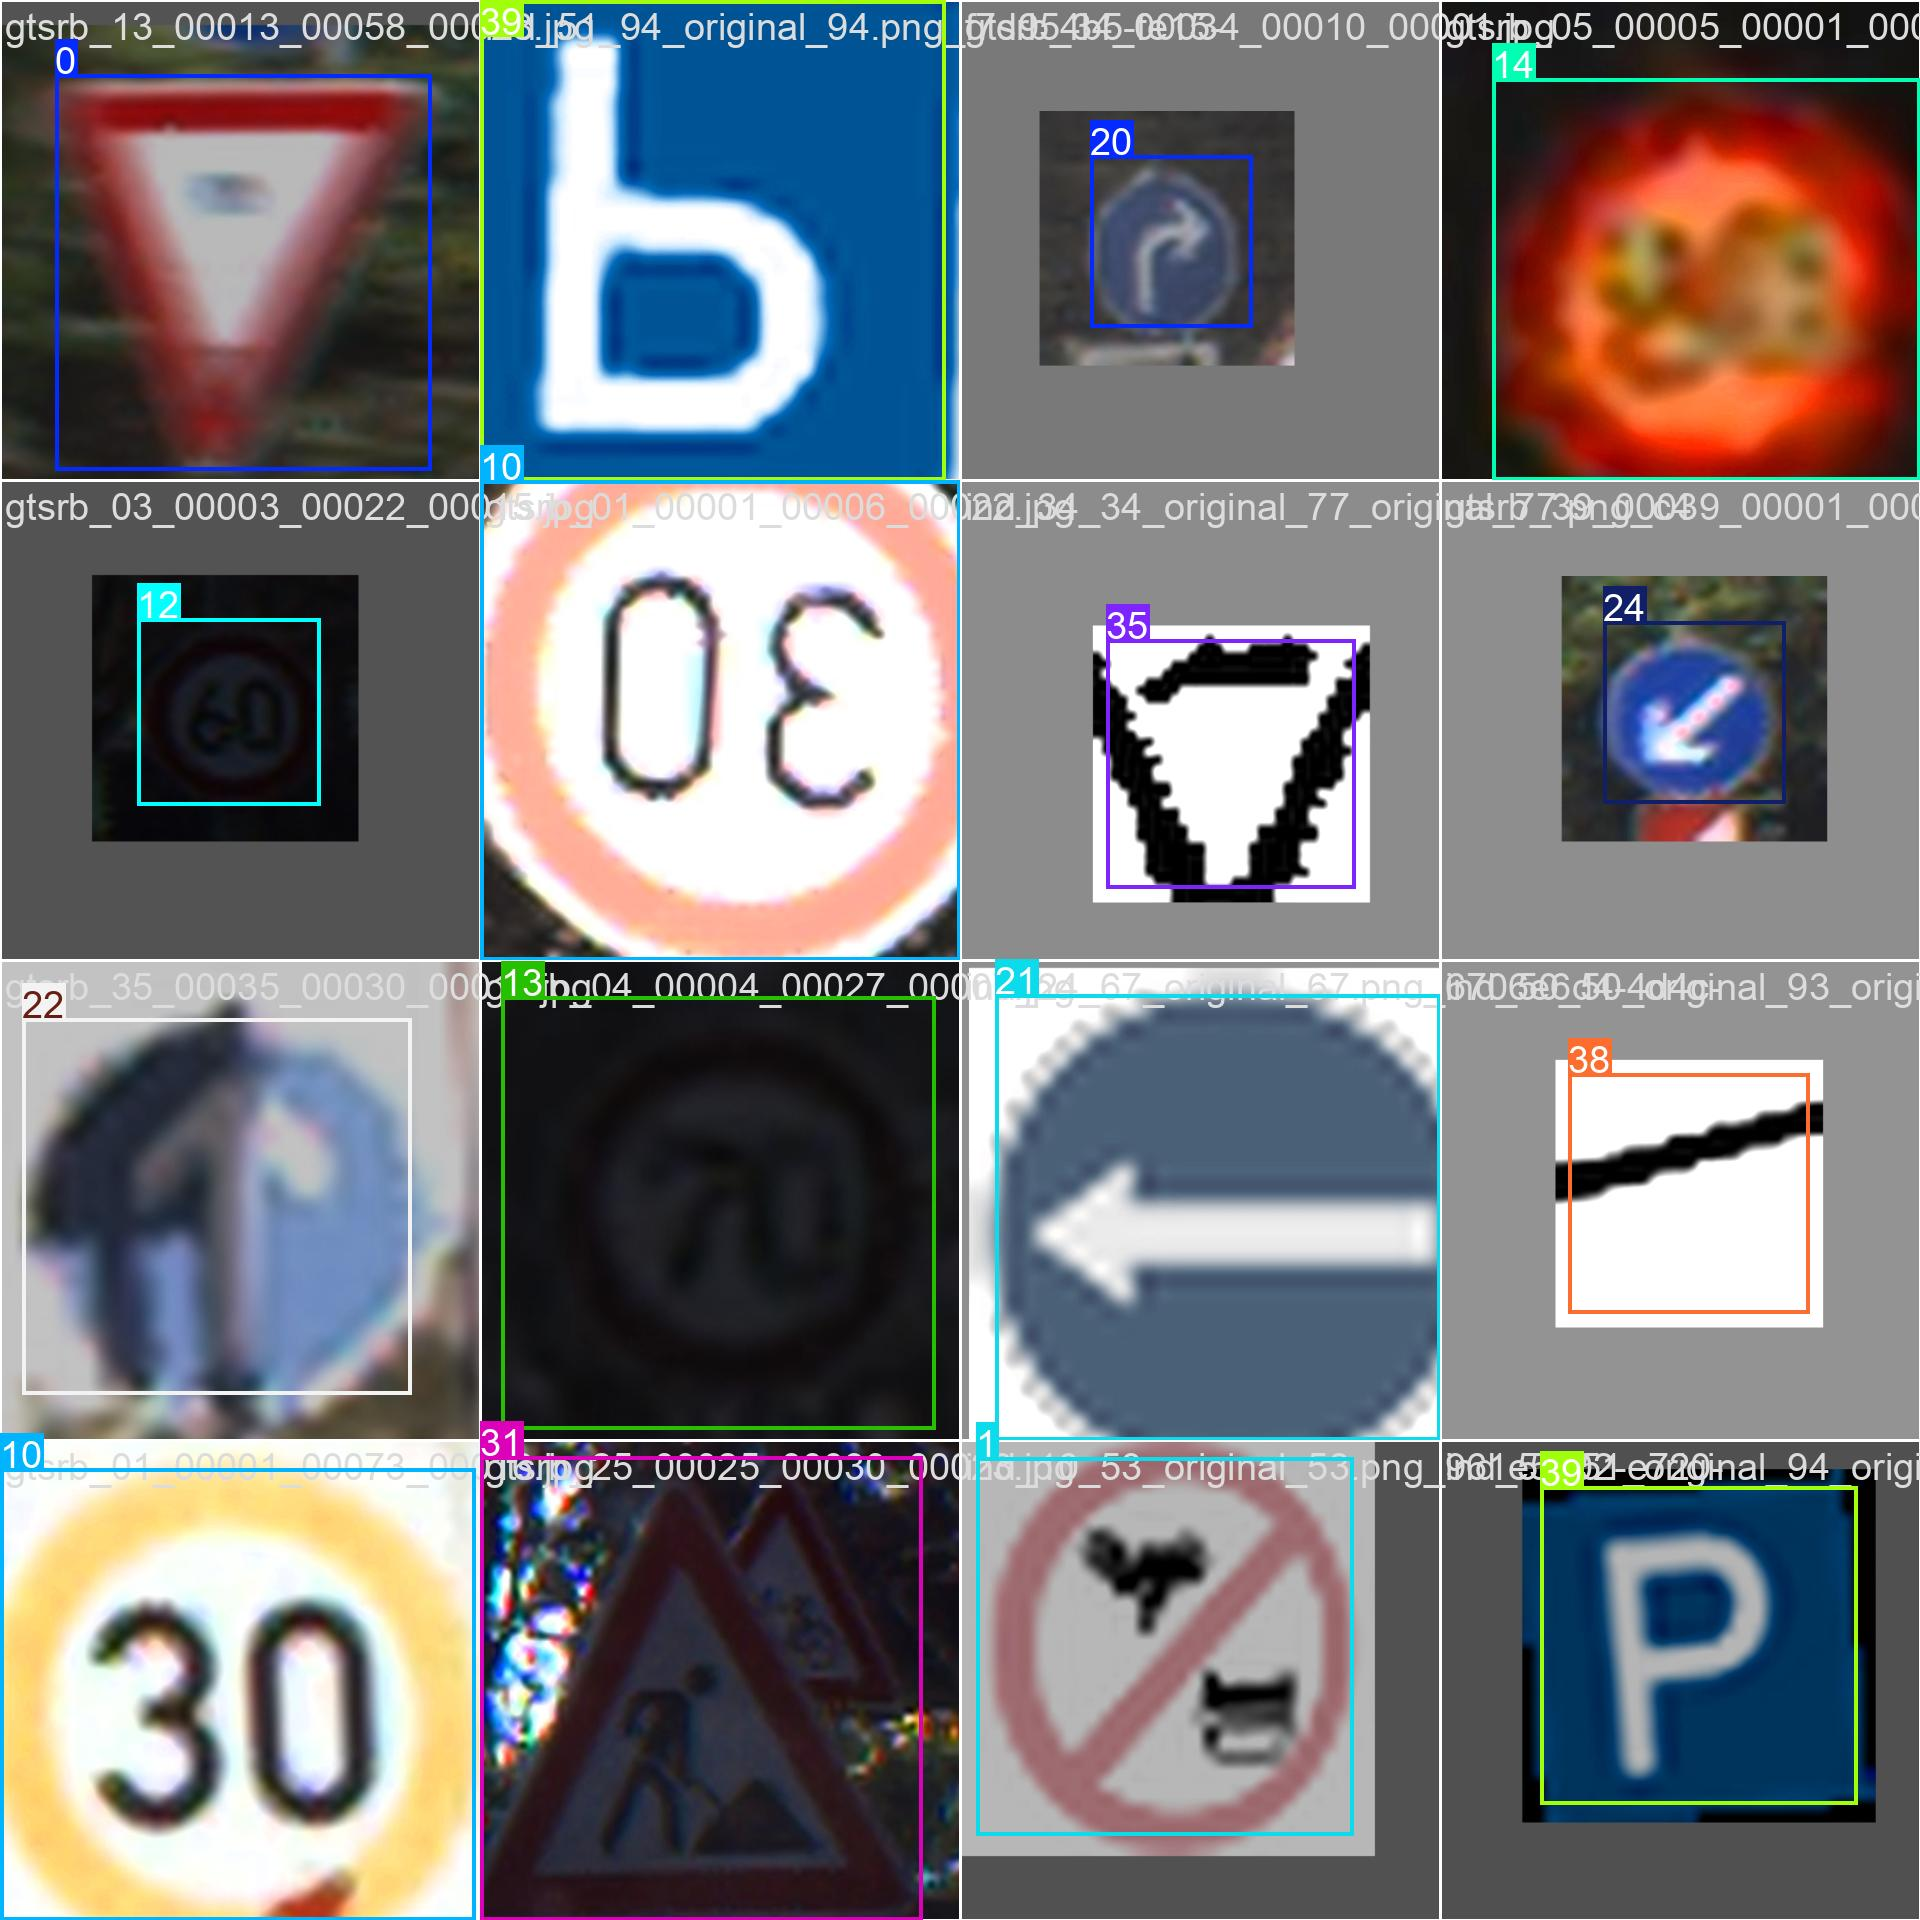


>>> train_batch92971.jpg


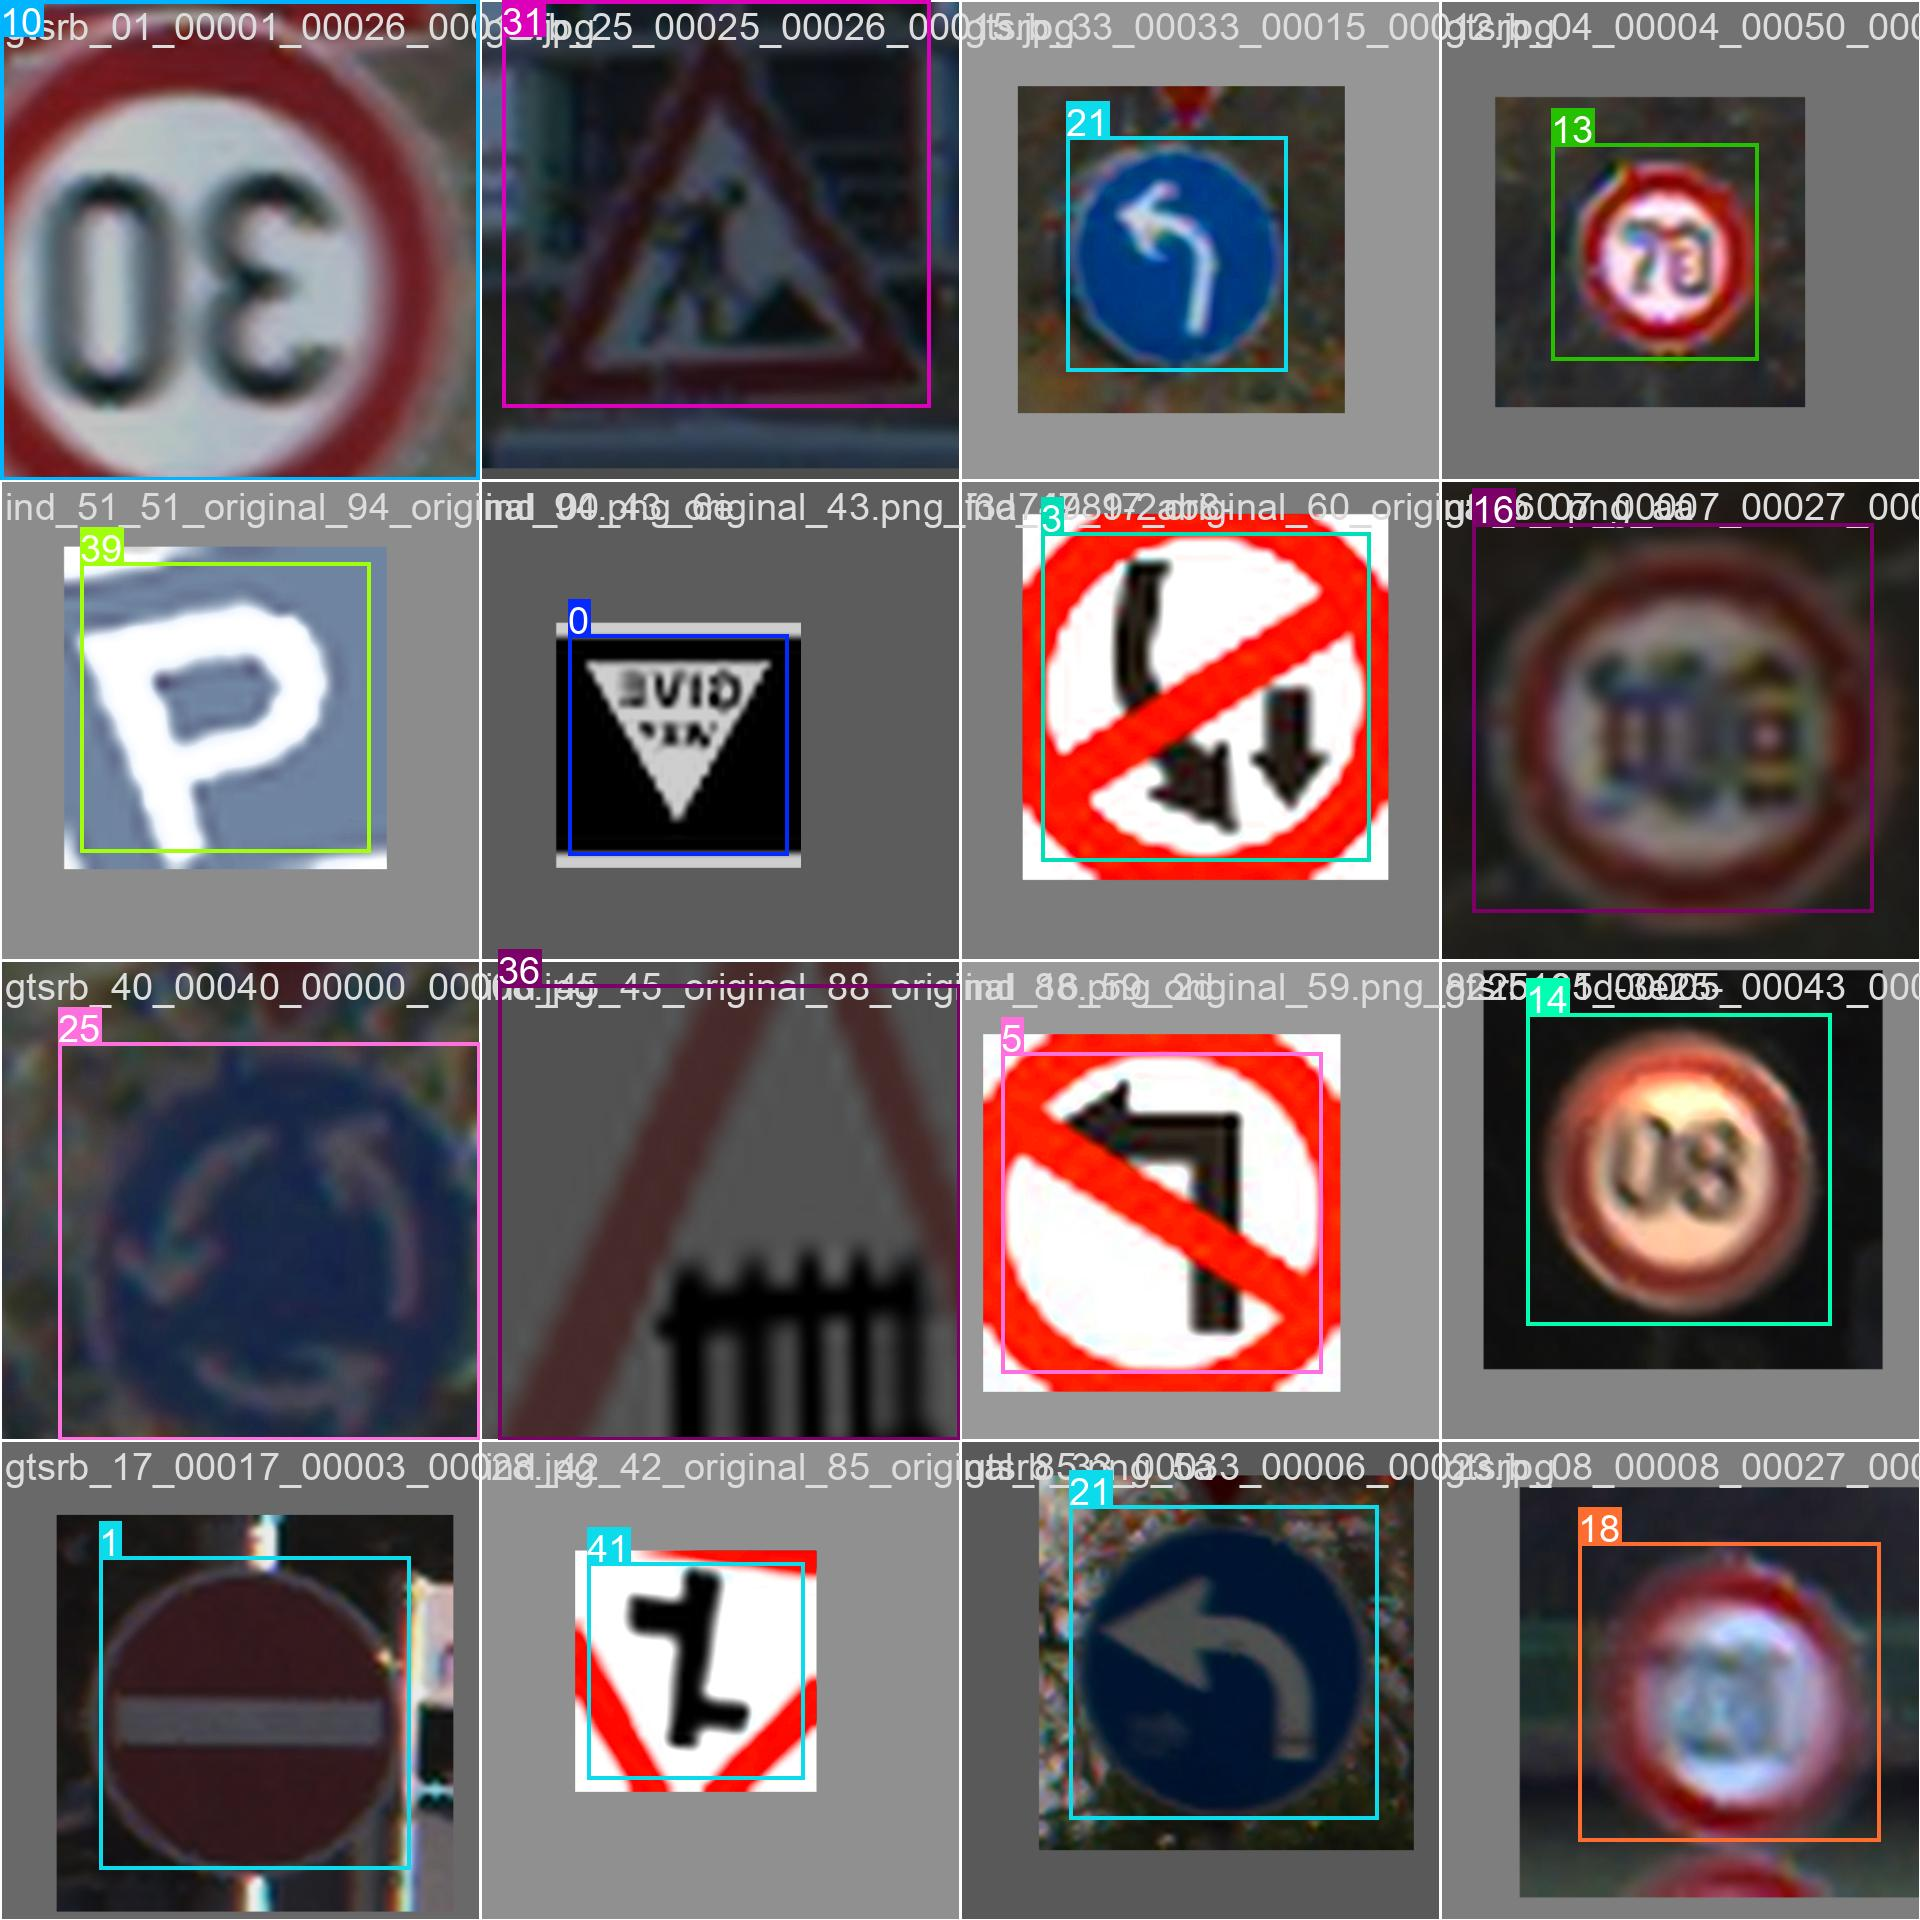


>>> train_batch92972.jpg


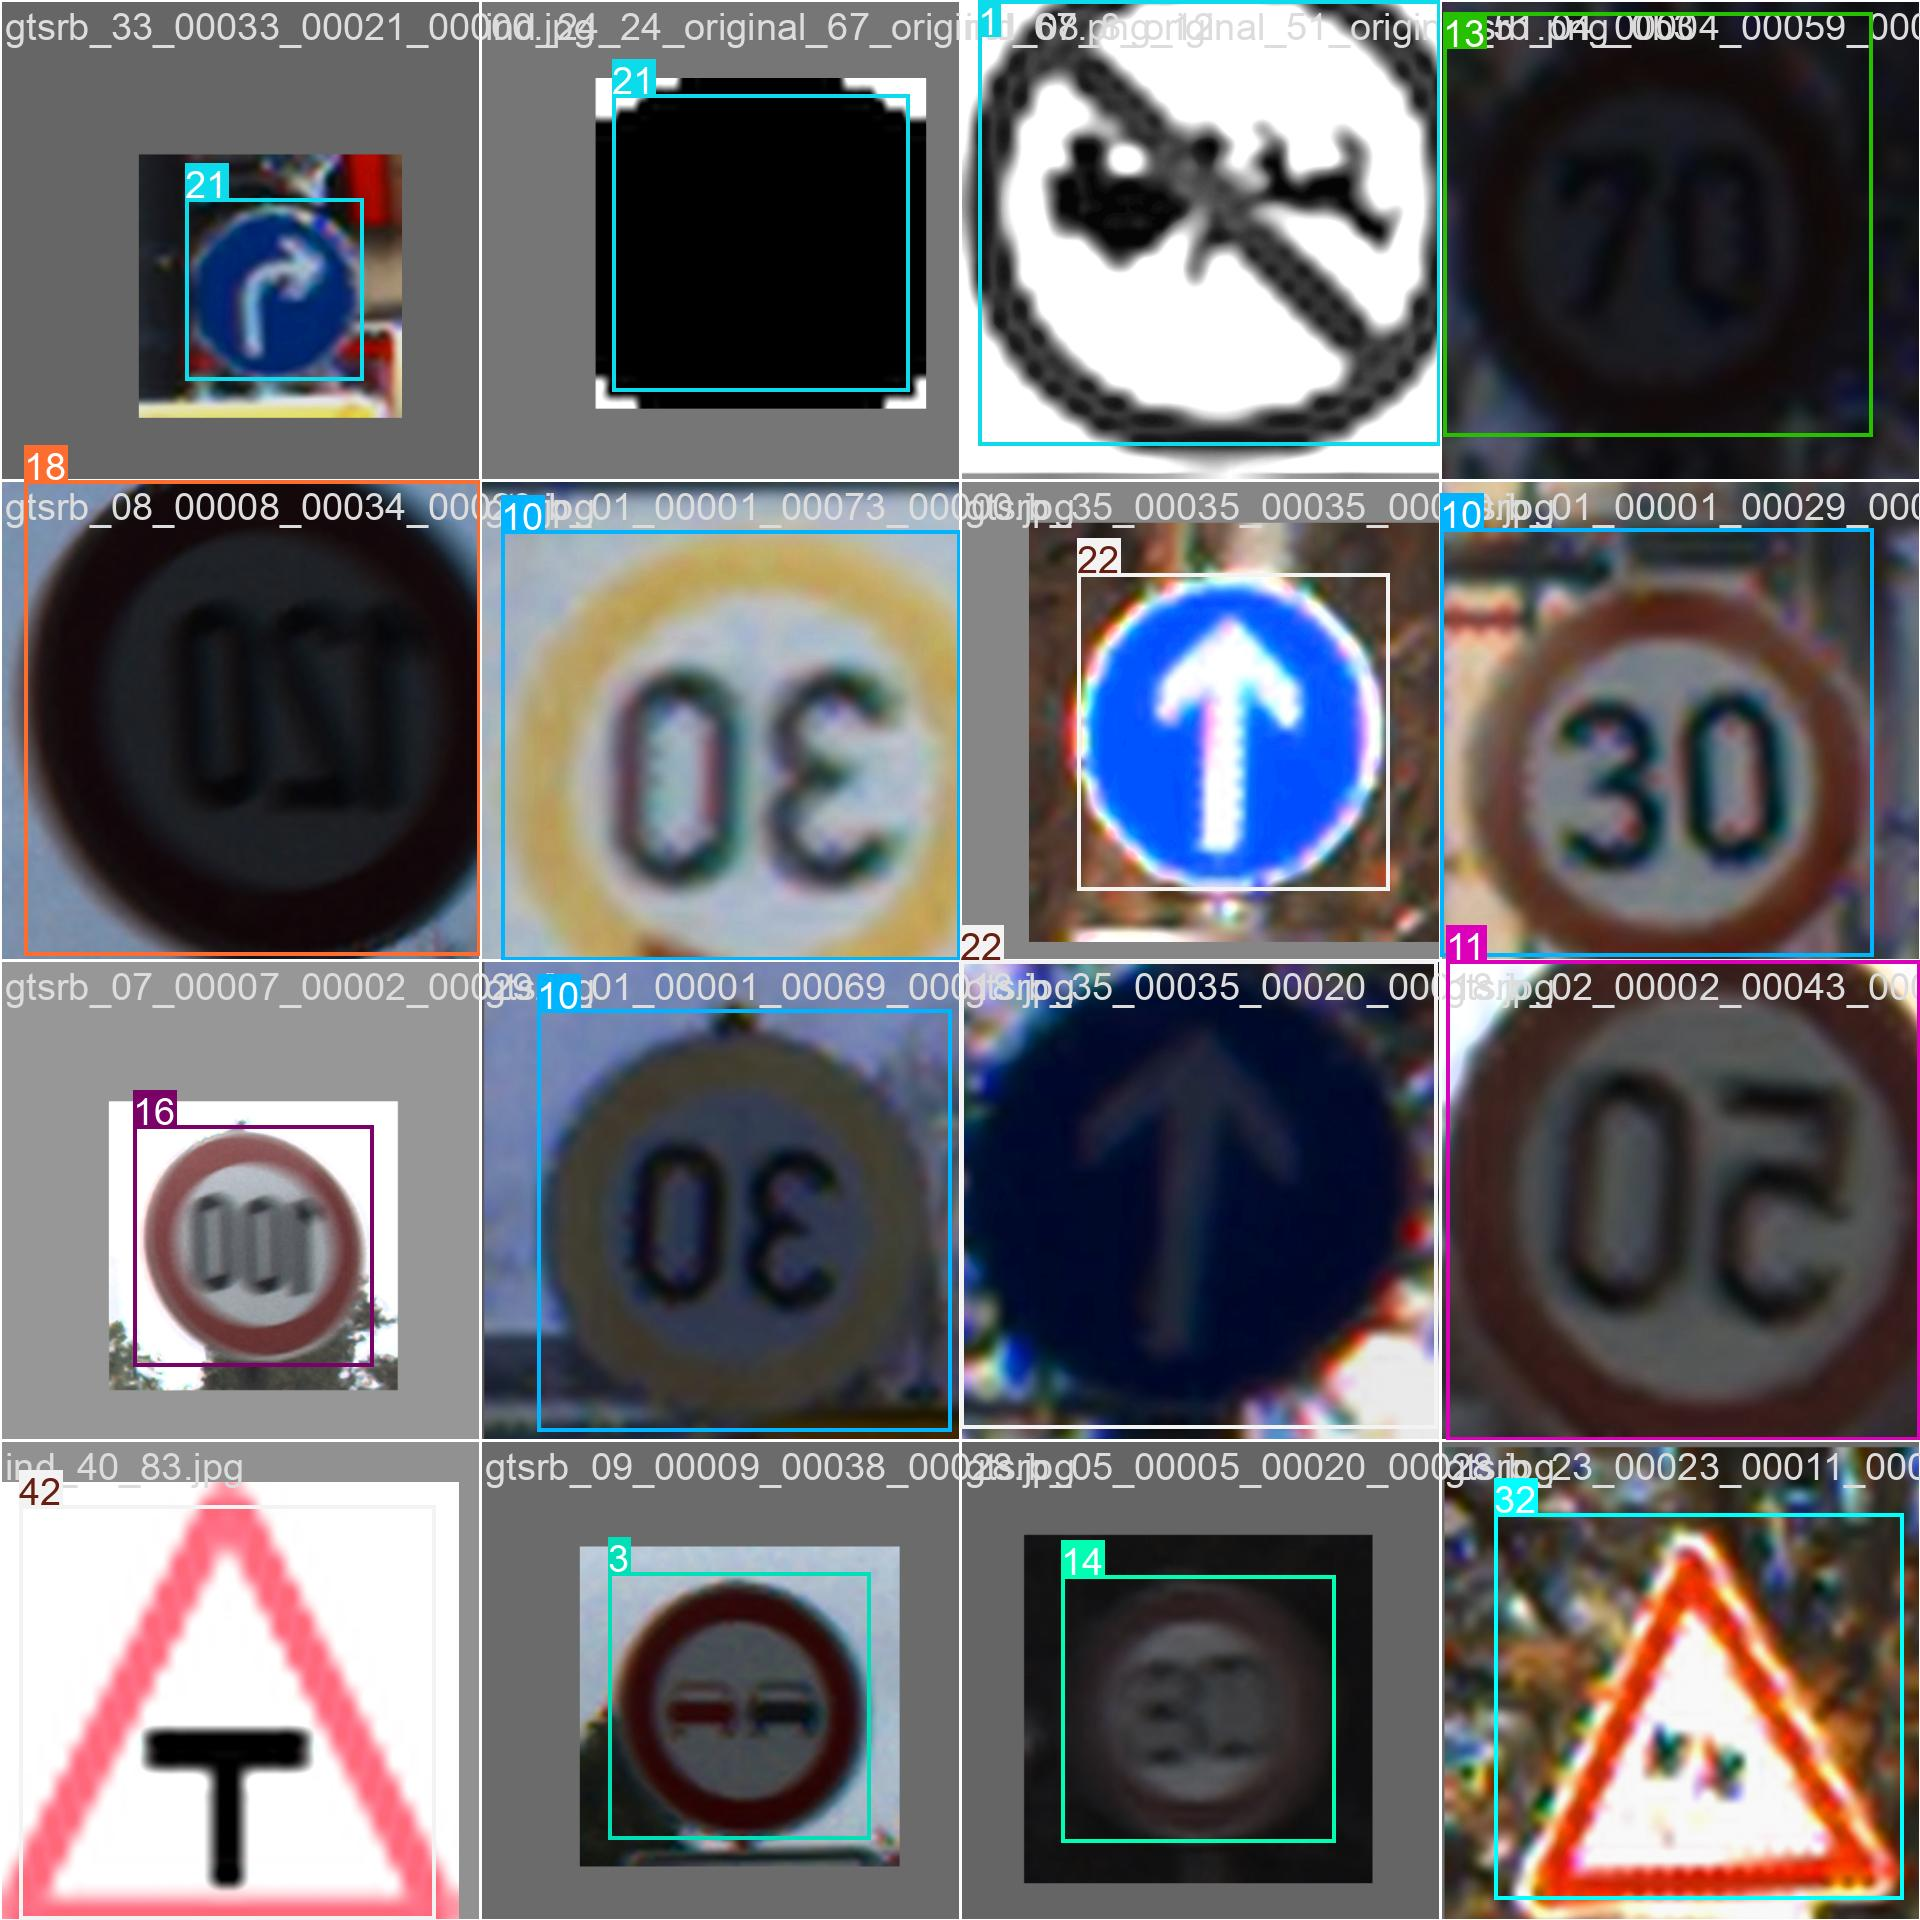

In [5]:
from IPython.display import Image, display
from pathlib import Path


train_batches = [
    "train_batch0.jpg",
    "train_batch1.jpg",
    "train_batch2.jpg",
    "train_batch92970.jpg",
    "train_batch92971.jpg",
    "train_batch92972.jpg",
]

print("TRAINING BATCH SAMPLES\n")
for filename in train_batches:
    path = run_dir / filename
    if path.exists():
        print(f"\n>>> {filename}")
        display(Image(filename=str(path), width=900))
    else:
        print(f"[NOT FOUND] {filename}")

VALIDATION BATCH: LABELS vs PREDICTIONS


>>> Val Batch 0 — Ground Truth Labels


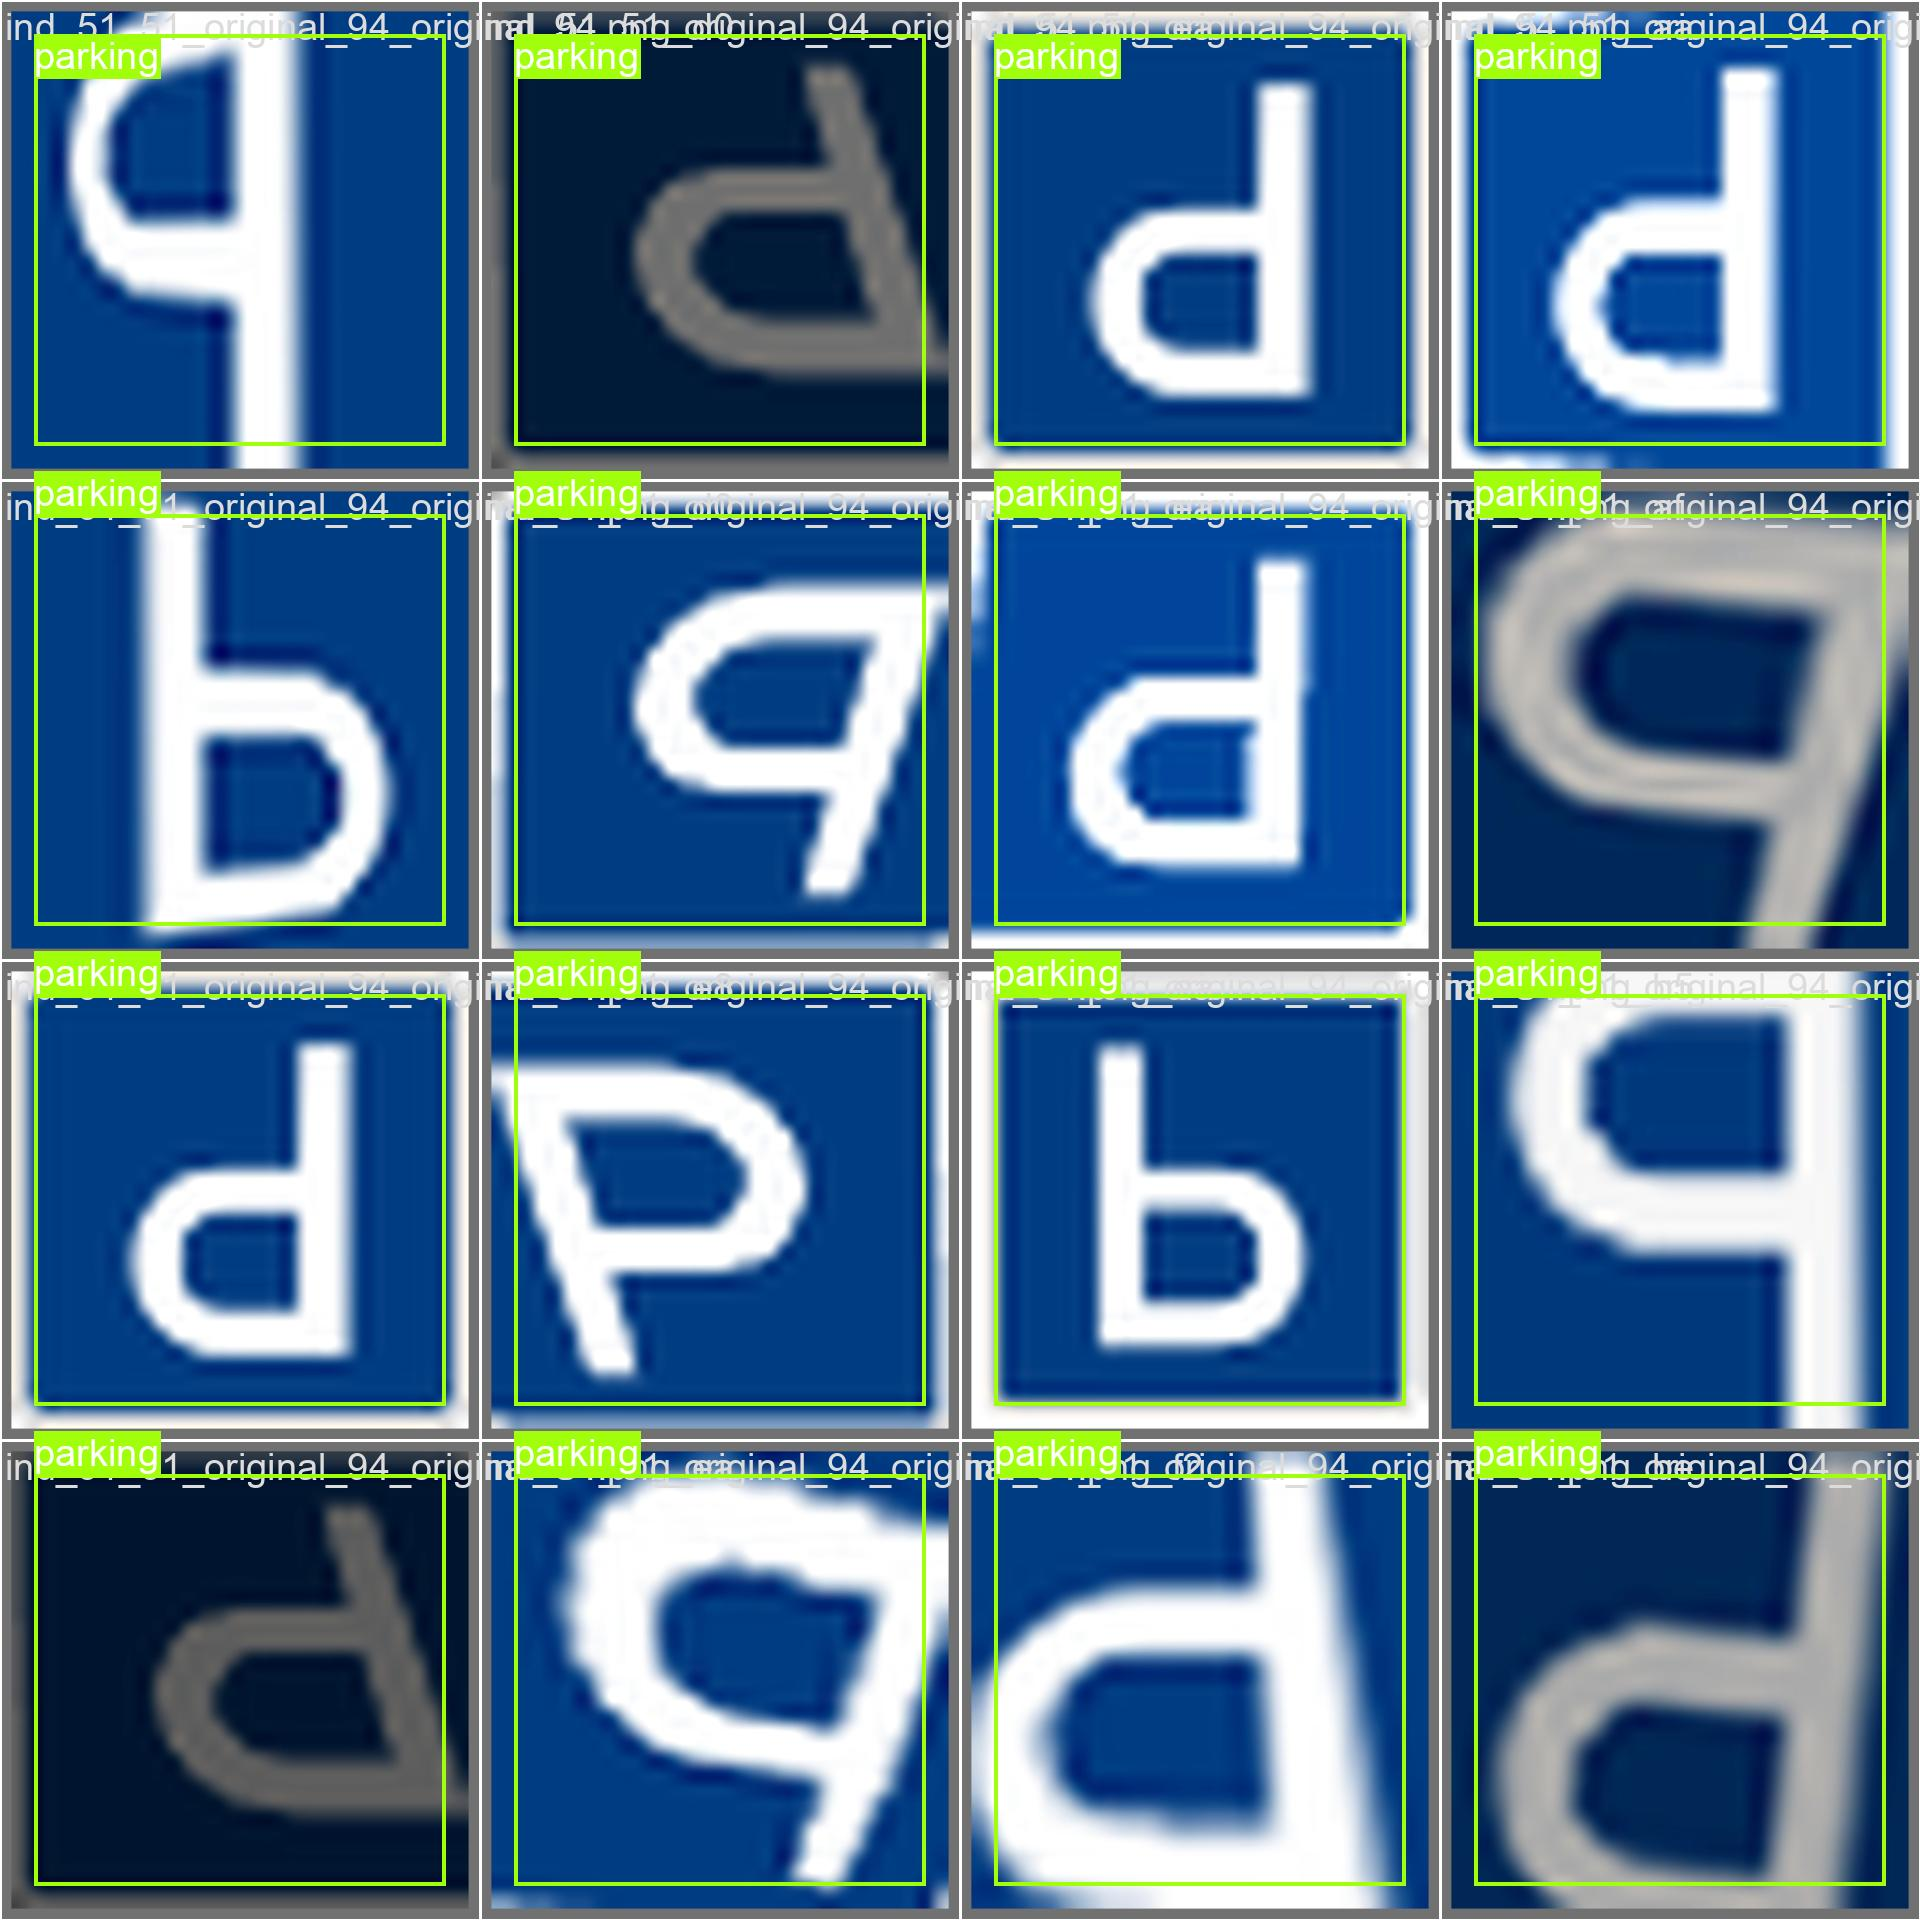


>>> Val Batch 0 — Model Predictions


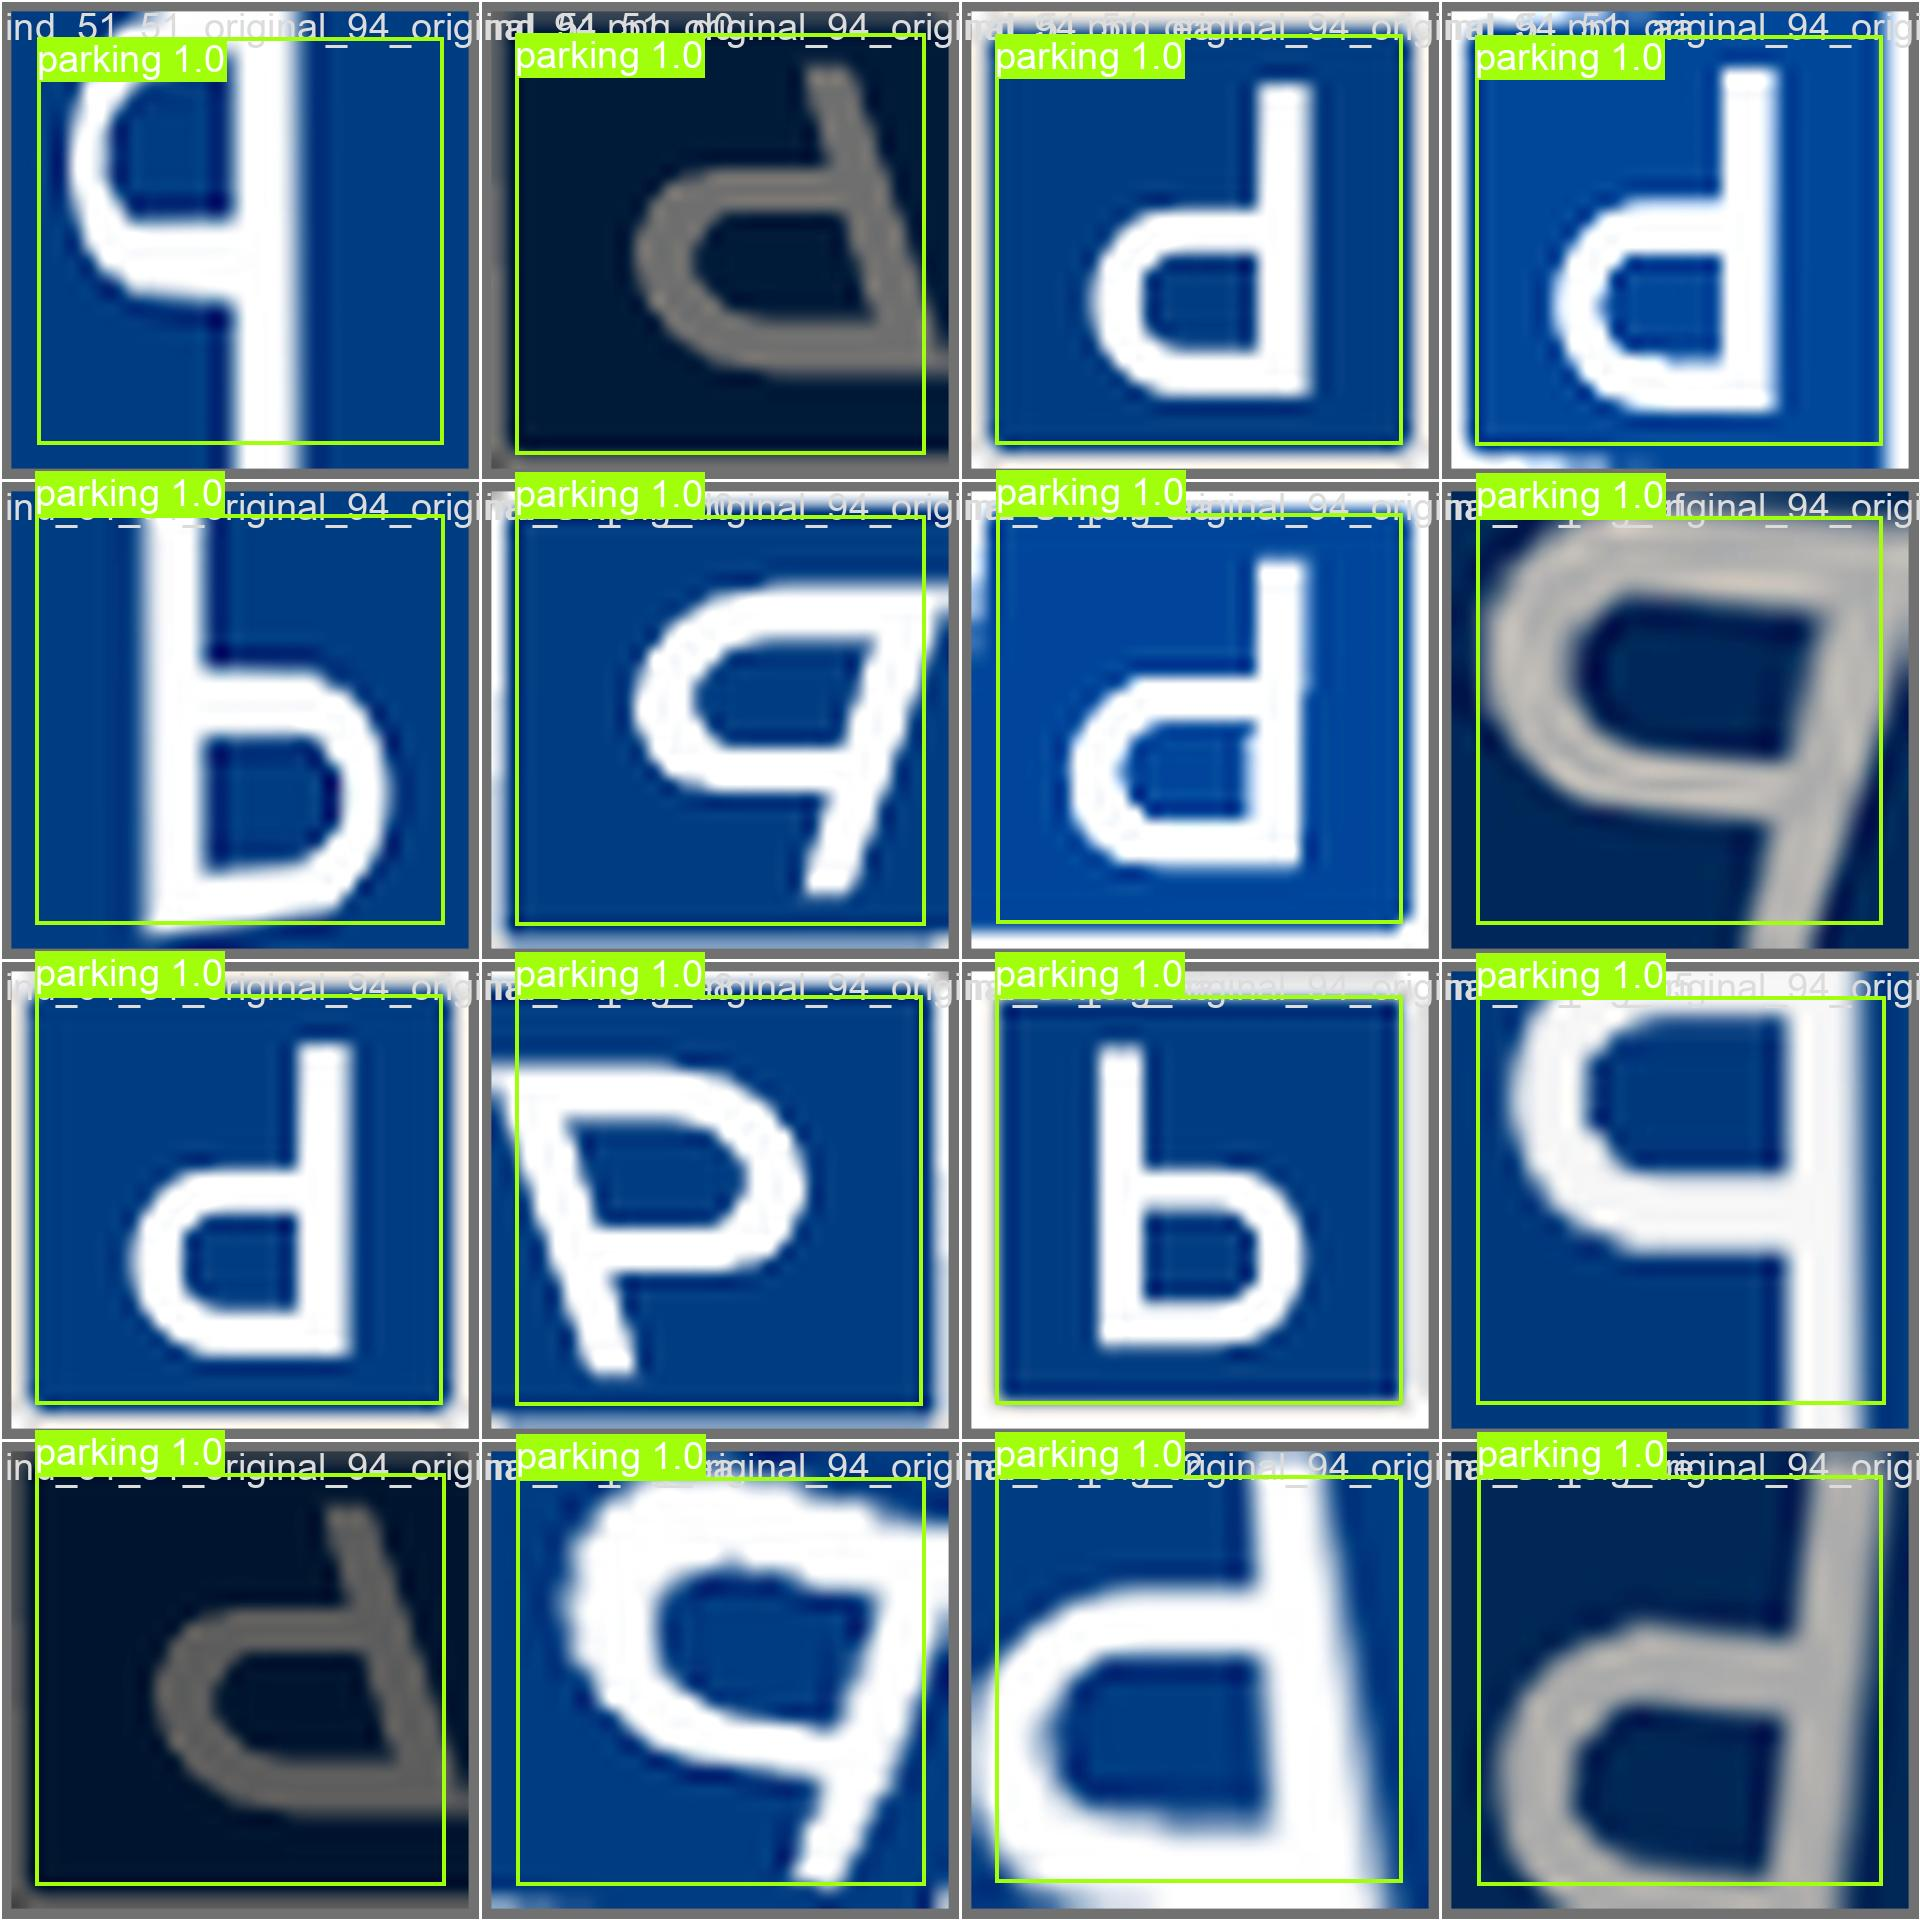


>>> Val Batch 1 — Ground Truth Labels


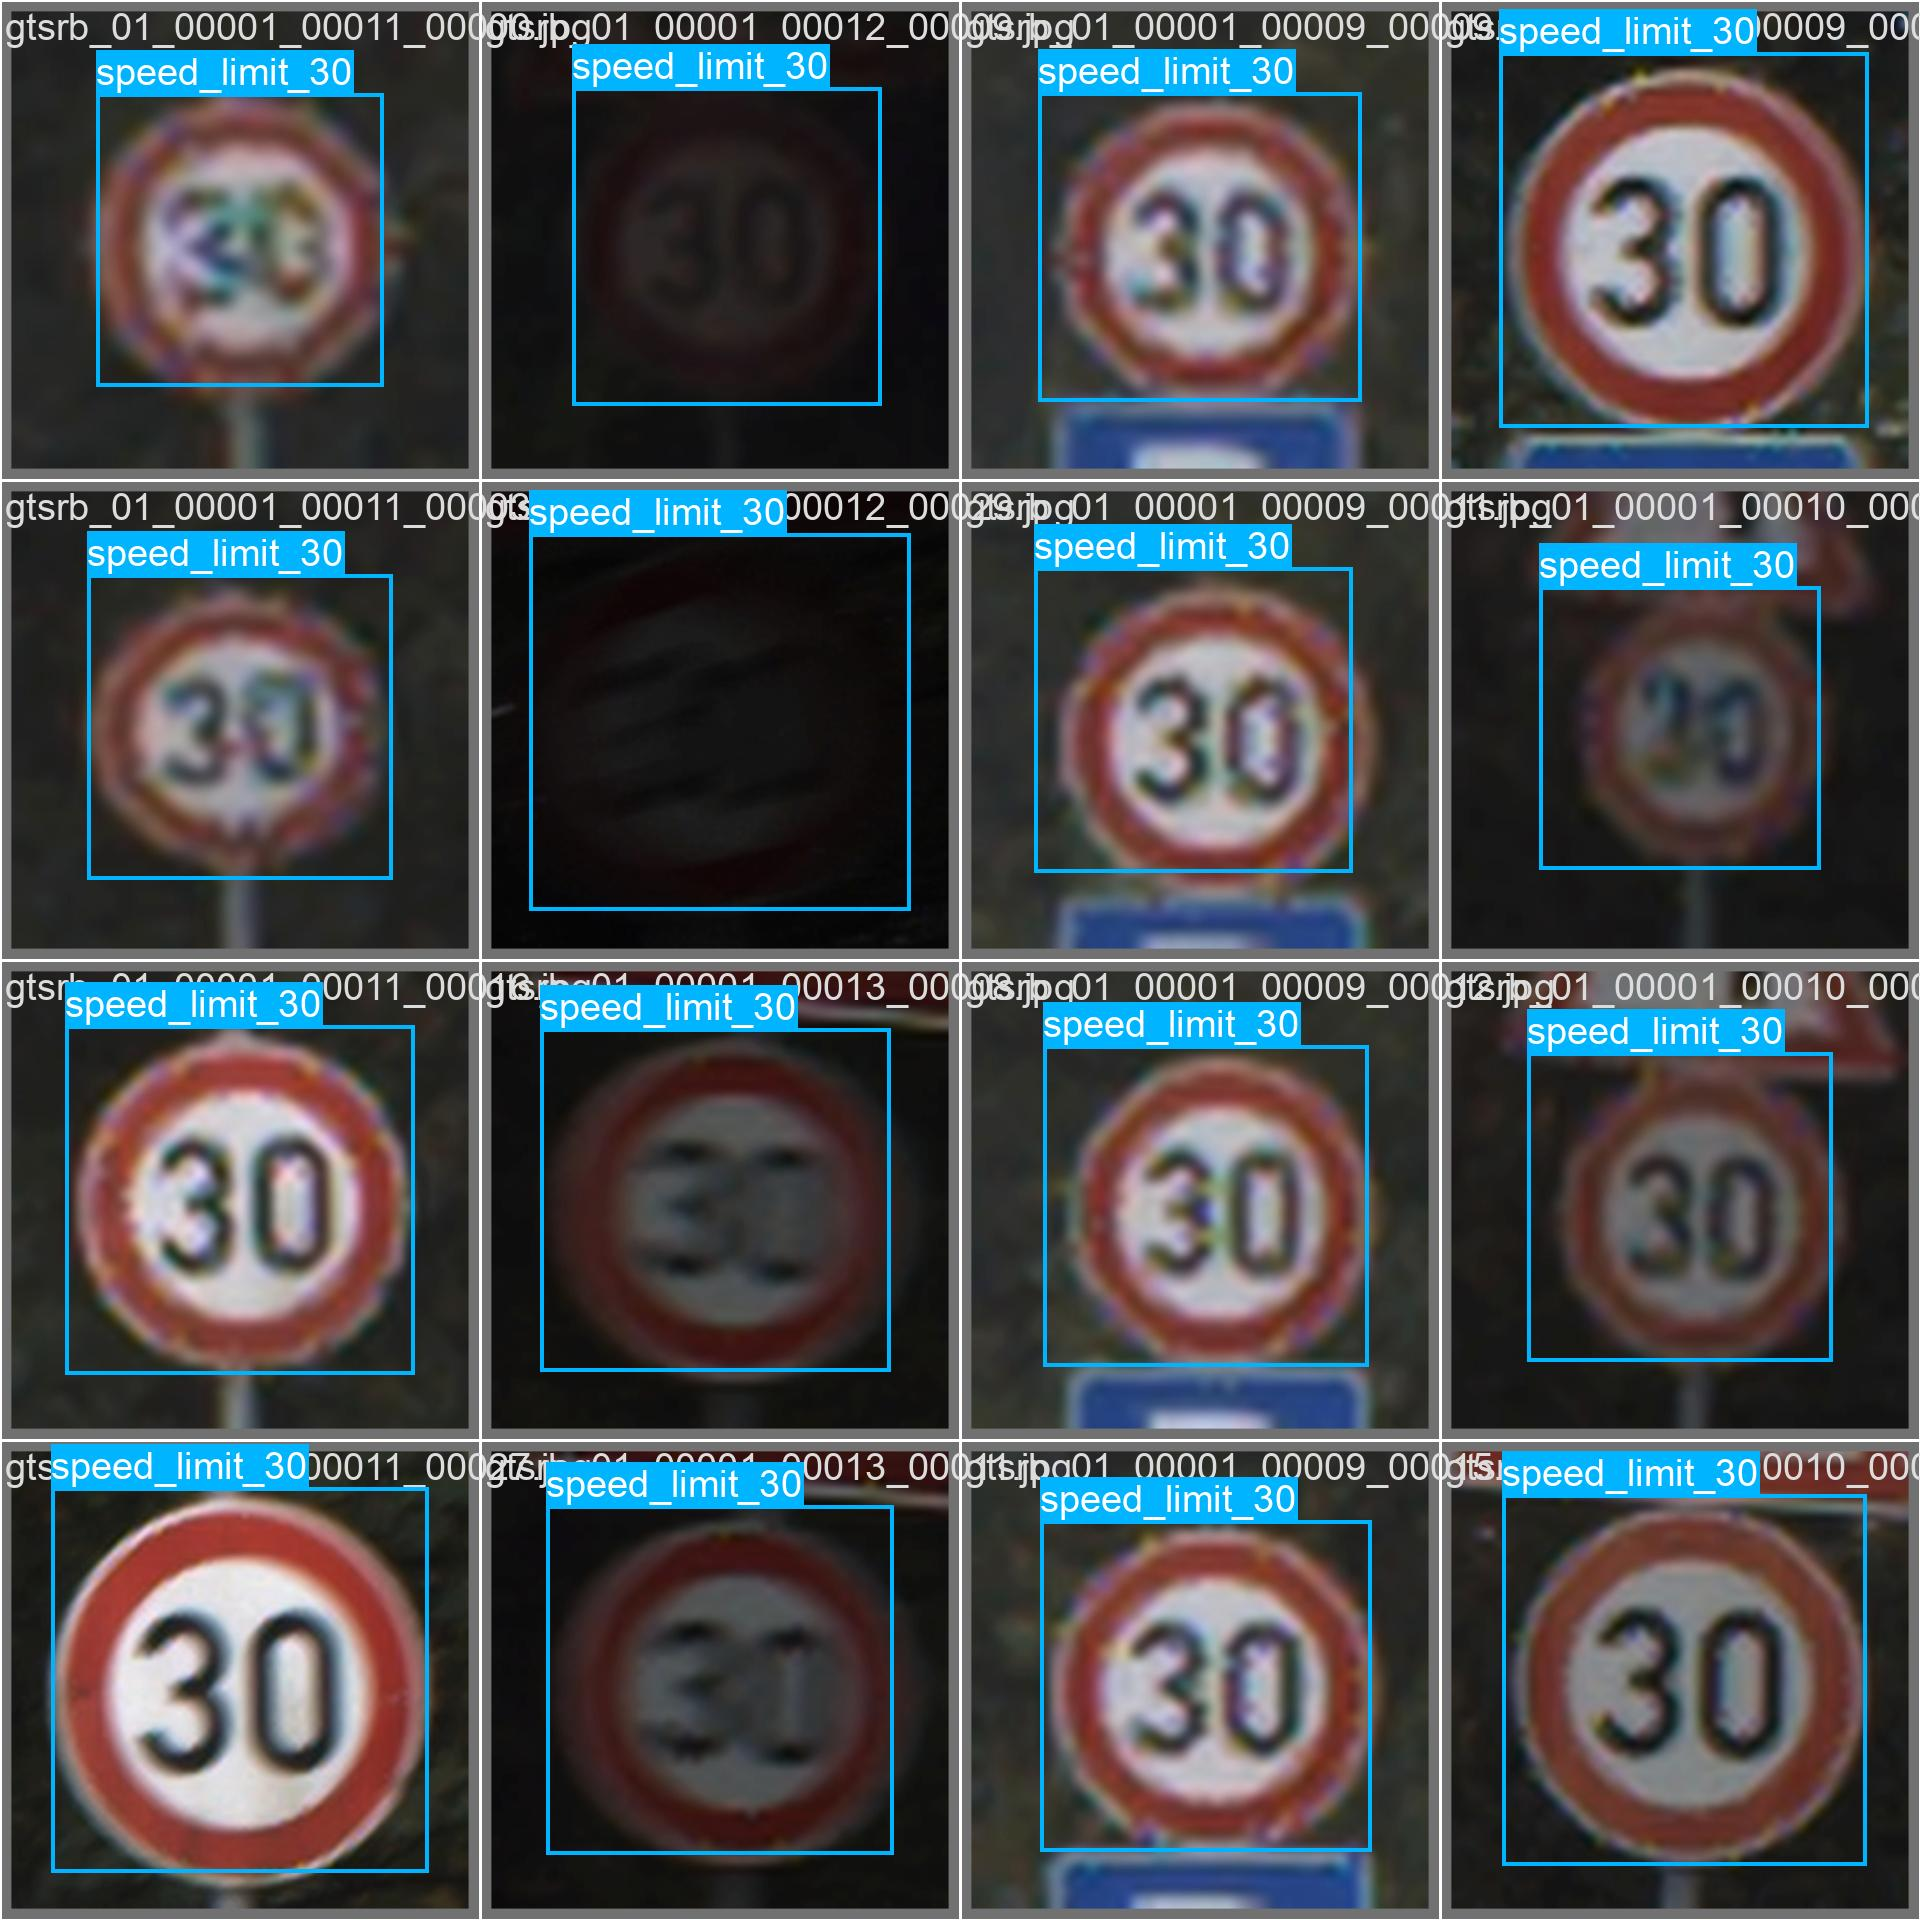


>>> Val Batch 1 — Model Predictions


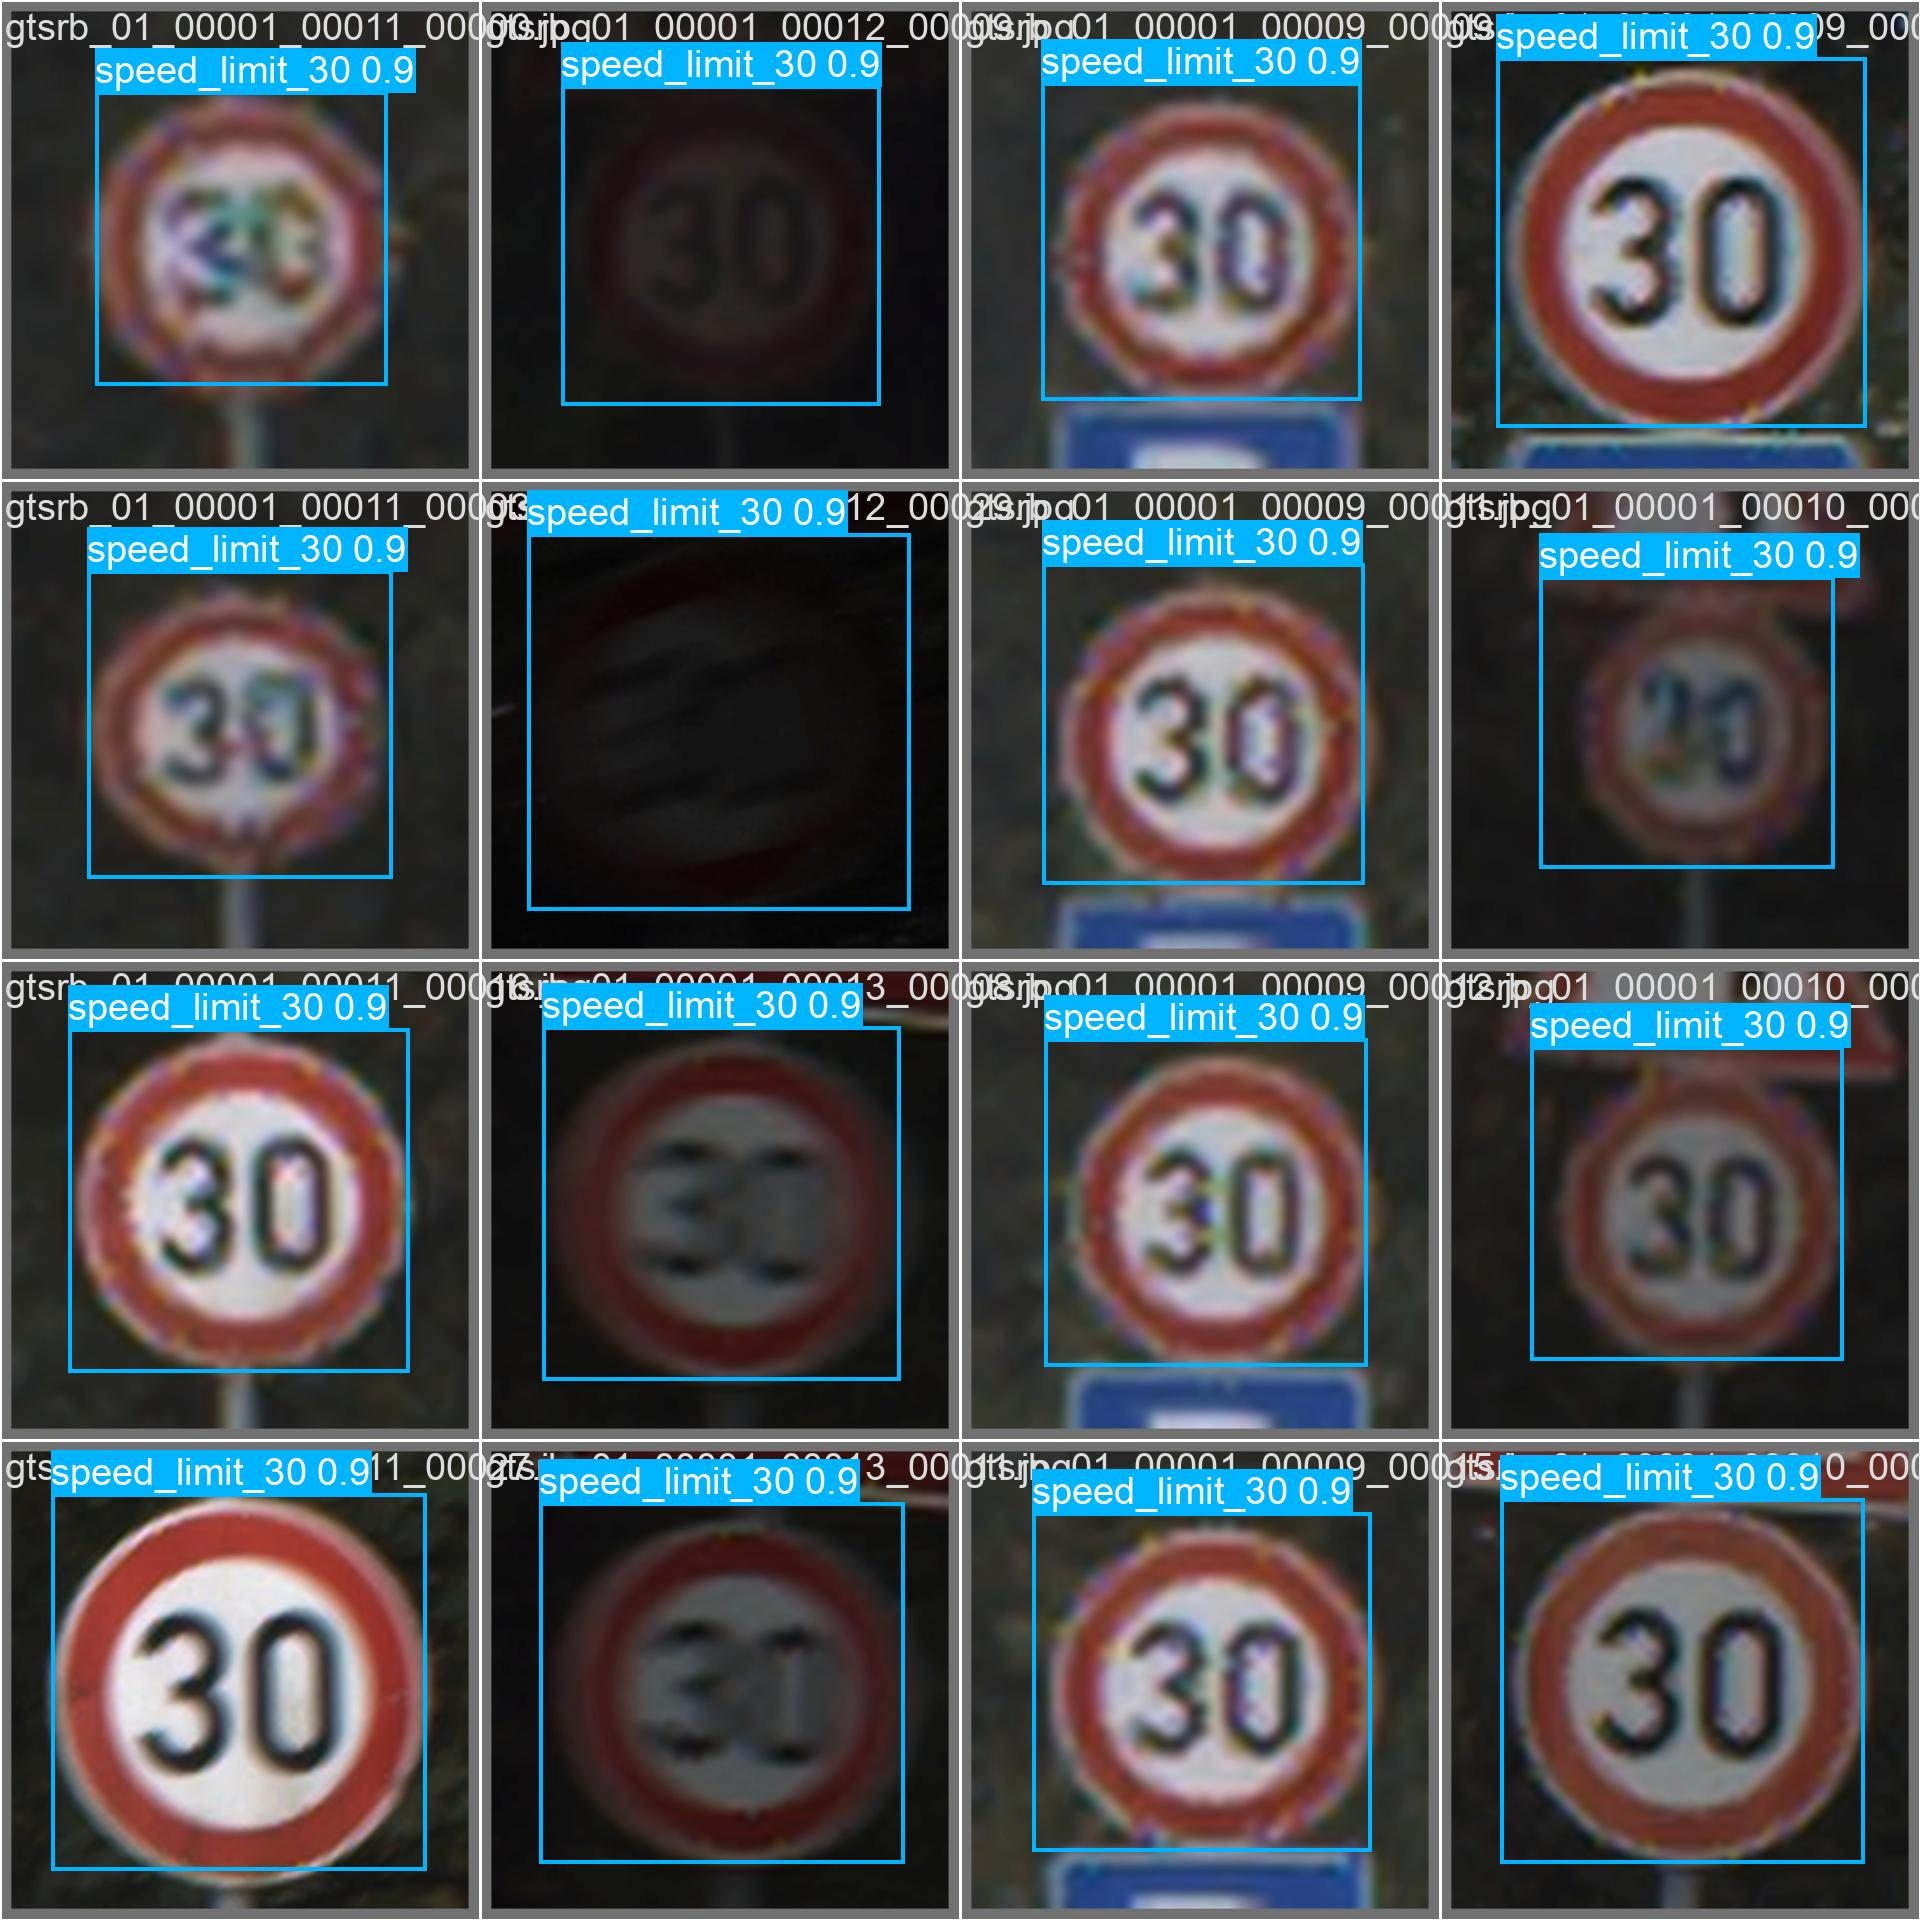


>>> Val Batch 2 — Ground Truth Labels


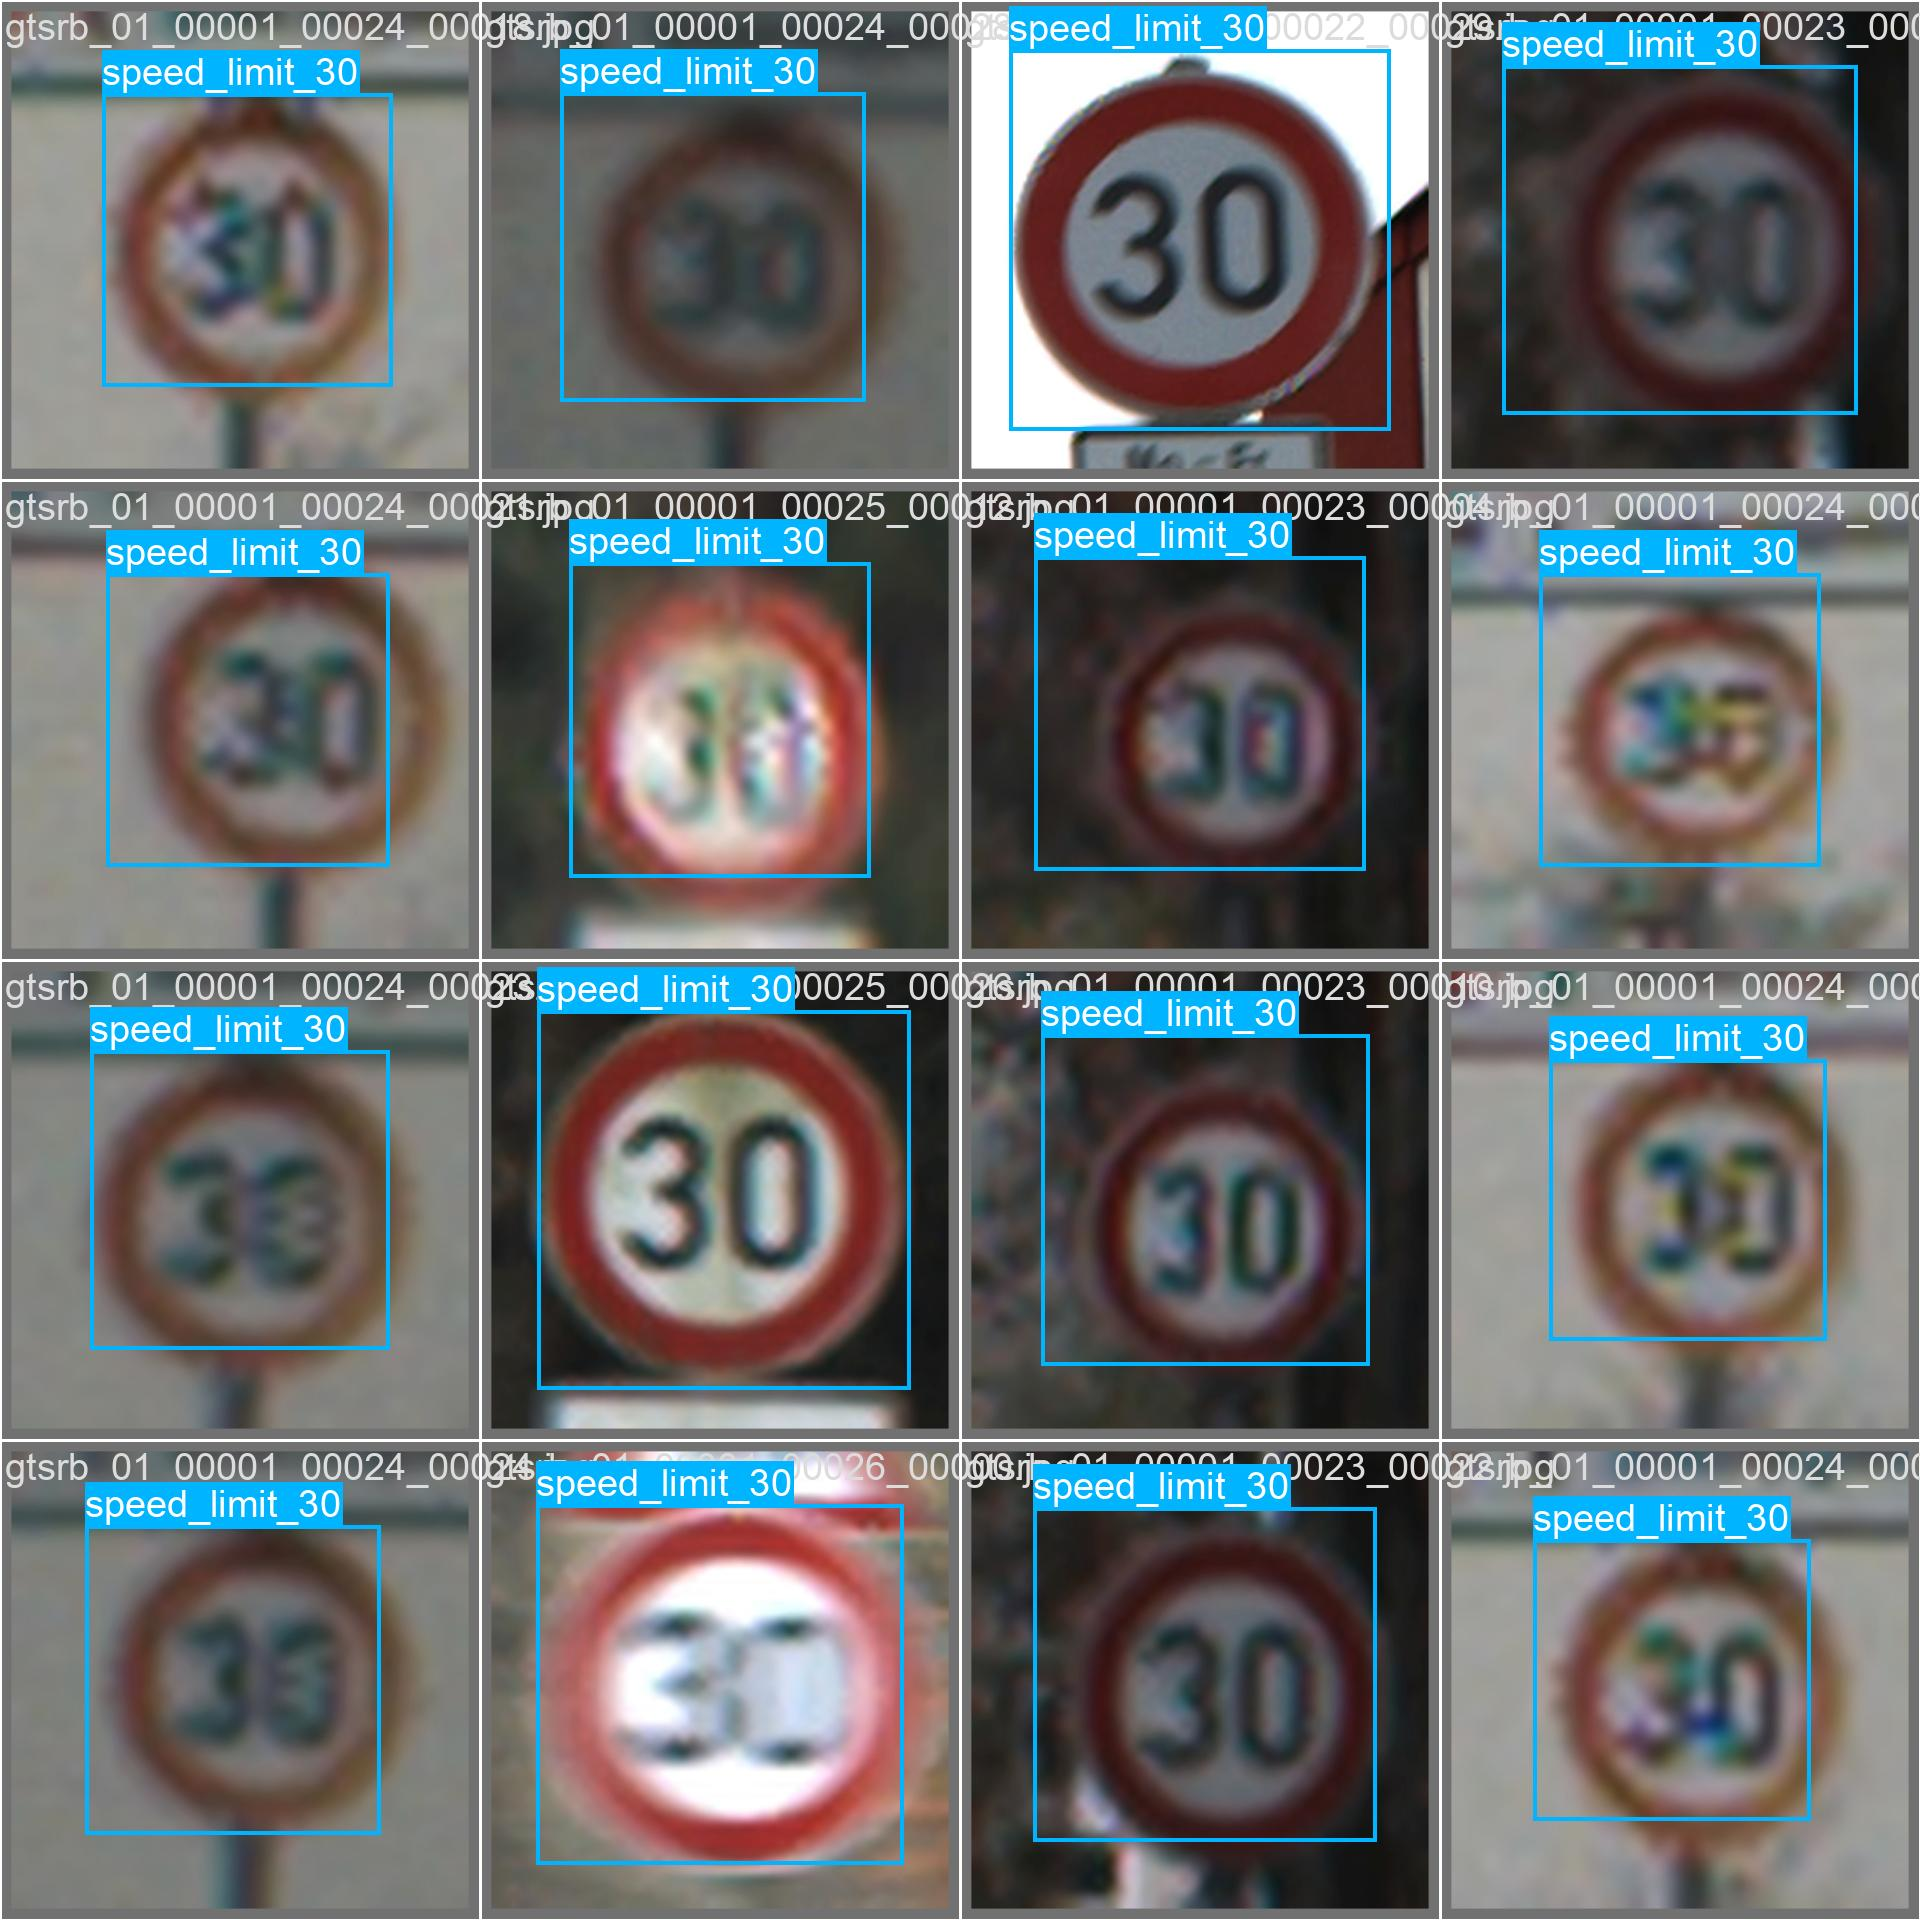


>>> Val Batch 2 — Model Predictions


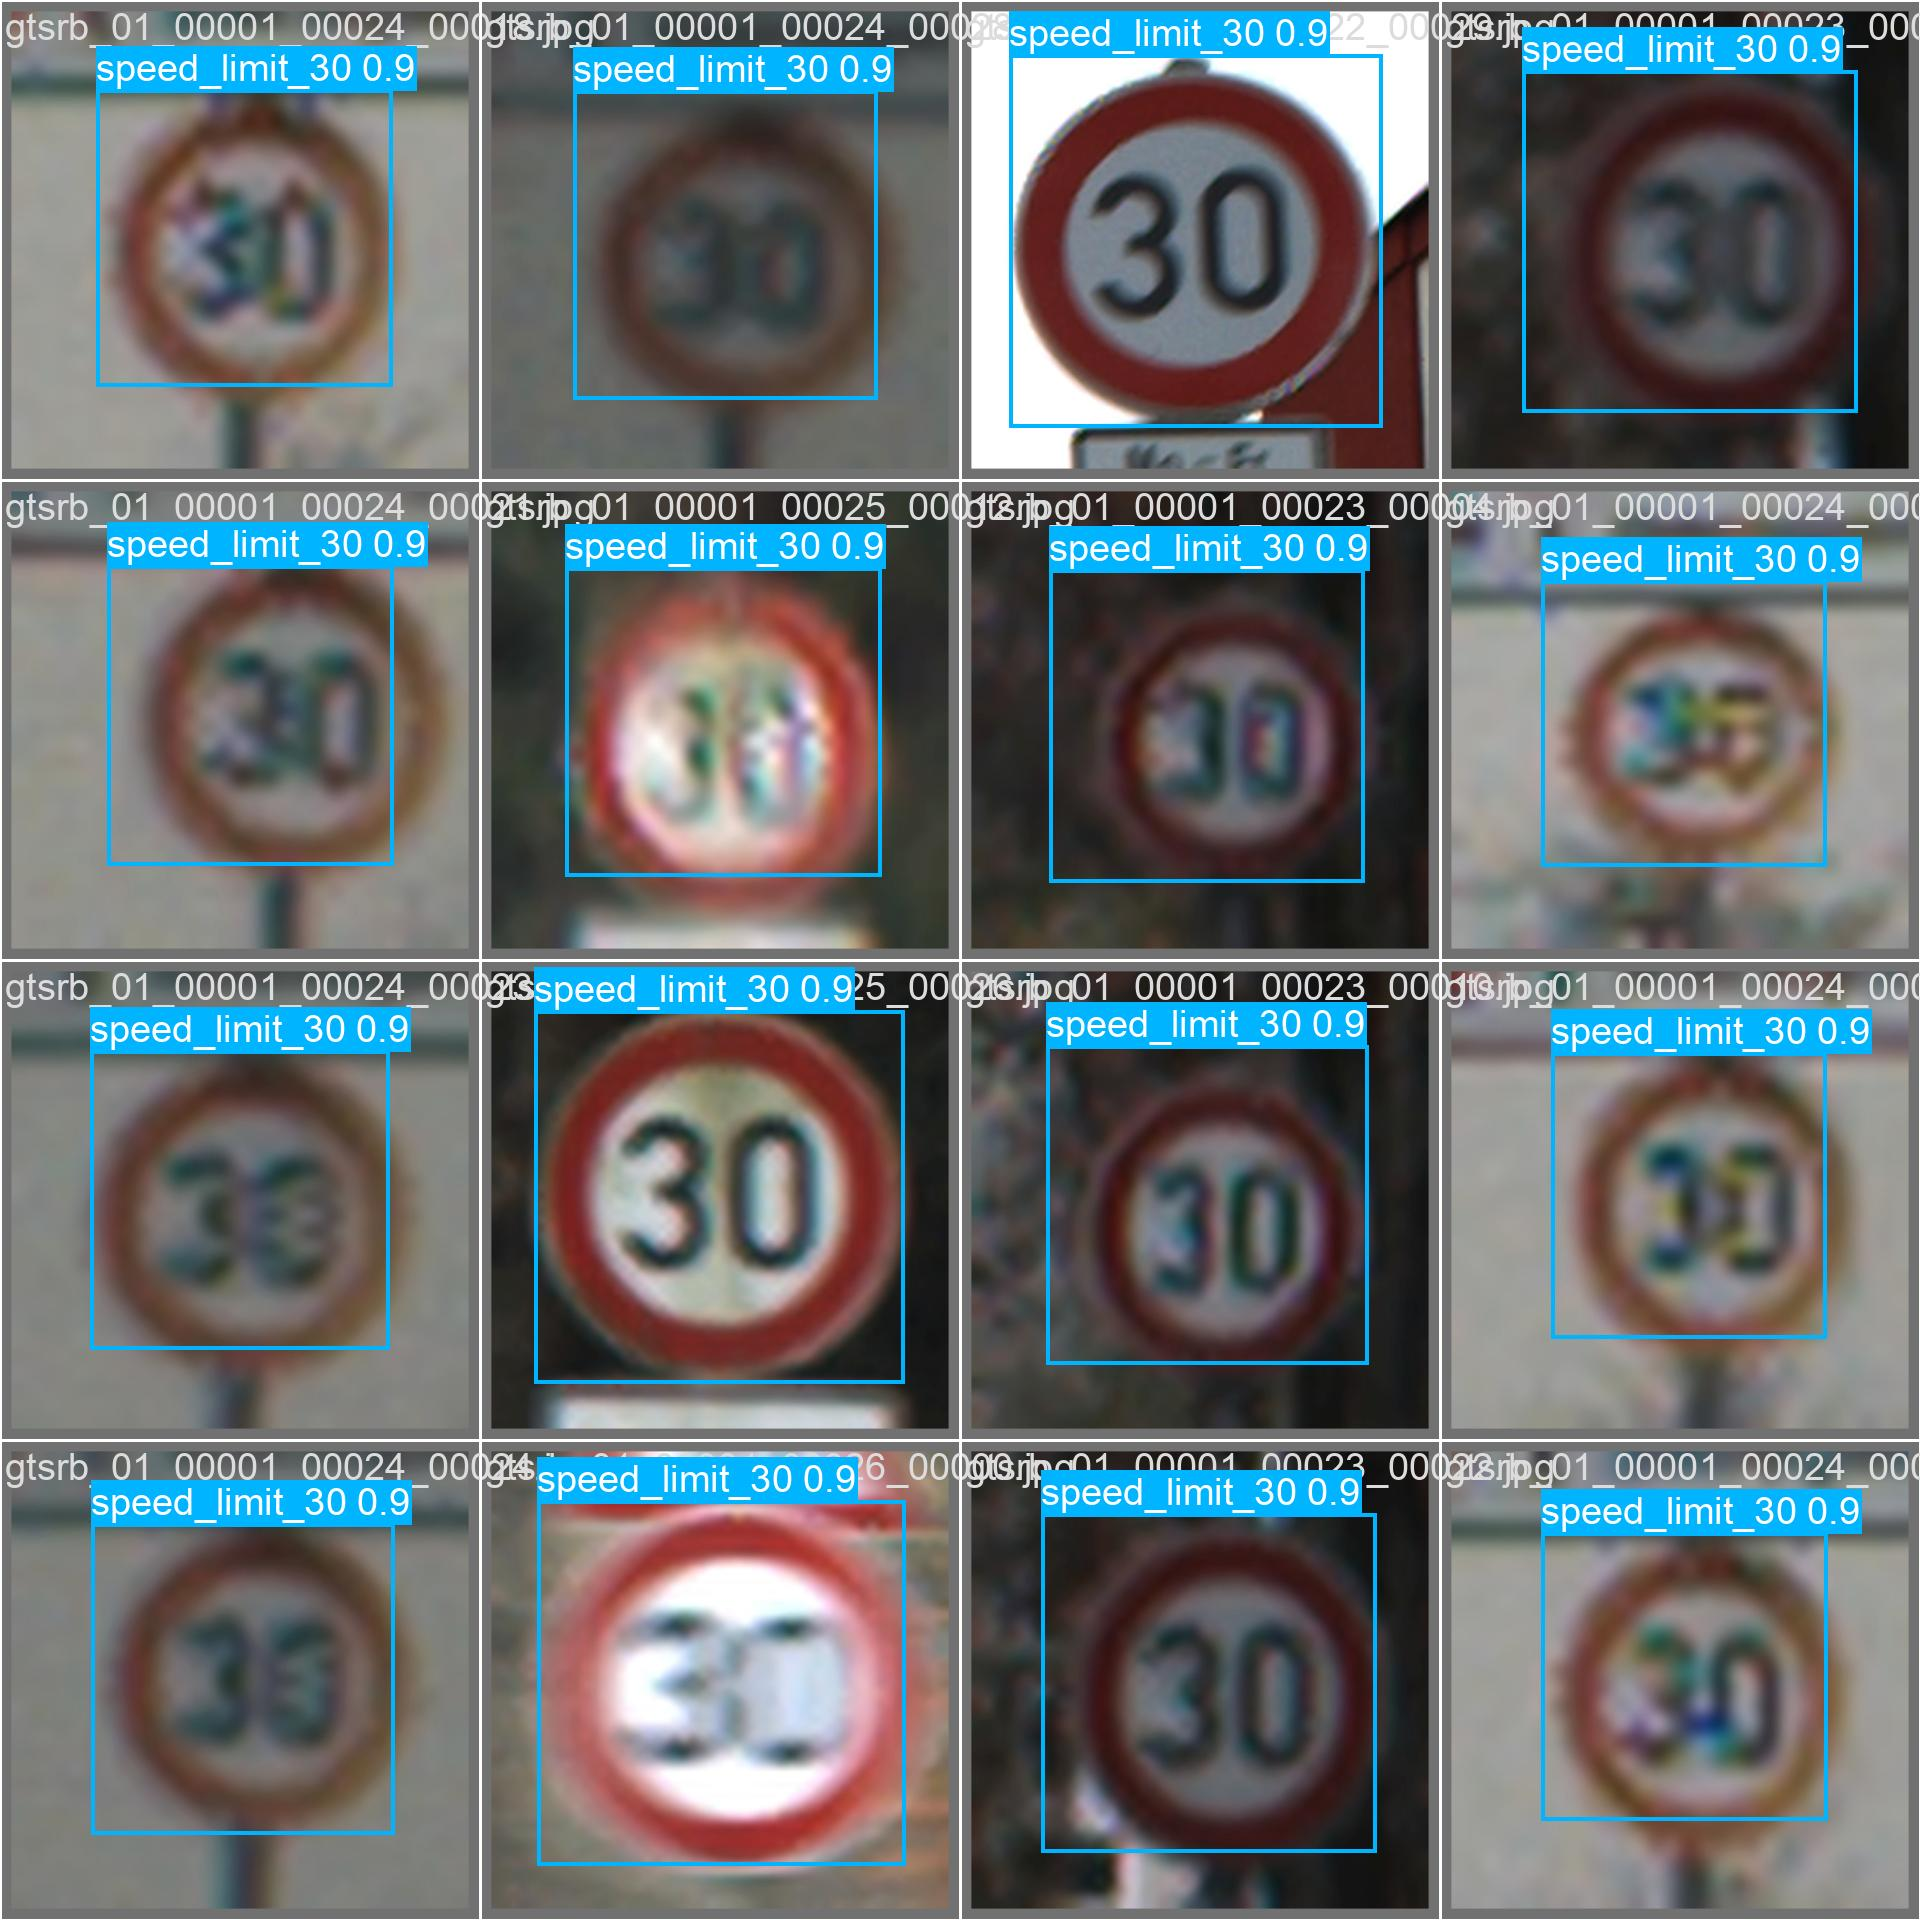

In [6]:
from IPython.display import Image, display
from pathlib import Path


val_batches = [
    ("Val Batch 0 — Ground Truth Labels", "val_batch0_labels.jpg"),
    ("Val Batch 0 — Model Predictions",   "val_batch0_pred.jpg"),
    ("Val Batch 1 — Ground Truth Labels", "val_batch1_labels.jpg"),
    ("Val Batch 1 — Model Predictions",   "val_batch1_pred.jpg"),
    ("Val Batch 2 — Ground Truth Labels", "val_batch2_labels.jpg"),
    ("Val Batch 2 — Model Predictions",   "val_batch2_pred.jpg"),
]

print("VALIDATION BATCH: LABELS vs PREDICTIONS\n")
for title, filename in val_batches:
    path = run_dir / filename
    if path.exists():
        print(f"\n>>> {title}")
        display(Image(filename=str(path), width=900))
    else:
        print(f"[NOT FOUND] {filename}")

Columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
   epoch      time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1   396.871         0.67213         2.80835         1.25407   
1      2   774.809         0.53389         1.32863         1.10740   
2      3  1156.370         0.53291         1.14177         1.09965   
3      4  1531.820         0.50732         1.04320         1.08311   
4      5  1914.780         0.46335         0.89835         1.05941   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.54841            0.42472           0.43757   
1               0.76614            0.79283           0.83331   
2               0.62669            0.74855           0.73928   
3               0.79999            0.83853           0.86869   
4           

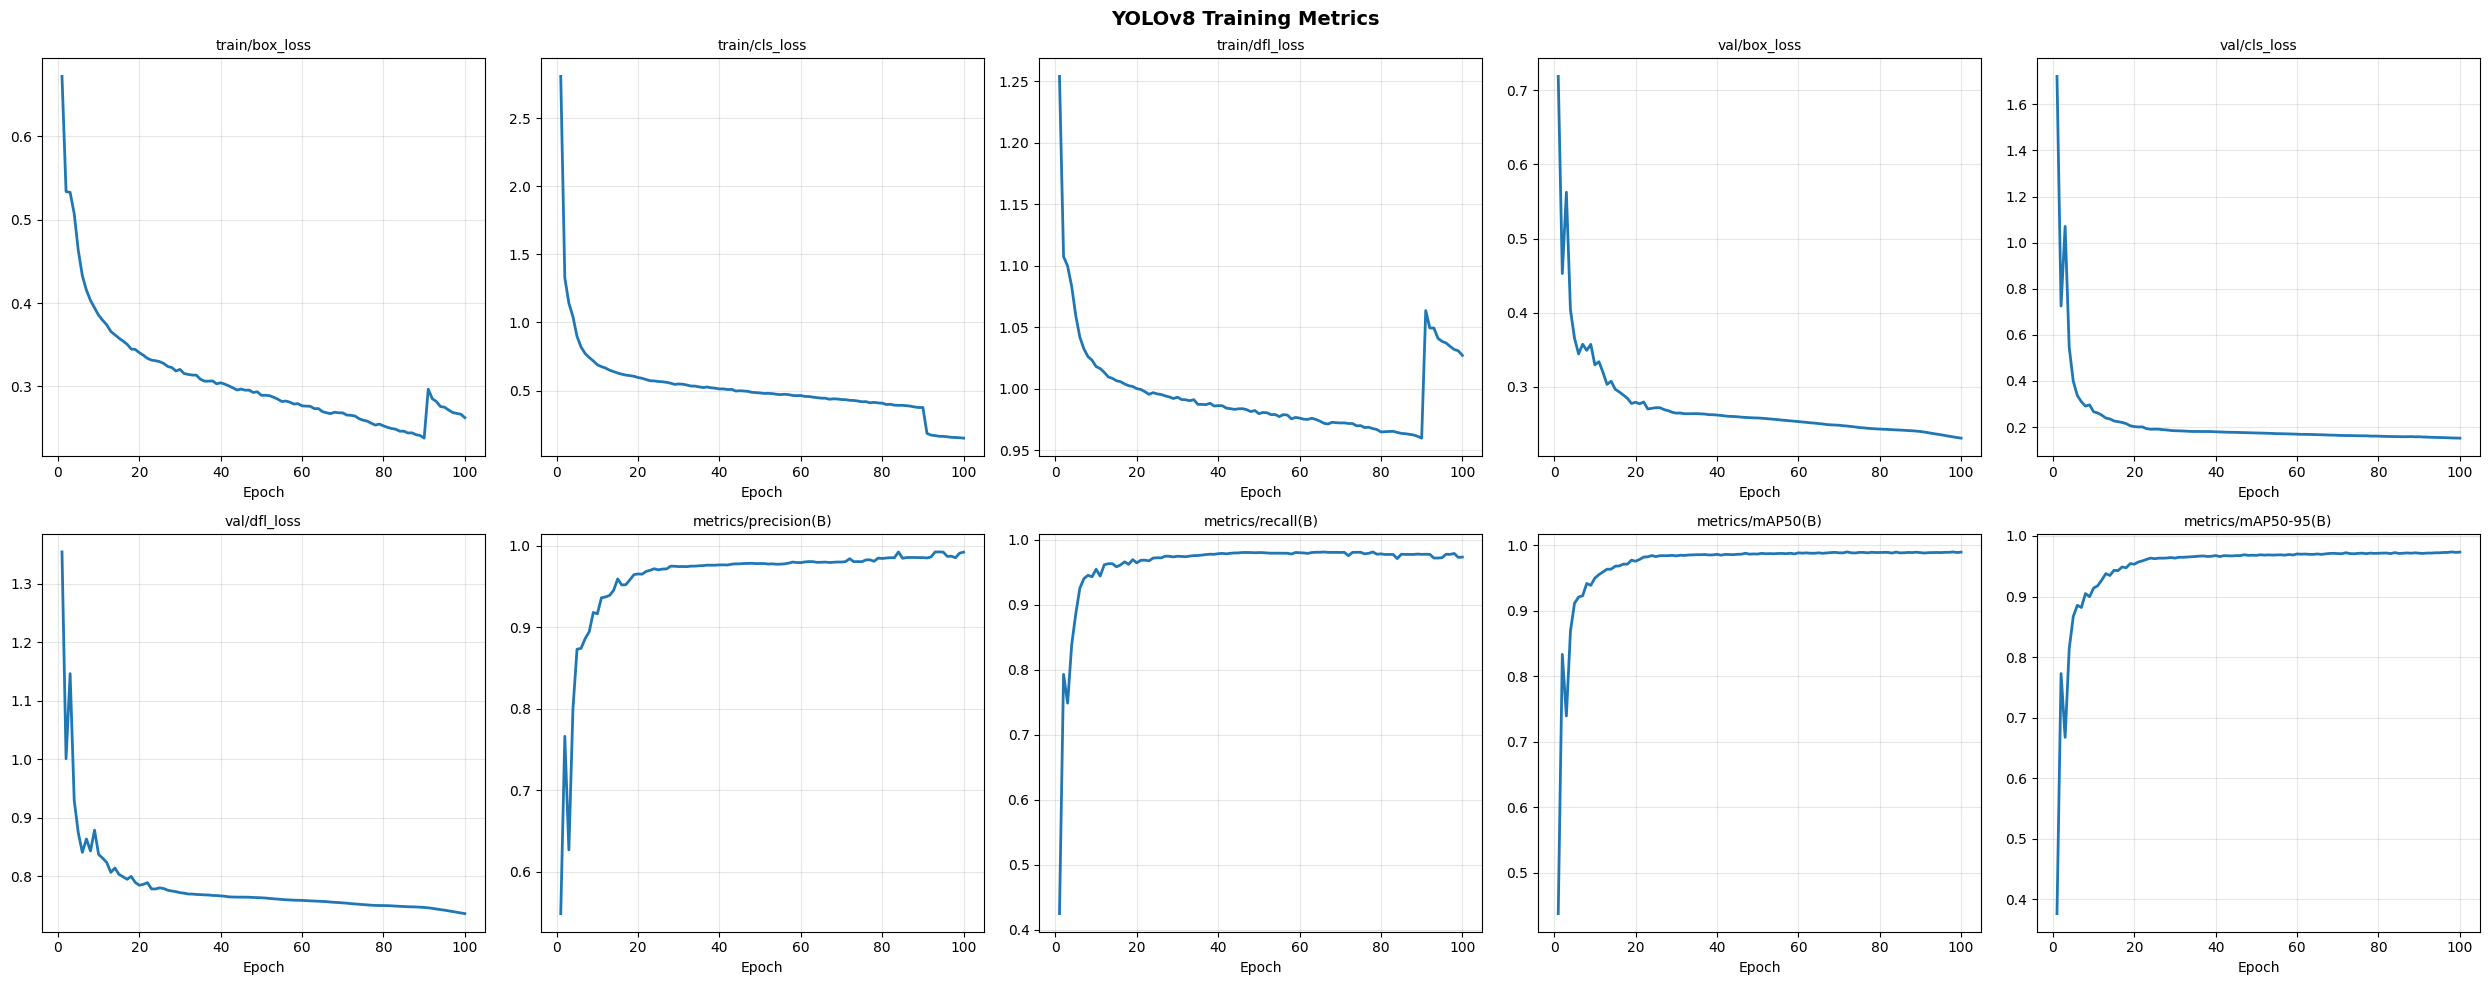

Saved to /kaggle/working/results_custom.png


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

run_dir  = Path("/kaggle/input/datasets/paras2829/note-data/runs/detect/traffic_sign_v1")
save_dir = Path("/kaggle/working")  # writable location

df = pd.read_csv(run_dir / "results.csv")
df.columns = df.columns.str.strip()

print("Columns:", df.columns.tolist())
print(df.head())

metrics = [
    "train/box_loss", "train/cls_loss", "train/dfl_loss",
    "val/box_loss",   "val/cls_loss",   "val/dfl_loss",
    "metrics/precision(B)", "metrics/recall(B)",
    "metrics/mAP50(B)",     "metrics/mAP50-95(B)",
]

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for i, col in enumerate(metrics):
    if col in df.columns:
        axes[i].plot(df["epoch"], df[col], linewidth=2)
        axes[i].set_title(col, fontsize=10)
        axes[i].set_xlabel("Epoch")
        axes[i].grid(True, alpha=0.3)
    else:
        axes[i].set_visible(False)

plt.suptitle("YOLOv8 Training Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(str(save_dir / "results_custom.png"), dpi=150, bbox_inches="tight")  # ← save_dir not run_dir
plt.show()
print("Saved to /kaggle/working/results_custom.png")